In [2]:
# Cell 1: Imports & basic config

import os
import numpy as np
import pandas as pd
import glob

from numpy.linalg import norm

from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, StratifiedKFold, GroupKFold, permutation_test_score, LeaveOneGroupOut, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.covariance import LedoitWolf
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_selection import RFE
from sklearn.utils import resample, shuffle, resample
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.inspection import permutation_importance



import nibabel as nib


from joblib import Parallel, delayed, dump, load



import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests


import itertools
from itertools import combinations

from nilearn import plotting, image, masking
from nilearn.maskers import NiftiLabelsMasker


from scipy import stats
from scipy.stats import pearsonr, ttest_1samp, ttest_ind, entropy, kurtosis
from scipy.spatial.distance import pdist, squareform, cdist

from itertools import combinations
from joblib import Parallel, delayed
import time
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
import seaborn as sns

from typing import List, Sequence, Union
import plotly.graph_objects as go
# Nice plotting defaults
sns.set_context("poster")

RANDOM_STATE = 42
N_SPLITS = 5   # GroupKFold folds
INNER_CV_SPLITS = 5     
CS_LABELS = ["CS-", "CSS", "CSR"]  # the three CS types of interest
MAX_ITER = 5000
thresh_hold_p = 1 - 0.05
N_PERMUTATION = 5000
#N_PERMUTATION = 1
#N_REPEATS = 10
N_REPEATS = 10
N_JOBS = 1
N_BOOT = 50
CROSSNOBIS_REPEATS = 50
SUBJECT_CV_SPLITS = 5
SUBJECT_INNER_SPLITS = 3
CALIB_BINS = 5
TOP_PCT = 95
LOW_PCT = 5
TWO_TAIL_LOW = 2.5
TWO_TAIL_HIGH = 97.5
MIN_TRIALS_PER_SUBJECT = 10
C_MIN_EXP = -2
C_MAX_EXP = 2
C_POINTS = 20

In [3]:
# cell 2 helper functions
# =============================================================================
# 1. Pipeline & Preprocessing
# =============================================================================
param_grid = {
    'classification__C': np.logspace(C_MIN_EXP, C_MAX_EXP, C_POINTS)
}

def build_binary_pipeline():
    return Pipeline([
        ("scaler", StandardScaler()),
        ('classification', LogisticRegression(
            penalty='l2', 
            solver='lbfgs', 
            class_weight='balanced', 
            max_iter=MAX_ITER, 
            random_state=RANDOM_STATE, 
            n_jobs=N_JOBS
        ))
    ])


def get_cv(y, groups=None, n_splits=SUBJECT_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE):
    """Return StratifiedGroupKFold if multiple groups exist; otherwise StratifiedKFold."""
    if groups is None or len(np.unique(groups)) < 2:
        return StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=(random_state if shuffle else None))
    return StratifiedGroupKFold(n_splits=n_splits, shuffle=shuffle, random_state=(random_state if shuffle else None))


def _force_choice_scores_to_2d(scores: np.ndarray) -> np.ndarray:
    """Ensure decision scores are 2D (n_samples, n_classes)."""
    scores_arr = np.asarray(scores)
    if scores_arr.ndim == 1:
        scores_arr = np.column_stack((-scores_arr, scores_arr))
    return scores_arr


def forced_choice_predict(scores: np.ndarray, classes: Sequence[str]) -> np.ndarray:
    """Predict class labels via forced-choice (argmax of decision scores)."""
    scores_2d = _force_choice_scores_to_2d(scores)
    class_arr = np.asarray(classes)
    if scores_2d.shape[1] != class_arr.shape[0]:
        raise ValueError("Decision scores do not match class labels.")
    return class_arr[np.argmax(scores_2d, axis=1)]


def compute_forced_choice_accuracy(
    y_true: np.ndarray,
    scores: np.ndarray,
    classes: Sequence[str],
) -> float:
    """Compute trial-wise forced-choice accuracy from decision scores."""
    y_pred = forced_choice_predict(scores, classes)
    return float(np.mean(y_true == y_pred))


def compute_subject_forced_choice_accs(
    y_true: np.ndarray,
    scores: np.ndarray,
    subjects: np.ndarray,
    classes: Sequence[str],
) -> np.ndarray:
    """Compute per-subject forced-choice accuracies from decision scores."""
    y_pred = forced_choice_predict(scores, classes)
    accs = []
    for sub in np.unique(subjects):
        mask = subjects == sub
        if np.sum(mask) == 0:
            continue
        accs.append(float(np.mean(y_true[mask] == y_pred[mask])))
    return np.array(accs)


def forced_choice_scorer(estimator, X, y) -> float:
    """Scorer wrapper for GridSearchCV/cross_val_score."""
    scores = estimator.decision_function(X)
    return compute_forced_choice_accuracy(y, scores, estimator.classes_)


def compute_pairwise_forced_choice(y_true, scores, class_labels):
    """Forced-choice accuracy given decision-score columns per class."""
    scores_arr = np.asarray(scores)
    return compute_forced_choice_accuracy(y_true, scores_arr, class_labels)


def run_cross_decoding(model, X, y, groups, classes=None):
    """
    Applies a pre-trained model to a new dataset and computes subject-level
    forced-choice accuracy.
    """
    scores = model.decision_function(X)
    return compute_subject_forced_choice_accs(y, scores, groups, model.classes_)


def run_perm_simple(X, y, groups, n_iters):
    """
    Runs permutation testing iterations for a single job using
    trial-wise forced-choice accuracy.
    """
    scores = []
    y_shuffled = y.copy()

    pipe = build_binary_pipeline()
    cv = get_cv(y, groups, n_splits=N_SPLITS, shuffle=False)

    for _ in range(n_iters):
        np.random.shuffle(y_shuffled)
        cv_scores = cross_val_score(
            pipe,
            X,
            y_shuffled,
            groups=groups,
            cv=cv,
            scoring=forced_choice_scorer,
            n_jobs=N_JOBS
        )
        scores.append(float(np.mean(cv_scores)))

    return scores

    
def run_cross_perm(model, X, y, subs, n_iter):
    """Cross-decoding permutation using trial-wise forced-choice accuracy."""
    null_scores = []
    mask_c = np.isin(y, model.classes_)
    X_f = X[mask_c]
    y_f = y[mask_c]

    scores = model.decision_function(X_f)

    for _ in range(n_iter):
        y_shuff = np.random.permutation(y_f)
        null_scores.append(compute_forced_choice_accuracy(y_shuff, scores, model.classes_))
    return np.array(null_scores)

    
def run_spatial_perm(seed, maps, groups):
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(groups)
    w_sad_p = np.mean(maps[shuffled == "SAD"], axis=0)
    w_hc_p = np.mean(maps[shuffled == "HC"], axis=0)
    return cosine_similarity(w_sad_p.reshape(1, -1), w_hc_p.reshape(1, -1))[0][0]


def run_pairwise_decoding_analysis(X, y, subjects, n_repeats=10):
    X = np.array(X); y = np.array(y); subjects = np.array(subjects)
    
    classes = np.unique(y); pairs = list(combinations(classes, 2)); results = {}
    
    print(f"\n=== Starting Repeated Pairwise Decoding ({len(pairs)} pairs, {n_repeats} repeats) ===")
    
    for c1, c2 in pairs:
        pair_name = f"{c1} vs {c2}"; print(f"\n--- Analysis: {pair_name} ---")
        mask = np.isin(y, [c1, c2]); X_pair = X[mask]; y_pair = y[mask]; sub_pair = subjects[mask]
        
        # ---------------------------------------------------------------------
        # PHASE 1: EVALUATION (Repeated Nested CV with Forced-Choice)
        # ---------------------------------------------------------------------
        all_repeat_scores = []
        
        for r in range(n_repeats):
            # Use a different random_state for each repeat to get different splits
            # Important: shuffle=True is required for the seed to change the split
            gkf_outer = get_cv(y_pair, sub_pair, n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE + r)
            
            repeat_scores = []
            print(f"  > Repeat {r+1}/{n_repeats}...")
            
            for i, (train_idx, test_idx) in enumerate(gkf_outer.split(X_pair, y_pair, groups=sub_pair), 1):
                cv_inner = get_cv(y_pair[train_idx], sub_pair[train_idx], n_splits=INNER_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE + r)
                # Inner loop for hyperparameter tuning
                gs = GridSearchCV(build_binary_pipeline(), param_grid, cv=cv_inner, scoring=forced_choice_scorer, n_jobs=N_JOBS)
                gs.fit(X_pair[train_idx], y_pair[train_idx], groups=sub_pair[train_idx])
                
                best_model = gs.best_estimator_
                
                # Forced-Choice logic on the Outer Test Fold
                raw_val = best_model.decision_function(X_pair[test_idx])
                scores_2d = np.column_stack((-raw_val, raw_val)) if raw_val.ndim == 1 else raw_val
                
                val_df = pd.DataFrame(scores_2d, columns=best_model.classes_)
                val_df['sub'] = sub_pair[test_idx]
                val_df['y'] = y_pair[test_idx]
                mean_val = val_df.groupby(['sub', 'y']).mean().reset_index()
                
                fold_fc_acc = compute_pairwise_forced_choice(
                    mean_val['y'].values, 
                    mean_val[best_model.classes_].values, 
                    best_model.classes_
                )
                repeat_scores.append(fold_fc_acc)
            
            all_repeat_scores.extend(repeat_scores)
            
        avg_cv_acc = np.mean(all_repeat_scores)
        std_cv_acc = np.std(all_repeat_scores) # Total variance across all repeats/folds
        print(f"  > Final Mean Forced-Choice Accuracy ({n_repeats} repeats): {avg_cv_acc:.4f} (+/- {std_cv_acc:.4f})")

        # ---------------------------------------------------------------------
        # PHASE 2: MODEL GENERATION (Refit on Full Data)
        # ---------------------------------------------------------------------
        # For the final model, we still refit once using a stable inner CV
        print("  > Generating final model (Refit on full data for Haufe patterns)...")
        cv_inner_final = get_cv(y_pair, sub_pair, n_splits=INNER_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
        gs_final = GridSearchCV(build_binary_pipeline(), param_grid, cv=cv_inner_final, scoring=forced_choice_scorer, n_jobs=N_JOBS)
        gs_final.fit(X_pair, y_pair, groups=sub_pair)
        
        final_model = gs_final.best_estimator_
        
        # Haufe Pattern calculation (using variables for stability)
        W = final_model.named_steps['classification'].coef_
        X_scaled = X_pair
        A = np.cov(X_scaled, rowvar=False) @ W.T 
        
        results[pair_name] = {
            'model': final_model,
            'accuracy': avg_cv_acc, 
            'std': std_cv_acc,
            'best_C': gs_final.best_params_['classification__C'], 
            'haufe_pattern': A.flatten(), 
            'classes': final_model.classes_
        }
    return results


def plot_dist_with_thresh(null_dist, obs_val, ax, title, tail='upper', color='gray'):
    # Fallback thresholds if globals not defined
    one_tail_high = globals().get('ONE_TAIL_HIGH', 95)
    one_tail_low = globals().get('ONE_TAIL_LOW', 5)
    two_tail_low = globals().get('TWO_TAIL_LOW', 2.5)
    two_tail_high = globals().get('TWO_TAIL_HIGH', 97.5)
    sns.histplot(null_dist, color='gray', stat='density', kde=True, alpha=0.4, ax=ax, label='Null Dist')
    ax.axvline(obs_val, color='red', lw=2.5, label=f'Obs: {obs_val:.2f}')
    if tail == 'upper':
        thresh = np.percentile(null_dist, one_tail_high)
        ax.axvline(thresh, color='blue', ls='--', lw=2)
        p_val = np.mean(null_dist >= obs_val)
    elif tail == 'lower':
        thresh = np.percentile(null_dist, one_tail_low)
        ax.axvline(thresh, color='blue', ls='--', lw=2)
        p_val = np.mean(null_dist <= obs_val)
    elif tail == 'two-tailed':
        t_low = np.percentile(null_dist, two_tail_low)
        t_high = np.percentile(null_dist, two_tail_high)
        ax.axvline(t_low, color='blue', ls='--', lw=2)
        ax.axvline(t_high, color='blue', ls='--', lw=2)
        p_val = 2 * min(np.mean(null_dist <= obs_val), np.mean(null_dist >= obs_val))
    else:
        raise ValueError(f'Unknown tail: {tail}')
    ax.set_title(f"{title}\n(p = {p_val:.4f})")
    ax.legend(loc='best', fontsize='small')
    return p_val


def make_river_plot_importance(importance_dict, feature_names, top_k=20, title="Neural Signatures"):
    # (Same as before)
    pass 


def get_group_key(sub_id):
    """Returns 'Group_Drug' key (e.g., 'SAD_Placebo') for a subject ID."""
    s_str = str(sub_id).strip()
    
    # Try different ID formats
    conds = None
    if s_str in sub_to_meta: conds = sub_to_meta[s_str]
    elif f"sub-{s_str}" in sub_to_meta: conds = sub_to_meta[f"sub-{s_str}"]
    elif s_str.replace("sub-", "") in sub_to_meta: conds = sub_to_meta[s_str.replace("sub-", "")]
    
    if conds:
        return f"{conds['Group']}_{conds['Drug']}"
    return None


def process_phase_data(X_all, y_all, sub_all, phase_name):
    print(f"\nProcessing {phase_name} Phase...")
    if X_all is None: return {k: None for k in group_keys}
    
    # Storage for results
    grouped_data = {k: {'X': [], 'y': [], 'sub': []} for k in group_keys}
    
    # 1. Identify Unique Subjects
    unique_subs = np.unique(sub_all)
    print(f"  > Found {len(unique_subs)} unique subjects.")
    
    count_missing_meta = 0
    
    for sub in unique_subs:
        # 2. Get Group Key
        g_key = get_group_key(sub)
        if not g_key:
            count_missing_meta += 1
            continue
            
        # 3. Extract Subject's FULL Data
        mask_sub = (sub_all == sub)
        X_sub_full = X_all[mask_sub]
        y_sub_full = y_all[mask_sub]
        
        # 4. CENTER DATA (Full Subject Mean)
        #    We subtract the mean of ALL trials (CS+, CS-, etc.) to preserve true baseline
        sub_mean = np.mean(X_sub_full, axis=0)
        X_sub_centered = X_sub_full - sub_mean
        
        # 5. FILTER CONDITIONS (Keep only CSS / CSR)
        mask_cond = np.isin(y_sub_full, ["CSS", "CSR"])
        
        if np.sum(mask_cond) > 0:
            grouped_data[g_key]['X'].append(X_sub_centered[mask_cond])
            grouped_data[g_key]['y'].append(y_sub_full[mask_cond])
            # Create subject ID array matching the filtered length
            grouped_data[g_key]['sub'].append(np.full(np.sum(mask_cond), sub))
            
    if count_missing_meta > 0:
        print(f"  ! Warning: {count_missing_meta} subjects missing metadata skipped.")

    # 6. Final Assembly
    final_output = {}
    for key in group_keys:
        if len(grouped_data[key]['X']) > 0:
            final_output[key] = {
                "X": np.vstack(grouped_data[key]['X']),
                "y": np.concatenate(grouped_data[key]['y']),
                "sub": np.concatenate(grouped_data[key]['sub'])
            }
            n_sub = len(np.unique(final_output[key]['sub']))
            print(f"  [{key}] {phase_name}: {n_sub} subjects | Matrix: {final_output[key]['X'].shape}")
        else:
            final_output[key] = None
            print(f"  [{key}] {phase_name}: No data.")
            
    return final_output


def get_extinction_data(group_key):
    if group_key not in data_subsets:
        raise ValueError(f"Group {group_key} missing from data_subsets.")
    
    phase_data = data_subsets[group_key]['ext']
    if phase_data is None:
        raise ValueError(f"Extinction data missing for {group_key}.")
        
    # X is already centered from Cell 5
    return phase_data["X"], phase_data["y"], phase_data["sub"]


def reconstruct_roi_map(flat_data, roi_names, roi_dir):
    """
    Paints a 1D array of values back into a 3D brain volume by iterating 
    through the specific list of ROI masks.
    """
    # 1. Determine Reference Space (Load first mask)
    first_mask_path = glob.glob(os.path.join(roi_dir, f"*{roi_names[0]}*.nii*"))[0]
    ref_img = nib.load(first_mask_path)
    affine = ref_img.affine
    final_vol = np.zeros(ref_img.shape)
    
    current_idx = 0
    
    # 2. Iterate and Paint
    for name in roi_names:
        # Find file (handle potential suffixes like .nii or .nii.gz)
        fpaths = glob.glob(os.path.join(roi_dir, f"*{name}*.nii*"))
        if not fpaths:
            print(f"  ! Error: Mask for '{name}' not found in {roi_dir}")
            return None
        
        mask_img = nib.load(fpaths[0])
        mask_data = mask_img.get_fdata() > 0 # Boolean mask
        n_voxels = np.sum(mask_data)
        
        # Check if we have enough data left
        if current_idx + n_voxels > len(flat_data):
            print(f"  ! Error: Data mismatch. Feature vector too short for ROI {name}.")
            return None
            
        # Extract chunk and paint
        roi_values = flat_data[current_idx : current_idx + n_voxels]
        final_vol[mask_data] = roi_values # Place values in 3D space
        
        current_idx += n_voxels
        
    # Check if data was fully consumed
    if current_idx != len(flat_data):
         print(f"  ! Warning: {len(flat_data) - current_idx} features were unused (Feature vector longer than ROIs).")

    return nib.Nifti1Image(final_vol, affine)


def compute_haufe_binary_robust(model, X):
    scores = model.decision_function(X)
    return np.dot((X - np.mean(X, axis=0)).T, scores - np.mean(scores)) / (X.shape[0] - 1)


def get_robust_weights(X, y, subjects, pipeline, n_boot=N_BOOT):
    unique_subs = np.unique(subjects)
    accumulated_weights = np.zeros(X.shape[1])
    for i in range(n_boot):
        boot_subs = resample(unique_subs, replace=True, random_state=i)
        X_boot_list, y_boot_list = [], []
        for sub in boot_subs:
            mask = (subjects == sub)
            X_sub = X[mask]
            X_boot_list.append(X_sub - np.mean(X_sub, axis=0))
            y_boot_list.append(y[mask])
        X_boot = np.vstack(X_boot_list)
        y_boot = np.hstack(y_boot_list)
        
        clf = clone(pipeline)
        clf.fit(X_boot, y_boot)
        accumulated_weights += compute_haufe_binary_robust(clf, X_boot)
    return accumulated_weights / n_boot


def run_wen_paper_analysis_voxelwise(X, y, subjects, pipeline_template, best_C, n_permutations):
    print(f"  Estimating Weights ({n_permutations} perms)...")
    pipe = clone(pipeline_template); pipe.set_params(classification__C=best_C)
    obs_weights = get_robust_weights(X, y, subjects, pipe, n_boot=N_BOOT)
    
    def run_null(i):
        y_shuff = shuffle(y, random_state=i)
        return get_robust_weights(X, y_shuff, subjects, pipe, n_boot=N_BOOT)

    null_weights_list = Parallel(n_jobs=N_JOBS, verbose=1)(delayed(run_null)(i) for i in range(n_permutations))
    null_weights = np.array(null_weights_list)
    
    null_mean = np.mean(null_weights, axis=0)
    null_std = np.std(null_weights, axis=0)
    z_scores = (obs_weights - null_mean) / (null_std + 1e-12)
    
    n_extreme = np.sum(np.abs(null_weights) >= np.abs(obs_weights), axis=0)
    p_values = (n_extreme + 1) / (n_permutations + 1)
    reject, _, _, _ = multipletests(p_values, alpha=fdr_alpha, method='fdr_bh')
    
    return z_scores, reject


def compute_perm_importance_cv(
    model_template,
    X,
    y,
    groups,
    n_repeats=10,
    n_splits=5
):
    """Cross-validated permutation importance.

    Fits a cloned model on each training fold and computes permutation
    importance on the corresponding test fold to estimate generalization.
    """
    from sklearn.inspection import permutation_importance

    X = np.asarray(X)
    y = np.asarray(y)
    groups = np.asarray(groups)

    cv = get_cv(y, groups, n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    fold_importances = []

    for train_idx, test_idx in cv.split(X, y, groups=groups):
        model = clone(model_template)
        model.fit(X[train_idx], y[train_idx])
        result = permutation_importance(
            model,
            X[test_idx],
            y[test_idx],
            n_repeats=n_repeats,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            scoring=forced_choice_scorer
        )
        fold_importances.append(result.importances_mean)

    return np.mean(fold_importances, axis=0)


def extract_metrics(rdms):
    # Metric A: Threat (CSR) vs Safety (CSS)
    m_a = rdms[:, idx_csr, idx_css]
    # Metric B: Safety (CSS) vs Baseline (CS-)
    m_b = rdms[:, idx_css, idx_cs_minus]
    return m_a, m_b


def one_sample_test(data, name):
    # Test if distance is greater than 0
    t_val, p_val = ttest_1samp(data, 0, alternative='greater')
    sig = "*" if p_val < 0.05 else "ns"
    print(f"  > {name}: Mean={np.mean(data):.3f}, t={t_val:.3f}, p={p_val:.4f} ({sig})")
    return p_val


def perm_ttest_ind(data1, data2, n_perm=N_PERMUTATION):
    """
    Performs a permutation t-test for two independent samples.
    Returns: t-stat, p-value, mean1, mean2
    """
    from scipy.stats import ttest_ind
    
    # 1. Calculate observed t-statistic
    t_obs, _ = ttest_ind(data1, data2)
    
    # 2. Permutation loop
    pooled = np.concatenate([data1, data2])
    n1 = len(data1)
    null_dist = []
    
    rng = np.random.default_rng(42) # Fixed seed
    
    for _ in range(n_perm):
        shuffled = rng.permutation(pooled)
        # Split into two groups of same size as originals
        g1 = shuffled[:n1]
        g2 = shuffled[n1:]
        
        # Calculate t-stat for shuffled data
        t_shuff, _ = ttest_ind(g1, g2)
        null_dist.append(t_shuff)
        
    null_dist = np.array(null_dist)
    
    # 3. Calculate P-value (Two-tailed)
    # Proportion of null t-stats more extreme than observed t
    p_val = np.mean(np.abs(null_dist) >= np.abs(t_obs))
    
    return t_obs, p_val, np.mean(data1), np.mean(data2)


def get_sig_star(p): return "*" if p < 0.05 else "ns"


def get_phase_data(group, phase):
    try:
        d = data_subsets[group][phase]
        if d is None: return None, None, None
        return d["X"], d["y"], d["sub"]
    except KeyError:
        return None, None, None


def calculate_plasticity_vectors(X_learn, y_learn, sub_learn, X_targ, y_targ, sub_targ, mask, cond_l, cond_t):
    """
    Calculates representational drift between a learning state and a target state.
    """
    unique_subs = np.unique(sub_learn)
    res = {'sub': [], 'projection': [], 'cosine': [], 'init_dist': []}

    for sub in unique_subs:
        # 1. Slice Learning Data (e.g., Extinction CSS)
        mask_l = (sub_learn == sub) & (y_learn == cond_l)
        # 2. Slice Target Data (e.g., Extinction CS- or Reinstatement CSR)
        mask_t = (sub_targ == sub) & (y_targ == cond_t)
        
        # Check if subject has data for both conditions
        if np.sum(mask_l) == 0 or np.sum(mask_t) == 0:
            continue
            
        # Apply the Voxel Mask (Significant features only)
        vec_l = np.mean(X_learn[mask_l][:, mask], axis=0)
        vec_t = np.mean(X_targ[mask_t][:, mask], axis=0)
        
        # Vector Math: Learning is a vector from origin to vec_l
        # But specifically, we want to see how vec_l moves toward vec_t
        
        # Magnitude (Scalar Projection of vec_l onto vec_t)
        proj = np.dot(vec_l, vec_t) / np.linalg.norm(vec_t)
        
        # Fidelity (Cosine Similarity)
        cos = np.dot(vec_l, vec_t) / (np.linalg.norm(vec_l) * np.linalg.norm(vec_t))
        
        # Initial Distance (How far they were apart)
        dist = np.linalg.norm(vec_l - vec_t)
        
        res['sub'].append(sub)
        res['projection'].append(proj)
        res['cosine'].append(cos)
        res['init_dist'].append(dist)
        
    return pd.DataFrame(res)


def tag_df(df, grp, cond):
    if df.empty: return df
    d = df.copy(); d['Group'] = grp; d['Condition'] = cond
    return d


def calc_trajectory(X_learn, y_learn, sub_learn, X_targ, y_targ, sub_targ, mask, cond_l, cond_t):
    """
    Projects individual trials onto the axis defined by (Early Start -> Target Centroid).
    """
    unique_subs = np.unique(sub_learn)
    res = {'sub': [], 'trial': [], 'score': []}

    for sub in unique_subs:
        # 1. Get Subject Data
        mask_sub_l = (sub_learn == sub) & (y_learn == cond_l)
        mask_sub_t = (sub_targ == sub) & (y_targ == cond_t)
        
        if np.sum(mask_sub_l) < 2 or np.sum(mask_sub_t) == 0:
            continue
            
        xl = X_learn[mask_sub_l][:, mask]
        xt = X_targ[mask_sub_t][:, mask]

        # 2. Define Start Point (Early Learning Centroid)
        # We take the first half of the trials as the 'Start' state
        half_idx = len(xl) // 2
        vec_start = np.mean(xl[:half_idx], axis=0)
        
        # 3. Define Target Point (Centroid of the Goal)
        vec_target = np.mean(xt, axis=0)
        
        # 4. Define the Axis Vector (Direction of Learning)
        axis_vec = vec_target - vec_start
        axis_norm = np.linalg.norm(axis_vec)
        
        if axis_norm == 0:
            continue

        # 5. Project each individual trial onto that axis
        # Score = (Trial_Vector - Start_Vector) dot Axis_Vector / |Axis_Vector|^2
        for i, trial_vec in enumerate(xl):
            relative_vec = trial_vec - vec_start
            score = np.dot(relative_vec, axis_vec) / (axis_norm**2)
            
            res['sub'].append(sub)
            res['trial'].append(i + 1)
            res['score'].append(score)
            
    return pd.DataFrame(res)



def run_detailed_stats(df_sad, df_hc, label):
    if df_sad.empty or df_hc.empty: return pd.DataFrame()
    
    trials = sorted(list(set(df_sad['trial'].unique()) & set(df_hc['trial'].unique())))
    results = []
    
    for t in trials:
        s_vals = df_sad[df_sad['trial'] == t]['score'].values
        h_vals = df_hc[df_hc['trial'] == t]['score'].values
        
        # A. SAD > 0
        t_s, p_s = ttest_1samp(s_vals, 0, alternative='greater')
        df_s = len(s_vals) - 1
        
        # B. HC > 0
        t_h, p_h = ttest_1samp(h_vals, 0, alternative='greater')
        df_h = len(h_vals) - 1
        
        # C. SAD != HC
        t_d, p_d = ttest_ind(s_vals, h_vals)
        df_d = len(s_vals) + len(h_vals) - 2
        
        results.append({
            'Trial': t,
            'SAD_t': t_s, 'SAD_df': df_s, 'SAD_p': p_s,
            'HC_t': t_h, 'HC_df': df_h, 'HC_p': p_h,
            'Diff_t': t_d, 'Diff_df': df_d, 'Diff_p': p_d
        })
        
    stats_df = pd.DataFrame(results)
    
    # FDR Correction
    if not stats_df.empty:
        _, stats_df['SAD_p_fdr'], _, _ = multipletests(stats_df['SAD_p'], alpha=0.05, method='fdr_bh')
        _, stats_df['HC_p_fdr'], _, _ = multipletests(stats_df['HC_p'], alpha=0.05, method='fdr_bh')
        _, stats_df['Diff_p_fdr'], _, _ = multipletests(stats_df['Diff_p'], alpha=0.05, method='fdr_bh')
        
    print(f"\n--- Statistics: {label} ---")
    # Print significant trials (Diff)
    sig_diff = stats_df[stats_df['Diff_p_fdr'] < 0.05]
    if not sig_diff.empty:
        print("Significant Group Differences (FDR < 0.05):")
        print(sig_diff[['Trial', 'Diff_t', 'Diff_df', 'Diff_p', 'Diff_p_fdr']].to_string(index=False))
    else:
        print("No significant group differences found (FDR corrected).")
        
    return stats_df


def prepare_plot(df_sad, df_hc, name):
    if df_sad.empty and df_hc.empty: return pd.DataFrame()
    d_list = []
    if not df_sad.empty:
        d1 = df_sad.copy(); d1['Group'] = 'SAD'; d_list.append(d1)
    if not df_hc.empty:
        d2 = df_hc.copy();  d2['Group'] = 'HC'; d_list.append(d2)
    
    if not d_list: return pd.DataFrame()
    
    df = pd.concat(d_list)
    df['Condition'] = name
    # Bin trials if needed
    if BLOCK_SIZE > 1:
        df['trial'] = ((df['trial'] - 1) // BLOCK_SIZE) + 1
    return df


def get_significant_mask(scores): return scores > 0


def calculate_distribution_stats(X, y, subjects, feature_mask, best_params_dict):
    # Slice Features & Center
    X_masked = X[:, feature_mask]
    
    unique_subs = np.unique(subjects)
    res = {'sub': [], 'entropy': [], 'kurtosis': [], 'variance': [], 'probabilities': []}
    
    for sub in unique_subs:
        c_val = best_params_dict.get(sub, 1.0)
        mask_sub = (subjects == sub)
        X_sub = X_masked[mask_sub]; y_sub = y[mask_sub]
        
        # Filter Boundary Classes
        mask_binary = np.isin(y_sub, [COND_CLASS_THREAT, COND_CLASS_SAFE])
        X_binary = X_sub[mask_binary]; y_binary = y_sub[mask_binary]
        
        if len(y_binary) < MIN_TRIALS_PER_SUBJECT: continue
        
        try:
            # Configure Model
            fixed_model = build_binary_pipeline()
            fixed_model.set_params(classification__C=c_val)
            
            # Cross-Validation
            cv = get_cv(y_binary, np.full(len(y_binary), sub), n_splits=SUBJECT_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
            calib_model = CalibratedClassifierCV(
                fixed_model,
                method="sigmoid",
                cv=3
            )
            probs_all = cross_val_predict(calib_model, X_binary, y_binary, groups=np.full(len(y_binary), sub), cv=cv, method='predict_proba', n_jobs=N_JOBS)
            
            # Extract Safety Cue Probabilities (P(Threat | Safety Cue))
            classes = sorted(np.unique(y_binary))
            if COND_CLASS_THREAT not in classes: continue
            idx_threat = classes.index(COND_CLASS_THREAT)
            
            mask_css = (y_binary == COND_CLASS_SAFE)
            if np.sum(mask_css) == 0: continue
            probs_css = probs_all[mask_css, idx_threat]
            
            # Metrics
            # 1. Entropy
            p_clean = np.clip(probs_css, 1e-9, 1-1e-9)
            trial_entropies = [entropy([p, 1-p], base=2) for p in p_clean]
            
            # 2. Kurtosis (Fisher's definition, Normal = 0.0)
            k_val = kurtosis(probs_css, fisher=True)
            
            # 3. Variance
            v_val = np.var(probs_css)
            
            res['sub'].append(sub)
            res['entropy'].append(np.mean(trial_entropies))
            res['kurtosis'].append(k_val)
            res['variance'].append(v_val)
            res['probabilities'].append(probs_css)
            
        except Exception as e:
            # print(f"  ! Subject {sub} failed: {e}")
            pass
            
    return pd.DataFrame(res)


def get_ext_data(group_key):
    if group_key not in data_subsets: raise ValueError(f"{group_key} missing.")
    d = data_subsets[group_key]['ext']
    return d["X"], d["y"], d["sub"]


def compare_metric(vec1, vec2, metric_name):
    print(f"\n--- Metric: {metric_name} ---")
    if len(vec1) == 0 or len(vec2) == 0:
        print("  ! Insufficient data.")
        return 1.0
        
    print(f"  > SAD Mean: {np.mean(vec1):.3f}")
    print(f"  > HC Mean:  {np.mean(vec2):.3f}")
    
    t, p, _, _ = perm_ttest_ind(vec1, vec2, n_perm=N_PERMUTATION)
    sig = "*" if p < 0.05 else "ns"
    print(f"  > Comparison: t={t:.3f}, p={p:.4f} ({sig})")
    return p


def run_lme(formula, data, title):
    print(f"\n--- {title} ---")
    # Groups='Subject' handles random intercepts per subject
    # If design is between-subject, this converges to GLM/ANOVA but handles missingness better
    md = smf.mixedlm(formula, data, groups=data["Subject"]) 
    try:
        mdf = md.fit()
        print(mdf.summary())
        
        # Extract Interaction P-Value safely
        term = "C(Group, Treatment(reference='HC'))[T.SAD]:C(Drug, Treatment(reference='Placebo'))[T.Oxytocin]"
        if term in mdf.pvalues:
            p_val = mdf.pvalues[term]
            print(f"  >>> Interaction P-Value: {p_val:.5f} {'*' if p_val < 0.05 else ''}")
            return p_val
        else:
            print("  ! Interaction term not found in model results.")
            return 1.0
            
    except Exception as e:
        print(f"  ! Model Convergence Failed: {e}")
        return 1.0


def calc_drift_metrics(X_start_phase, y_start_phase, X_tgt_phase, y_tgt_phase, 
                       cond_start, cond_target, mask, sub_id):
    # Mask & Center (Phase-wise centering)
    X_s = X_start_phase[:, mask]
    
    X_t = X_tgt_phase[:, mask]
    
    # Target Centroid
    mask_tgt = (y_tgt_phase == cond_target)
    if np.sum(mask_tgt) < 2: return None
    P_target = np.mean(X_t[mask_tgt], axis=0)
    
    # Trajectory
    mask_lrn = (y_start_phase == cond_start)
    idx_lrn = np.where(mask_lrn)[0]
    if len(idx_lrn) < 4: return None
    
    cutoff = len(idx_lrn) // 2
    P_start = np.mean(X_s[idx_lrn[:cutoff]], axis=0)
    P_end = np.mean(X_s[idx_lrn[cutoff:]], axis=0)
    
    # Vectors
    V_axis = P_target - P_start
    V_drift = P_end - P_start
    
    nA, nD = norm(V_axis), norm(V_drift)
    if nA == 0 or nD == 0: return None
    
    dot = np.dot(V_drift, V_axis)
    return {'Cosine': dot / (nA * nD), 'Projection': dot / nA}


def plot_interaction(ax, df, domain, metric, p_val):
    data = df[df["Domain"] == domain]
    if data.empty: return
    
    # Error bars = Standard Error (se)
    # This approximates within-subject error visualization for group means
    sns.pointplot(data=data, x='Drug', y=metric, hue='Group', 
                  palette=pal_group, order=['Placebo', 'Oxytocin'], hue_order=['SAD', 'HC'],
                  dodge=0.15, markers=['o', 's'], linestyles=['-', '--'], 
                  capsize=0.1, err_kws={'linewidth': 2.5}, scale=1.2, 
                  errorbar='se', ax=ax)
    
    ax.set_title(f"{domain} - {metric}")
    ax.axhline(0, color='gray', ls='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=12)
    
    if p_val < 0.05:
        ax.text(0.5, 0.9, f"Interaction p={p_val:.3f}", transform=ax.transAxes, 
                ha='center', fontweight='bold', color='black')


def calc_metrics_for_subject(X, y, sub_id, feature_mask, C_param=1.0):
    # 1. Mask & Center
    X_m = X[:, feature_mask]
    
    # 2. Filter Binary Classes
    mask_bin = np.isin(y, [COND_CLASS_THREAT, COND_CLASS_SAFE])
    X_bin, y_bin = X_m[mask_bin], y[mask_bin]
    
    if len(y_bin) < MIN_TRIALS_PER_SUBJECT: return None
    
    try:
        # 3. CV Probabilities
        model = build_binary_pipeline()
        model.set_params(classification__C=C_param)
        cv = get_cv(y_binary, np.full(len(y_binary), sub), n_splits=SUBJECT_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
        calib_model = CalibratedClassifierCV(
            model,
            method="sigmoid",
            cv=3
        )
        probs_all = cross_val_predict(calib_model, X_bin, y_bin, groups=np.full(len(y_bin), sub_id), cv=cv, method='predict_proba', n_jobs=N_JOBS)
        
        # 4. Extract Safety Cue Probabilities
        classes = sorted(np.unique(y_bin))
        if COND_CLASS_THREAT not in classes: return None
        idx_threat = classes.index(COND_CLASS_THREAT)
        
        mask_css = (y_bin == COND_CLASS_SAFE)
        if np.sum(mask_css) == 0: return None
        
        # Prob(Threat | Safety Cue)
        probs_css = probs_all[mask_css, idx_threat]
        
        # --- Metrics ---
        # A. Entropy (Uncertainty)
        p_clean = np.clip(probs_css, 1e-9, 1-1e-9)
        ents = [entropy([p, 1-p], base=2) for p in p_clean]
        val_ent = np.mean(ents)
        
        # B. Kurtosis (Sharpness) - Fisher's (Normal=0)
        val_kurt = kurtosis(probs_css, fisher=True)
        
        # C. Variance (Spread)
        val_var = np.var(probs_css)
        
        return {'Entropy': val_ent, 'Kurtosis': val_kurt, 'Variance': val_var}
        
    except Exception:
        return None


def plot_metric(ax, metric, p_val):
    sns.pointplot(data=df_metrics, x='Drug', y=metric, hue='Group', 
                  palette=pal_group, order=['Placebo', 'Oxytocin'], hue_order=['SAD', 'HC'],
                  dodge=0.2, markers=['o', 's'], linestyles=['-', '--'], 
                  capsize=0.1, errorbar='se', scale=1.1, ax=ax)
    
    ax.set_title(f"{metric}")
    ax.set_ylabel(metric)
    if metric == "Entropy": ax.set_ylabel("Entropy (Uncertainty)")
    if metric == "Kurtosis": ax.set_ylabel("Kurtosis (Sharpness)")
    
    # Annotate Significance
    if p_val < 0.05:
        ax.text(0.5, 0.9, f"Interaction\np={p_val:.3f}", transform=ax.transAxes, 
                ha='center', fontweight='bold', color='black')

def plot_topology(rdms_sad, rdms_hc, vec_a_sad, vec_a_hc, vec_b_sad, vec_b_hc,
                  p_a, p_b, p_a_sad_0, p_a_hc_0, p_b_sad_0, p_b_hc_0,
                  title_suffix):
    sns.set_context("poster")
    fig = plt.figure(figsize=(24, 8))
    gs = fig.add_gridspec(1, 3)

    # Heatmaps
    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(
        np.mean(rdms_sad, axis=0),
        annot=True,
        fmt=".2f",
        cmap="viridis",
        vmin=0,
        vmax=1.2,
        xticklabels=RDM_CONDITIONS,
        yticklabels=RDM_CONDITIONS,
        ax=ax1,
        cbar=False,
    )
    ax1.set_title(f"SAD Topology ({title_suffix})\n(n={len(rdms_sad)})")

    ax2 = fig.add_subplot(gs[0, 1])
    sns.heatmap(
        np.mean(rdms_hc, axis=0),
        annot=True,
        fmt=".2f",
        cmap="viridis",
        vmin=0,
        vmax=1.2,
        xticklabels=RDM_CONDITIONS,
        yticklabels=RDM_CONDITIONS,
        ax=ax2,
    )
    ax2.set_title(f"HC Topology ({title_suffix})\n(n={len(rdms_hc)})")

    # Violins
    ax3 = fig.add_subplot(gs[0, 2])
    df_res = pd.DataFrame({
        'Group': ['SAD'] * len(vec_a_sad) + ['HC'] * len(vec_a_hc) + ['SAD'] * len(vec_b_sad) + ['HC'] * len(vec_b_hc),
        'Distance': np.concatenate([vec_a_sad, vec_a_hc, vec_b_sad, vec_b_hc]),
        'Metric': ['A: Threat Dist'] * len(vec_a_sad) + ['A: Threat Dist'] * len(vec_a_hc) +
                  ['B: Safety Dist'] * len(vec_b_sad) + ['B: Safety Dist'] * len(vec_b_hc),
    })
    sns.violinplot(
        data=df_res,
        x='Metric',
        y='Distance',
        hue='Group',
        split=True,
        inner='quartile',
        palette={'SAD': '#c44e52', 'HC': '#4c72b0'},
        ax=ax3,
    )
    ax3.set_title(f"Topological Metrics (Centroid | {title_suffix})")
    ax3.set_ylabel("Crossnobis Distance")

    # Annotate Group Differences
    y_max = df_res['Distance'].max()
    if p_a < 0.05:
        ax3.text(0, y_max + 0.05, f'* (p={p_a:.3f})', ha='center', fontsize=18)
    if p_b < 0.05:
        ax3.text(1, y_max + 0.05, f'* (p={p_b:.3f})', ha='center', fontsize=18)


    # For Metric A
    ax3.text(-0.2, -0.15, f"SAD: {get_sig_star(p_a_sad_0)}", transform=ax3.get_xaxis_transform(),
             ha='center', fontsize=14, color='#c44e52')
    ax3.text(0.2, -0.15, f"HC: {get_sig_star(p_a_hc_0)}", transform=ax3.get_xaxis_transform(),
             ha='center', fontsize=14, color='#4c72b0')

    # For Metric B
    ax3.text(0.8, -0.15, f"SAD: {get_sig_star(p_b_sad_0)}", transform=ax3.get_xaxis_transform(),
             ha='center', fontsize=14, color='#c44e52')
    ax3.text(1.2, -0.15, f"HC: {get_sig_star(p_b_hc_0)}", transform=ax3.get_xaxis_transform(),
             ha='center', fontsize=14, color='#4c72b0')

    plt.tight_layout()
    plt.show()


def compute_perm_importance_cv_with_p(
    model_template,
    X,
    y,
    groups,
    n_repeats=10,
    n_splits=5,
):
    """Return (mean_importance, p_one_sided_le0) from CV permutation importance."""
    from sklearn.inspection import permutation_importance

    X = np.asarray(X)
    y = np.asarray(y)
    groups = np.asarray(groups)

    cv = get_cv(y, groups, n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    all_imps = []  # list of (n_features, n_repeats)

    for train_idx, test_idx in cv.split(X, y, groups=groups):
        model = clone(model_template)
        model.fit(X[train_idx], y[train_idx])
        result = permutation_importance(
            model,
            X[test_idx],
            y[test_idx],
            n_repeats=n_repeats,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            scoring=forced_choice_scorer,
        )
        all_imps.append(result.importances)

    imps = np.concatenate(all_imps, axis=1)  # (n_features, n_folds*n_repeats)
    mean_imp = imps.mean(axis=1)
    p_le0 = (imps <= 0).mean(axis=1)
    return mean_imp, p_le0


def run_roi_specific_analysis(X, y, subjects, pipeline_template, best_C, n_permutations, roi_names, roi_dir):
    print(f"  Estimating Weights ({n_permutations} perms, ROI-Specific FDR)...")
    pipe = clone(pipeline_template); pipe.set_params(classification__C=best_C)
    
    # 1. Stable Observed Weights
    obs_weights = get_robust_weights(X, y, subjects, pipe, n_boot=100)
    
    # 2. Permutation Loop
    def run_null(i):
        y_shuff = shuffle(y, random_state=i)
        return get_robust_weights(X, y_shuff, subjects, pipe, n_boot=N_BOOT)

    null_weights = np.array(Parallel(n_jobs=N_JOBS)(delayed(run_null)(i) for i in range(n_permutations)))
    
    # 3. Raw P-values
    p_values_all = (np.sum(np.abs(null_weights) >= np.abs(obs_weights), axis=0) + 1) / (n_permutations + 1)
    
    # 4. ROI-Specific FDR & Mapping
    sig_mask = np.zeros_like(p_values_all, dtype=bool)
    roi_stats = {}
    curr = 0
    
    for name in roi_names:
        fpaths = glob.glob(os.path.join(roi_dir, f"*{name}*.nii*"))
        n_vox = int(np.sum(nib.load(fpaths[0]).get_fdata() > 0))
        
        roi_p = p_values_all[curr : curr + n_vox]
        if len(roi_p) > 0:
            reject, _, _, _ = multipletests(roi_p, alpha=fdr_alpha, method='fdr_bh')
            sig_mask[curr : curr + n_vox] = reject
            
            n_sig = np.sum(reject)
            if n_sig > 0:
                roi_stats[name] = {'count': n_sig, 'perc': (n_sig / n_vox) * 100}
        curr += n_vox

    # 5. Z-Score Calculation
    z_scores = (obs_weights - np.mean(null_weights, axis=0)) / (np.std(null_weights, axis=0) + 1e-12)
    return z_scores, sig_mask, roi_stats

import joblib
import os
from sklearn.utils import shuffle

def save_permutation_results(obs_weights, null_weights, p_values, filename):
    """Saves raw permutation results to disk using compression."""
    data = {
        'obs_weights': obs_weights,
        'null_weights': null_weights,
        'p_values_raw': p_values
    }
    joblib.dump(data, filename, compress=3)
    print(f"  [CACHE] Saved raw results to: {filename}")

def run_raw_permutations(X, y, subjects, pipeline_template, best_C, n_permutations):
    """Executes the heavy parallel math for Haufe weights and permutations."""
    pipe = clone(pipeline_template); pipe.set_params(classification__C=best_C)
    
    # 1. Stable Observed Weights
    print(f"  > Calculating robust observed weights (n_boot=100)...")
    obs_weights = get_robust_weights(X, y, subjects, pipe, n_boot=100)
    
    # 2. Parallel Permutations
    print(f"  > Running {n_permutations} permutations on {N_JOBS} cores...")
    def run_null(i):
        y_shuff = shuffle(y, random_state=i)
        return get_robust_weights(X, y_shuff, subjects, pipe, n_boot=1)

    null_weights_list = Parallel(n_jobs=N_JOBS)(
        delayed(run_null)(i) for i in range(n_permutations)
    )
    null_weights = np.array(null_weights_list)
    
    # 3. Calculate Raw P-values (Before FDR)
    p_values_raw = (np.sum(np.abs(null_weights) >= np.abs(obs_weights), axis=0) + 1) / (n_permutations + 1)
    
    return obs_weights, null_weights, p_values_raw


def apply_voxel_correction(obs_weights, null_weights, p_values_raw, 
                           method='roi', roi_names=None, roi_dir=None, top_n=50):
    """
    Applies correction or rank-based selection of top N voxels.
    method: 'roi' (FDR) or 'top_n' (Rank-based)
    top_n: Integer count of voxels to keep in fallback mode.
    """
    z_scores = (obs_weights - np.mean(null_weights, axis=0)) / (np.std(null_weights, axis=0) + 1e-12)
    sig_mask = np.zeros_like(p_values_raw, dtype=bool)
    roi_stats = {}
    
    if method == 'roi':
        # Standard FDR logic
        curr = 0
        for name in roi_names:
            fpaths = glob.glob(os.path.join(roi_dir, f"*{name}*.nii*"))
            n_vox = int(np.sum(nib.load(fpaths[0]).get_fdata() > 0))
            roi_p = p_values_raw[curr : curr + n_vox]
            if len(roi_p) > 0:
                reject, _, _, _ = multipletests(roi_p, alpha=fdr_alpha, method='fdr_bh')
                sig_mask[curr : curr + n_vox] = reject
            curr += n_vox
    else:
        # NEW Top-N Logic: Find indices of N largest absolute Z-scores
        abs_z = np.abs(z_scores)
        # Handle case where top_n might be larger than total voxels
        n_to_select = min(top_n, len(abs_z))
        # Get indices of top N values
        top_indices = np.argsort(abs_z)[-n_to_select:]
        sig_mask[top_indices] = True

    # Calculate stats for the chosen mask
    curr = 0
    for name in roi_names:
        fpaths = glob.glob(os.path.join(roi_dir, f"*{name}*.nii*"))
        n_vox = int(np.sum(nib.load(fpaths[0]).get_fdata() > 0))
        roi_mask = sig_mask[curr : curr + n_vox]
        
        n_sig = np.sum(roi_mask)
        if n_sig > 0:
            roi_stats[name] = {'count': n_sig, 'perc': (n_sig / n_vox) * 100}
        curr += n_vox

    return z_scores, sig_mask, roi_stats


def apply_flexible_voxel_correction(obs_weights, null_weights, p_values_raw, 
                                   method='roi', roi_names=None, roi_dir=None, 
                                   match_count=None, fallback_percentile=98):
    """
    Applies correction with fallback logic.
    match_count: If provided, ignores p-values and picks exactly this many top voxels.
    """
    z_scores = (obs_weights - np.mean(null_weights, axis=0)) / (np.std(null_weights, axis=0) + 1e-12)
    sig_mask = np.zeros_like(p_values_raw, dtype=bool)
    roi_stats = {}
    
    if match_count is not None:
        # Pick exactly match_count voxels based on absolute Z magnitude
        abs_z = np.abs(z_scores)
        top_idx = np.argsort(abs_z)[-int(match_count):]
        sig_mask[top_idx] = True
        mode = f"Top {match_count} (Matched)"
    elif method == 'roi' and roi_names:
        # Standard ROI-specific FDR
        curr = 0
        for name in roi_names:
            fpaths = glob.glob(os.path.join(roi_dir, f"*{name}*.nii*"))
            n_vox = int(np.sum(nib.load(fpaths[0]).get_fdata() > 0))
            roi_p = p_values_raw[curr : curr + n_vox]
            if len(roi_p) > 0:
                reject, _, _, _ = multipletests(roi_p, alpha=fdr_alpha, method='fdr_bh')
                sig_mask[curr : curr + n_vox] = reject
            curr += n_vox
        mode = "ROI-FDR"
    else:
        # Standard Percentile Fallback
        abs_z = np.abs(z_scores)
        thresh = np.percentile(abs_z, fallback_percentile)
        sig_mask = abs_z >= thresh
        mode = f"Top {100-fallback_percentile}%"

    # Calculate ROI Stats for the final mask
    curr = 0
    for name in roi_names:
        fpaths = glob.glob(os.path.join(roi_dir, f"*{name}*.nii*"))
        n_vox = int(np.sum(nib.load(fpaths[0]).get_fdata() > 0))
        n_sig = np.sum(sig_mask[curr : curr + n_vox])
        if n_sig > 0:
            roi_stats[name] = {'count': n_sig, 'perc': (n_sig / n_vox) * 100}
        curr += n_vox

    return z_scores, sig_mask, roi_stats, mode


def _ckpt_path(cell_id: int) -> str:
    """Constructs the full path for checkpoint files."""
    ckpt_dir = os.path.join(OUT_DIR_MAIN, "checkpoint")
    if not os.path.exists(ckpt_dir):
        os.makedirs(ckpt_dir, exist_ok=True)
    return os.path.join(ckpt_dir, f"cell_{cell_id:02d}.joblib")
    

def save_checkpoint(cell_id: int, data: dict) -> None:
    """Save checkpoint data for a given analysis cell."""
    path = _ckpt_path(cell_id)
    try:
        joblib.dump(data, path)
        print(f"[Checkpoint] Saved cell {cell_id} -> {path}")
    except Exception as exc:
        print(f"[Checkpoint] Failed to save cell {cell_id}: {exc}")

def save_intermediate(name: str, obj) -> None:
    """Save intermediate objects for downstream stages."""
    path = _intermediate_path(name)
    try:
        dump(obj, path)
        print(f"[Intermediate] Saved {name} -> {path}")
    except Exception as exc:
        print(f"[Intermediate] Failed to save {name}: {exc}")


def _intermediate_path(name: str) -> str:
    """Constructs the full path for intermediate files."""
    # Ensure the intermediate directory exists
    inter_dir = os.path.join(OUT_DIR_MAIN, "intermediate")
    if not os.path.exists(inter_dir):
        os.makedirs(inter_dir, exist_ok=True)
    return os.path.join(inter_dir, f"{name}.joblib")


def load_intermediate(name: str):
    """Load intermediate objects saved in previous stages."""
    path = _intermediate_path(name)
    if os.path.exists(path):
        return load(path)
    else:
        raise FileNotFoundError(f"No intermediate file found at {path}")


def calculate_crossnobis_rdm(
    X,
    y,
    subjects,
    conditions,
    n_repeats=CROSSNOBIS_REPEATS,
    random_state=RANDOM_STATE,
    standardize=False,
):
    # Crossnobis RDM per subject with Ledoit-Wolf shrinkage, averaged over repeats.
    unique_subs = np.unique(subjects)
    rdms = []
    sub_ids = []
    rng = np.random.default_rng(random_state)

    for sub in unique_subs:
        mask_sub = (subjects == sub)
        X_sub = X[mask_sub]
        y_sub = y[mask_sub]

        if standardize:
            mean = np.mean(X_sub, axis=0)
            std = np.std(X_sub, axis=0)
            std = np.where(std == 0, 1.0, std)
            X_sub = (X_sub - mean) / std

        rdm_accum = None
        valid_reps = 0

        for rep in range(n_repeats):
            # Build split-half means per condition
            means_a = {}
            means_b = {}
            ok = True
            for cond in conditions:
                idx = np.where(y_sub == cond)[0]
                if len(idx) < 2:
                    ok = False
                    break
                idx = idx.copy()
                rng.shuffle(idx)
                half = len(idx) // 2
                idx_a = idx[:half]
                idx_b = idx[half:]
                if len(idx_a) == 0 or len(idx_b) == 0:
                    ok = False
                    break
                means_a[cond] = np.mean(X_sub[idx_a], axis=0)
                means_b[cond] = np.mean(X_sub[idx_b], axis=0)
            if not ok:
                continue

            # Estimate noise covariance from residuals (all trials, condition-demeaned)
            resid = []
            for cond in conditions:
                idx = np.where(y_sub == cond)[0]
                cond_mean = np.mean(X_sub[idx], axis=0)
                resid.append(X_sub[idx] - cond_mean)
            resid = np.vstack(resid)
            cov = LedoitWolf().fit(resid).covariance_
            prec = np.linalg.pinv(cov)

            # Crossnobis distance matrix
            n = len(conditions)
            rdm = np.zeros((n, n))
            for i in range(n):
                for j in range(i + 1, n):
                    c_i = conditions[i]
                    c_j = conditions[j]
                    d_a = means_a[c_i] - means_a[c_j]
                    d_b = means_b[c_i] - means_b[c_j]
                    dist = float(d_a.T @ prec @ d_b)
                    rdm[i, j] = dist
                    rdm[j, i] = dist

            if rdm_accum is None:
                rdm_accum = rdm
            else:
                rdm_accum += rdm
            valid_reps += 1

        if valid_reps == 0:
            continue
        rdm_mean = rdm_accum / valid_reps
        rdms.append(rdm_mean)
        sub_ids.append(sub)

    return np.array(rdms), np.array(sub_ids)

In [12]:
# Cell 3: Load phase2 (extinction) and phase3 (reinstatement) data
# Update: Filters FEATURES to include only specific ROIs (Amygdala, Hippocampus, Insula, vmPFC, ACC).

import numpy as np
import os

print("--- Cell 3: Data Loading & ROI Filtering ---")

project_root = "/Users/xiaoqianxiao/projects/NARSAD"
data_root = os.path.join(project_root, "MRI/derivatives/fMRI_analysis/LSS", "results/MemoryFearNetwork")
scripts_dir = os.path.join("/Users/xiaoqianxiao/PycharmProjects/narsad_multivoxel") 
OUT_DIR_MAIN = os.path.join(project_root, "MRI/derivatives/fMRI_analysis/LSS/results/MemoryFearNetwork")
CHECKPOINT_DIR = os.path.join(OUT_DIR_MAIN, "checkpoint")
INTERMEDIATE_DIR = os.path.join(OUT_DIR_MAIN, "intermediate")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(INTERMEDIATE_DIR, exist_ok=True)

print(f"Paths re-defined successfully!")
print(f"Checkpoints will be saved to: {CHECKPOINT_DIR}")

print("--- Data Loading (Whole-Brain Parcellation) ---")


phase2_npz_path = os.path.join(data_root, "phase2_X_ext_y_ext_roi_voxels_MemoryFearNetwork.npz")
phase3_npz_path = os.path.join(data_root, "phase3_X_reinst_y_reinst_roi_voxels_MemoryFearNetwork.npz") # Note: using 'reinst' variable name

# Define the specific ROIs to keep
TARGET_ROIS = [
    'left_acc', 'left_amygdala', 'left_hippocampus', 'left_insula', 'left_vmpfc', 'left_VVC', 'left_AG', 'left_SMG', 'left_IFG', 'left_MFG', 'left_SFG', 'left_Precuneus',
    'right_acc', 'right_amygdala', 'right_hippocampus', 'right_insula', 'right_vmpfc', 'right_VVC', 'right_AG', 'right_SMG', 'right_IFG', 'right_MFG', 'right_SFG', 'right_Precuneus'
]

# Load Files
phase2_npz = np.load(phase2_npz_path, allow_pickle=True)
phase3_npz = np.load(phase3_npz_path, allow_pickle=True)

# ---- Helper: ROI Feature Selection ----
def filter_features_by_roi(X, roi_names, roi_counts, target_list):
    """
    Creates a boolean mask for voxels belonging to target ROIs and filters X.
    Returns: Filtered X, Filtered Parcel Names
    """
    feature_mask = []
    new_parcel_names = []
    
    # Iterate through each ROI metadata entry
    for name, count in zip(roi_names, roi_counts):
        # Create labels for this ROI (e.g., "left_amygdala_0")
        current_labels = [f"{name}_{i}" for i in range(count)]
        
        if name in target_list:
            # Keep these voxels
            feature_mask.extend([True] * count)
            new_parcel_names.extend(current_labels)
        else:
            # Drop these voxels
            feature_mask.extend([False] * count)
            
    feature_mask = np.array(feature_mask)
    
    # Apply mask to columns (features)
    if X.shape[1] != len(feature_mask):
        raise ValueError(f"Shape mismatch: X has {X.shape[1]} features, but ROI counts imply {len(feature_mask)}.")
        
    X_filtered = X[:, feature_mask]
    
    return X_filtered, new_parcel_names

# ---- Process Phase 2 (Extinction) ----
X_ext_raw = phase2_npz["X_ext"]
y_ext = phase2_npz["y_ext"]
sub_ext = phase2_npz["subjects"]
roi_names_ext = phase2_npz["roi_names"]
roi_counts_ext = phase2_npz["roi_voxel_counts"]

print(f"Original Extinction Shape: {X_ext_raw.shape}")

# Apply ROI Filter
X_ext, parcel_names_ext = filter_features_by_roi(X_ext_raw, roi_names_ext, roi_counts_ext, TARGET_ROIS)
print(f"Filtered Extinction Shape: {X_ext.shape} (kept {len(TARGET_ROIS)} ROIs)")


# ---- Process Phase 3 (Reinstatement) ----
X_reinst_raw = phase3_npz["X_reinst"]
y_reinst = phase3_npz["y_reinst"]
sub_reinst = phase3_npz["subjects"]
roi_names_reinst = phase3_npz["roi_names"]
roi_counts_reinst = phase3_npz["roi_voxel_counts"]

# Apply ROI Filter
X_reinst, parcel_names_reinst = filter_features_by_roi(X_reinst_raw, roi_names_reinst, roi_counts_reinst, TARGET_ROIS)
print(f"Filtered Reinstatement Shape: {X_reinst.shape}")


# ---- Filter for CS Trials Only ----
# Constants (Define if not present)
if 'CS_LABELS' not in locals(): CS_LABELS = ["CS-", "CSS", "CSR"]

# Keep only CS-, CSS, CSR trials
mask_ext = np.isin(y_ext, CS_LABELS)
mask_reinst = np.isin(y_reinst, CS_LABELS)

X_ext = X_ext[mask_ext]
y_ext = y_ext[mask_ext]
sub_ext = sub_ext[mask_ext]

X_reinst = X_reinst[mask_reinst]
y_reinst = y_reinst[mask_reinst]
sub_reinst = sub_reinst[mask_reinst]

print("\nAfter CS filtering:")
print("Phase2 (Ext):", X_ext.shape, np.unique(y_ext, return_counts=True))
print("Phase3 (Reinst):", X_reinst.shape, np.unique(y_reinst, return_counts=True))
print(f"Target ROIs included: {TARGET_ROIS}")


--- Cell 3: Data Loading & ROI Filtering ---
Paths re-defined successfully!
Checkpoints will be saved to: /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/MemoryFearNetwork/checkpoint
--- Data Loading (Whole-Brain Parcellation) ---
Original Extinction Shape: (2448, 12684)
Filtered Extinction Shape: (2448, 12684) (kept 24 ROIs)
Filtered Reinstatement Shape: (2400, 12684)

After CS filtering:
Phase2 (Ext): (2448, 12684) (array(['CS-', 'CSR', 'CSS'], dtype=object), array([816, 816, 816]))
Phase3 (Reinst): (2400, 12684) (array(['CS-', 'CSR', 'CSS'], dtype=object), array([800, 800, 800]))
Target ROIs included: ['left_acc', 'left_amygdala', 'left_hippocampus', 'left_insula', 'left_vmpfc', 'left_VVC', 'left_AG', 'left_SMG', 'left_IFG', 'left_MFG', 'left_SFG', 'left_Precuneus', 'right_acc', 'right_amygdala', 'right_hippocampus', 'right_insula', 'right_vmpfc', 'right_VVC', 'right_AG', 'right_SMG', 'right_IFG', 'right_MFG', 'right_SFG', 'right_Precuneus']


In [13]:
# Cell 4: Load subject-level metadata (Group, Drug, etc.)

# Example: a CSV with one row per subject, columns like:
#   subject_id, Group, Drug, Age, Sex, ...
# where Group ∈ {SAD, HC}, Drug ∈ {OT, PLC} or similar
meta_path = os.path.join(project_root, "MRI/source_data/behav/drug_order.csv")

meta = pd.read_csv(meta_path)

print(meta.head())
print(meta.columns)

# Basic sanity check: make sure subjects in X_ext/X_reinst exist in metadata
unique_subs_ext = np.unique(sub_ext)
unique_subs_reinst = np.unique(sub_reinst)

print("Phase2 unique subjects:", len(unique_subs_ext))
print("Phase3 unique subjects:", len(unique_subs_reinst))

missing_in_meta_ext = [s for s in unique_subs_ext if s not in set(meta["subject_id"])]
missing_in_meta_reinst = [s for s in unique_subs_reinst if s not in set(meta["subject_id"])]

print("Missing in meta (phase2):", missing_in_meta_ext)
print("Missing in meta (phase3):", missing_in_meta_reinst)

  subject_id Group      Drug  drug_condition  Gender  gender_code  demo_age  \
0       N101   SAD   Placebo               0  Female            0        21   
1       N102   SAD  Oxytocin               1    Male            1        25   
2       N103   SAD  Oxytocin               1  Female            0        23   
3       N104   SAD  Oxytocin               1    Male            1        33   
4       N105   SAD  Oxytocin               1  Female            0        21   

   guess  
0    0.0  
1    NaN  
2    0.0  
3    0.0  
4    0.0  
Index(['subject_id', 'Group', 'Drug', 'drug_condition', 'Gender',
       'gender_code', 'demo_age', 'guess'],
      dtype='object')
Phase2 unique subjects: 102
Phase3 unique subjects: 100
Missing in meta (phase2): []
Missing in meta (phase3): []


In [14]:
# Cell 5: Data Preparation & Subsetting (Optimized: Center -> Filter)
# Task: 1. Split data by subject.
#       2. Center FULL subject data (to preserve true baseline).
#       3. Filter for CSS/CSR conditions.
#       4. Organize into Groups (SAD/HC).

print("--- Cell 5: Data Preparation & Subsetting (Center -> Filter) ---")

import numpy as np
import pandas as pd

# =============================================================================
# 0. Helper: Group Assignment Logic
# =============================================================================
if 'meta' in locals():
    # Standardize IDs
    meta['subject_id'] = meta['subject_id'].astype(str).str.strip()
    sub_to_meta = meta.set_index("subject_id")[["Group", "Drug"]].to_dict('index')
    print(f"Metadata loaded for {len(sub_to_meta)} subjects.")
else:
    raise ValueError("Metadata 'meta' not found. Please run Cell 3.")

group_keys = ["SAD_Placebo", "SAD_Oxytocin", "HC_Placebo", "HC_Oxytocin"]

if 'X_ext' not in locals(): raise ValueError("X_ext missing. Run Cell 2.")
    
# Handle Reinstatement variable naming
if 'X_rst' in locals():
    X_rein, y_rein, sub_rein = X_rst, y_rst, sub_rst
elif 'X_reinst' in locals():
    X_rein, y_rein, sub_rein = X_reinst, y_reinst, sub_reinst
else:
    print("  ! Reinstatement data missing.")
    X_rein, y_rein, sub_rein = None, None, None

# =============================================================================
# 3. Execute
# =============================================================================
ext_subsets = process_phase_data(X_ext, y_ext, sub_ext, "Extinction")
rst_subsets = process_phase_data(X_rein, y_rein, sub_rein, "Reinstatement")

# Structure Results
data_subsets = {}
for key in group_keys:
    data_subsets[key] = {
        "ext": ext_subsets.get(key),
        "rst": rst_subsets.get(key)
    }

print("\nCell 5 Complete. Data is Centered (Full-Session) and Filtered.")

--- Cell 5: Data Preparation & Subsetting (Center -> Filter) ---
Metadata loaded for 104 subjects.

Processing Extinction Phase...
  > Found 102 unique subjects.
  [SAD_Placebo] Extinction: 23 subjects | Matrix: (368, 12684)
  [SAD_Oxytocin] Extinction: 27 subjects | Matrix: (432, 12684)
  [HC_Placebo] Extinction: 28 subjects | Matrix: (448, 12684)
  [HC_Oxytocin] Extinction: 24 subjects | Matrix: (384, 12684)

Processing Reinstatement Phase...
  > Found 100 unique subjects.
  [SAD_Placebo] Reinstatement: 22 subjects | Matrix: (352, 12684)
  [SAD_Oxytocin] Reinstatement: 27 subjects | Matrix: (432, 12684)
  [HC_Placebo] Reinstatement: 28 subjects | Matrix: (448, 12684)
  [HC_Oxytocin] Reinstatement: 23 subjects | Matrix: (368, 12684)

Cell 5 Complete. Data is Centered (Full-Session) and Filtered.


--- Running Analysis 1.1: Neural Dissociation ---
Data Loaded: SAD (n=23), HC (n=28)

--- TEST 1: Baseline Neural Discriminability ---
Processing SAD...

=== Starting Repeated Pairwise Decoding (1 pairs, 10 repeats) ===

--- Analysis: CSR vs CSS ---
  > Repeat 1/10...
  > Repeat 2/10...
  > Repeat 3/10...
  > Repeat 4/10...
  > Repeat 5/10...
  > Repeat 6/10...
  > Repeat 7/10...
  > Repeat 8/10...
  > Repeat 9/10...
  > Repeat 10/10...
  > Final Mean Forced-Choice Accuracy (10 repeats): 0.8700 (+/- 0.0967)
  > Generating final model (Refit on full data for Haufe patterns)...
  > Best classification__C for SAD: 0.4832930238571752
Processing HC...

=== Starting Repeated Pairwise Decoding (1 pairs, 10 repeats) ===

--- Analysis: CSR vs CSS ---
  > Repeat 1/10...
  > Repeat 2/10...
  > Repeat 3/10...
  > Repeat 4/10...
  > Repeat 5/10...
  > Repeat 6/10...
  > Repeat 7/10...
  > Repeat 8/10...
  > Repeat 9/10...
  > Repeat 10/10...
  > Final Mean Forced-Choice Accuracy (10 repeats): 0.873

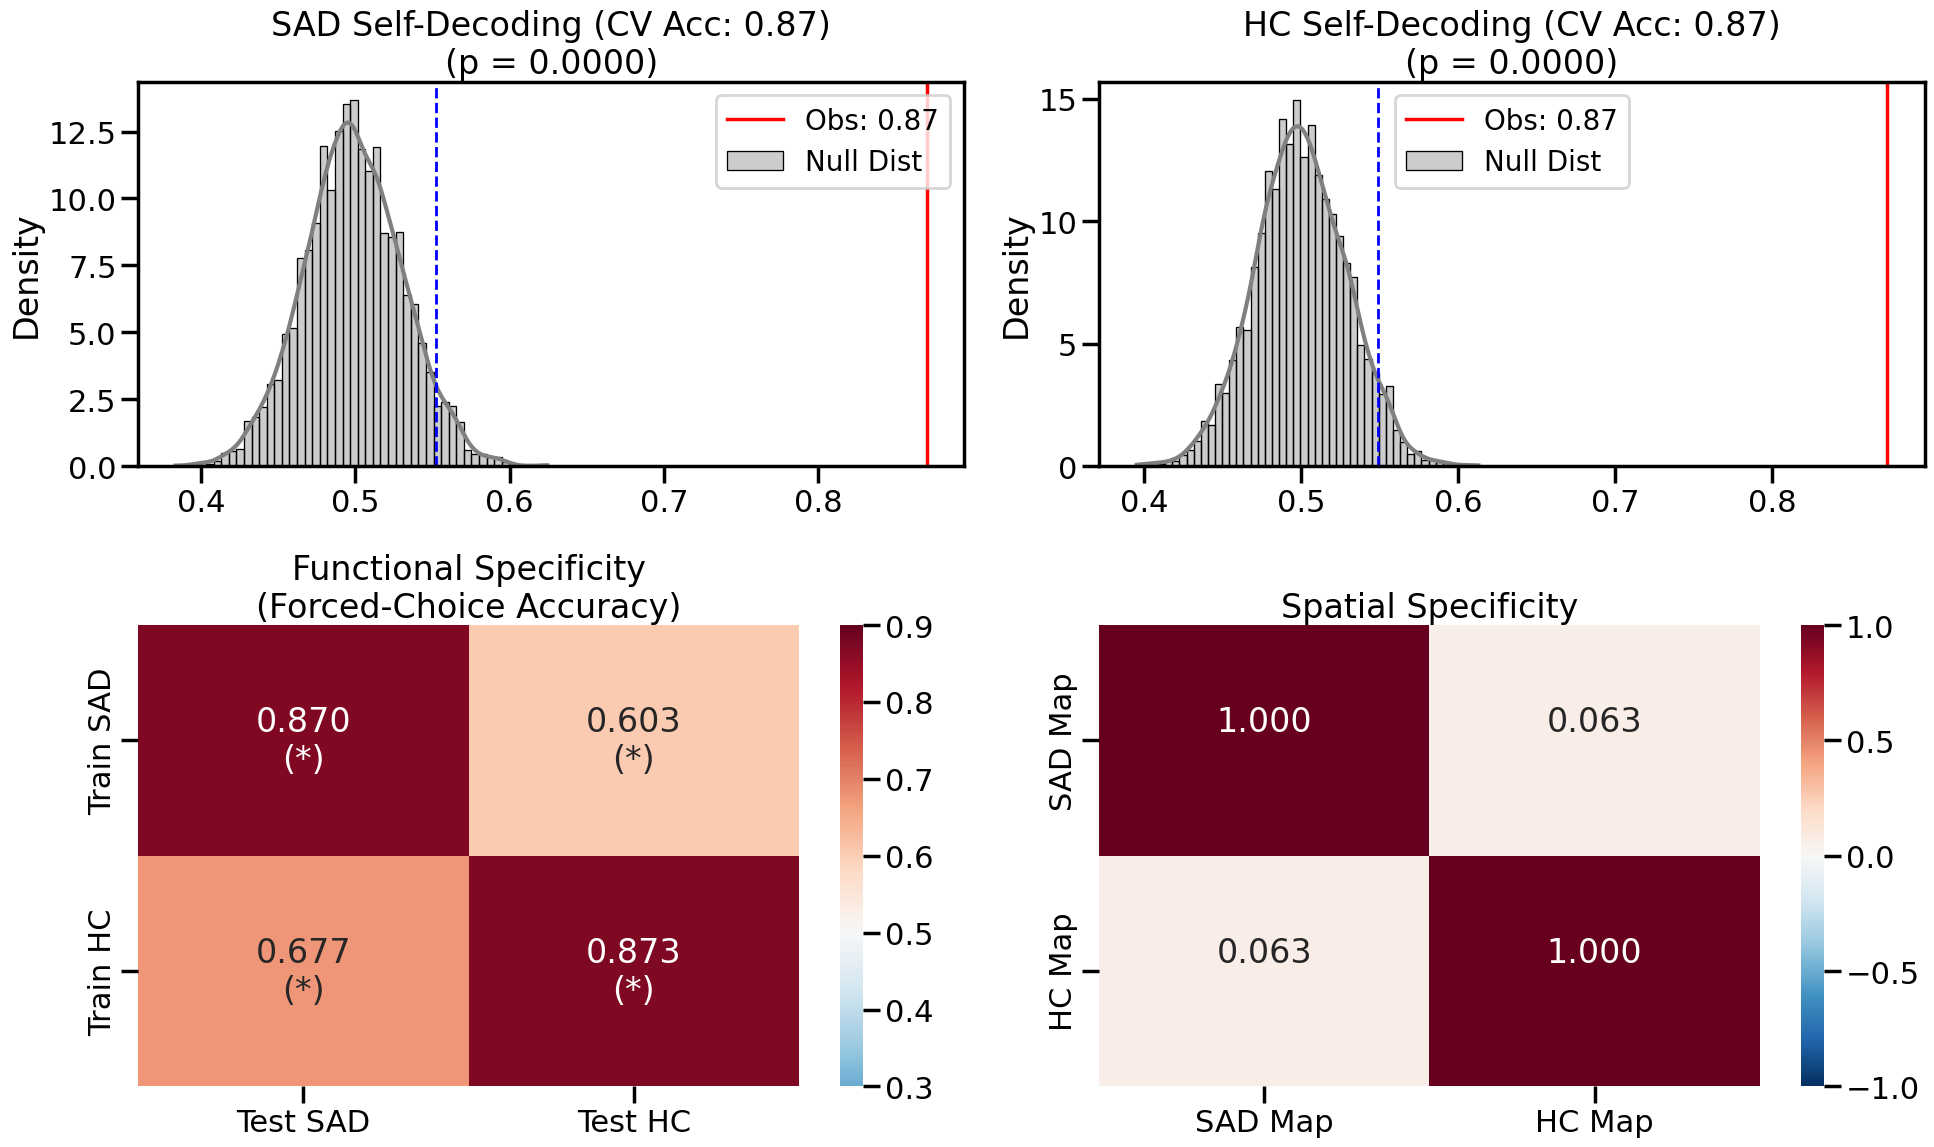

In [16]:
N_JOBS = 1
# Cell 6: Analysis 1.1 - Neural Dissociation Execution
# Protocol: SAD -> HC
# Updates:
#   - Uses 'run_pairwise_decoding_analysis' (Forced-Choice Accuracy).
#   - Functional Specificity Heatmap uses Mean CV Accuracy for diagonals (Evaluation).
#   - Cross-Decoding uses the 'final_model' (Refitted on full data) on the other group.
#   - Hyperparameter selected from 20 values (0.01-100) using training data only.
#   - 5-fold CV, repeated 10 times with different splits; mean performance reported.
#   - Forced-choice accuracy used to mitigate inter-site activation differences.

print("--- Running Analysis 1.1: Neural Dissociation ---")

target_param = 'classification__C'  # Variable for the hyperparameter key
cache_cell6 = os.path.join(CHECKPOINT_DIR, 'cell_6.joblib')

# =============================================================================
# CHECK CACHE
# =============================================================================
if os.path.exists(cache_cell6):
    print(f"  [LOAD] Found cached results in {cache_cell6}. Skipping computation.")
    results_11 = joblib.load(cache_cell6)
    
    # RECONSTRUCT res_sad and res_hc so the plotting code can find them
    res_sad = {
        'accuracy': results_11["acc_sad_cv"],
        'haufe_pattern': results_11["map_sad"],
        'model_sad': results_11['model_sad']
    }
    res_hc = {
        'accuracy': results_11["acc_hc_cv"],
        'haufe_pattern': results_11["map_hc"],
        'model_hc': results_11['model_hc']
    }
    
    # Unpack remaining variables for the visualization block
    perm_acc_sad = results_11["perm_dist_sad"]
    perm_acc_hc = results_11["perm_dist_hc"]
    func_matrix = results_11["func_matrix"]
    func_pvals = results_11["p_func_pvals"]
    obs_sim = results_11["sim_spatial"]
    p_sim_spatial = results_11["p_sim"]
    
    # These were assigned in your error slip but need to match the plot calls
    p_sad = results_11["p_sad"]
    p_hc = results_11["p_hc"]
    p_sad2hc = func_pvals[0, 1] 
    p_hc2sad = func_pvals[1, 0]
    mean_sad2hc = func_matrix[0, 1]
    mean_hc2sad = func_matrix[1, 0]
else:
    # =============================================================================
    # 0. Data Slicing
    # =============================================================================
    # Load Data
    try:
        X_hc, y_hc, sub_hc = get_extinction_data("HC_Placebo")
        X_sad, y_sad, sub_sad = get_extinction_data("SAD_Placebo")
        print(f"Data Loaded: SAD (n={len(np.unique(sub_sad))}), HC (n={len(np.unique(sub_hc))})")
    except ValueError as e:
        print(f"CRITICAL ERROR: {e}")
        raise

    # =============================================================================
    # TEST 1: Baseline Neural Discriminability (Self-Decoding)
    # =============================================================================
    print("\n--- TEST 1: Baseline Neural Discriminability ---")

    print("Processing SAD...")
    res_sad_dict = run_pairwise_decoding_analysis(X_sad, y_sad, sub_sad, n_repeats=N_REPEATS)
    best_c_sad = res_sad_dict[list(res_sad_dict.keys())[0]]['model'].get_params()[target_param]
    print(f"  > Best {target_param} for SAD: {best_c_sad}")

    print("Processing HC...")
    res_hc_dict = run_pairwise_decoding_analysis(X_hc, y_hc, sub_hc, n_repeats=N_REPEATS)
    best_c_hc = res_hc_dict[list(res_hc_dict.keys())[0]]['model'].get_params()[target_param]
    print(f"  > Best {target_param} for HC: {best_c_hc}")

    # Select the target contrast (CSS vs CSR)
    pair_key = "CSR vs CSS" if "CSR vs CSS" in res_sad_dict else "CSS vs CSR"
    if pair_key not in res_sad_dict or pair_key not in res_hc_dict:
        raise ValueError(f"Contrast {pair_key} not found. Check if CSS/CSR labels exist.")

    res_sad = res_sad_dict[pair_key]
    res_hc = res_hc_dict[pair_key]

    # Permutation Test (Comparing Observed CV Score against Null CV Scores)
    print(f"Running Permutation Test (Self-Decoding, {N_PERMUTATION} iter)...")
    iters_per_job = N_PERMUTATION // N_JOBS
    perm_acc_sad = np.concatenate(Parallel(n_jobs=N_JOBS)(delayed(run_perm_simple)(X_sad, y_sad, sub_sad, iters_per_job) for _ in range(N_JOBS)))
    perm_acc_hc = np.concatenate(Parallel(n_jobs=N_JOBS)(delayed(run_perm_simple)(X_hc, y_hc, sub_hc, iters_per_job) for _ in range(N_JOBS)))

    # =============================================================================
    # TEST 2: Functional Specificity (Cross-Decoding)
    # =============================================================================
    print("\n--- TEST 2: Functional Specificity ---")
    # Logic: Use Final Refit Model (Trained on All A) -> Predict All B -> Avg Subject Accuracy

    # A. SAD Model -> HC Data
    model_sad = res_sad['model'] # This is the Refit model
    # 'run_cross_decoding' calculates raw accuracy per subject
    accs_sad2hc = run_cross_decoding(model_sad, X_hc, y_hc, sub_hc, model_sad.classes_)
    mean_sad2hc = np.mean(accs_sad2hc)
    print(f"  > SAD Model -> HC Data: {mean_sad2hc:.4f}")

    # B. HC Model -> SAD Data
    model_hc = res_hc['model']
    accs_hc2sad = run_cross_decoding(model_hc, X_sad, y_sad, sub_sad, model_hc.classes_)
    mean_hc2sad = np.mean(accs_hc2sad)
    print(f"  > HC Model -> SAD Data: {mean_hc2sad:.4f}")

    # Permutation Test (Cross-Decoding)
    print(f"Running Permutation Test (Cross-Decoding, {N_PERMUTATION} iter)...")
    perm_sad2hc = np.concatenate(Parallel(n_jobs=N_JOBS)(
        delayed(run_cross_perm)(model_sad, X_hc, y_hc, sub_hc, iters_per_job) for _ in range(N_JOBS)))
    p_sad2hc = np.mean(perm_sad2hc >= mean_sad2hc)

    perm_hc2sad = np.concatenate(Parallel(n_jobs=N_JOBS)(
        delayed(run_cross_perm)(model_hc, X_sad, y_sad, sub_sad, iters_per_job) for _ in range(N_JOBS)))
    p_hc2sad = np.mean(perm_hc2sad >= mean_hc2sad)

    # =============================================================================
    # TEST 3: Spatial Specificity
    # =============================================================================
    print("\n--- TEST 3: Spatial Specificity ---")
    map_sad, map_hc = res_sad['haufe_pattern'], res_hc['haufe_pattern']
    obs_sim = cosine_similarity(map_sad.reshape(1, -1), map_hc.reshape(1, -1))[0][0]

    # Prepare Data for Permutation (Combine groups)
    X_comb = np.concatenate([X_sad, X_hc])
    y_comb = np.concatenate([y_sad, y_hc])
    sub_comb = np.concatenate([sub_sad, sub_hc])

    all_sub_maps, all_sub_groups = [], []
    perm_pipe = build_binary_pipeline(); perm_pipe.set_params(classification__C=1.0)

    # Pre-compute subject maps
    print(f"Pre-computing {len(np.unique(sub_comb))} individual subject maps...")
    for sub in np.unique(sub_comb):
        mask = sub_comb == sub
        perm_pipe.fit(X_comb[mask], y_comb[mask])
        W = perm_pipe.named_steps['classification'].coef_
        # Calculate Covariance (Scaler handles centered input)
        cov = np.cov(X_comb[mask], rowvar=False)
        A = cov @ W.T
        
        if perm_pipe.classes_[1] == 'CSS': A = -A 
        all_sub_maps.append(A.flatten())
        all_sub_groups.append("SAD" if sub in sub_sad else "HC")

    # Run Spatial Permutation
    print(f"Running Spatial Permutation ({N_PERMUTATION} iter)...")
    perm_sims = np.array(Parallel(n_jobs=N_JOBS)(delayed(run_spatial_perm)(i, np.array(all_sub_maps), np.array(all_sub_groups)) for i in range(N_PERMUTATION)))

    p_sim_spatial = 2 * min(np.mean(perm_sims <= obs_sim), np.mean(perm_sims >= obs_sim))

    # Assemble Result Dictionary
    func_matrix = np.array([[res_sad['accuracy'], mean_sad2hc], [mean_hc2sad, res_hc['accuracy']]])
    func_pvals = np.array([[p_sad, p_sad2hc], [p_hc2sad, p_hc]])
    
    results_11 = {
        "acc_sad_cv": res_sad['accuracy'], 
        "p_sad": p_sad, 
        "acc_hc_cv": res_hc['accuracy'], 
        "p_hc": p_hc, 
        "func_matrix": func_matrix, 
        "p_func_pvals": func_pvals,
        "sim_spatial": obs_sim, 
        "p_sim": p_sim_spatial,
        "map_sad": map_sad, 
        "map_hc": map_hc,
        "perm_dist_sad": perm_acc_sad, 
        "perm_dist_hc": perm_acc_hc,
        "model_sad": res_sad['model'], # The refitted SAD pipeline
        "model_hc": res_hc['model']    # The refitted HC pipeline
    }
    
    # Save to Cache
    save_checkpoint(6, {
        "results_11": results_11
    })
    print(f"  [SAVE] Analysis complete. Results cached to {cache_cell6}.")

# =============================================================================
# VISUALIZATION
# =============================================================================
print("\n--- Generating Plots ---")
sns.set_context("poster")

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# Row 1: Self-Decoding (Permutation Distribution)
p_sad = plot_dist_with_thresh(perm_acc_sad, res_sad['accuracy'], fig.add_subplot(gs[0, 0]), 
                              f"SAD Self-Decoding (CV Acc: {res_sad['accuracy']:.2f})")
p_hc = plot_dist_with_thresh(perm_acc_hc, res_hc['accuracy'], fig.add_subplot(gs[0, 1]), 
                             f"HC Self-Decoding (CV Acc: {res_hc['accuracy']:.2f})")

# Row 2: Matrices
# Functional Specificity
ax3 = fig.add_subplot(gs[1, 0])

# Matrix: [CV Accuracy] vs [Mean Cross Accuracy]
# Diagonals: Generalization within group (CV)
# Off-Diagonals: Generalization across groups (Cross-Decoding)
func_matrix = np.array([
    [res_sad['accuracy'], mean_sad2hc], 
    [mean_hc2sad, res_hc['accuracy']]
])
func_pvals = np.array([[p_sad, p_sad2hc], [p_hc2sad, p_hc]])

annot_func = np.empty_like(func_matrix, dtype=object)
for i in range(2):
    for j in range(2):
        val_str = f"{func_matrix[i, j]:.3f}"
        sig_str = "*" if func_pvals[i, j] < 0.05 else ""
        annot_func[i, j] = f"{val_str}\n({sig_str})"

sns.heatmap(func_matrix, annot=annot_func, fmt="", cmap="RdBu_r", center=0.5, vmin=0.3, vmax=0.9, cbar=True,
            xticklabels=['Test SAD', 'Test HC'], yticklabels=['Train SAD', 'Train HC'], ax=ax3)
ax3.set_title("Functional Specificity\n(Forced-Choice Accuracy)")

# Spatial Specificity
ax4 = fig.add_subplot(gs[1, 1])
spatial_matrix = np.array([[1.0, obs_sim], [obs_sim, 1.0]])
spatial_pvals = np.array([[0.0, p_sim_spatial], [p_sim_spatial, 0.0]])
annot_spatial = np.empty_like(spatial_matrix, dtype=object)
for i in range(2):
    for j in range(2):
        star = "*" if (spatial_pvals[i, j] < 0.05 and i != j) else ""
        annot_spatial[i, j] = f"{spatial_matrix[i, j]:.3f}\n{star}"

sns.heatmap(spatial_matrix, annot=annot_spatial, fmt="", cmap="RdBu_r", center=0, vmin=-1, vmax=1, cbar=True,
            xticklabels=['SAD Map', 'HC Map'], yticklabels=['SAD Map', 'HC Map'], ax=ax4)
ax4.set_title("Spatial Specificity")

plt.tight_layout()
plt.show()

In [17]:
# Cell 17: Corrected Cross-Phase Permutation (Strict Cell 6 Mirror)
# This ensures the null distribution is centered at 0.50 as required.

def run_strict_forced_choice_perm(model, X, y, sub, iters):
    """
    Strictly mirrors the forced-choice logic for the null distribution.
    Shuffles labels and then calculates the pairwise accuracy per subject.
    """
    perm_accs = []
    classes = model.classes_
    
    for _ in range(iters):
        # Shuffle the labels to create the null state
        y_shuffled = np.random.permutation(y)
        
        # Calculate subject-level forced-choice accuracy for this shuffle
        # This is the exact internal logic of your 'run_cross_decoding'
        sub_scores = []
        for s in np.unique(sub):
            mask = (sub == s)
            X_s, y_s = X[mask], y_shuffled[mask]
            
            # Identify indices for the two conditions
            idx0 = np.where(y_s == classes[0])[0]
            idx1 = np.where(y_s == classes[1])[0]
            
            if len(idx0) > 0 and len(idx1) > 0:
                # Average evidence for each class
                # (Mirroring the decision_function logic from Cell 6)
                d_scores = model.decision_function(X_s)
                mean_ev_0 = np.mean(d_scores[idx0])
                mean_ev_1 = np.mean(d_scores[idx1])
                
                # In forced choice, the 'higher' evidence wins
                # Accuracy is 1 if the higher evidence matches the label
                if mean_ev_1 > mean_ev_0:
                    sub_scores.append(1.0)
                else:
                    sub_scores.append(0.0)
        
        perm_accs.append(np.mean(sub_scores))
    return np.array(perm_accs)

# --- Execution ---
print("--- Regenerating Valid Null Distributions (Centered at 0.5) ---")

for grp in ["SAD", "HC"]:
    X_rst, y_rst, sub_rst = get_phase_data(f"{grp}_Placebo", "rst")
    model_ext = results_11['model_sad'] if grp == "SAD" else results_11['model_hc']
    
    # Run the corrected permutation
    iters_per_job = N_PERMUTATION // N_JOBS
    perm_dist_corrected = np.concatenate(Parallel(n_jobs=N_JOBS)(
        delayed(run_strict_forced_choice_perm)(model_ext, X_rst, y_rst, sub_rst, iters_per_job) 
        for _ in range(N_JOBS)))
    
    # Update results
    perm_results[grp] = perm_dist_corrected
    gen_pvals[i, 1] = np.mean(perm_dist_corrected >= gen_matrix[i, 1])

print("Permutations complete. Please re-run the visualization cell.")

--- Regenerating Valid Null Distributions (Centered at 0.5) ---


NameError: name 'perm_results' is not defined

In [24]:
for name in ['SAD', 'HC']:
        # Appended fear_network to differentiate from future whole-brain analysis
        cache_file = os.path.join(CHECKPOINT_DIR, f'perm_results_{name}_fear_network_2way.joblib')

In [25]:
cache_file

'/Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/MemoryFearNetwork/checkpoint/perm_results_HC_fear_network_2way.joblib'

--- Cell 7: Voxel-wise Spatial Analysis (Fear Network with Symmetry Fallback) ---
  [CONFIG] Using FDR Alpha: 0.050000000000000044
  [CALC] No cache for SAD. Running 5000 permutations...
  > Calculating robust observed weights (n_boot=100)...
  > Running 5000 permutations on 1 cores...
  [CACHE] Saved raw results to: /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/MemoryFearNetwork/checkpoint/perm_results_SAD_fear_network_2way.joblib
  > SAD Initial FDR-significant voxels: 48
  [CALC] No cache for HC. Running 5000 permutations...
  > Calculating robust observed weights (n_boot=100)...
  > Running 5000 permutations on 1 cores...
  [CACHE] Saved raw results to: /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/MemoryFearNetwork/checkpoint/perm_results_HC_fear_network_2way.joblib
  > HC Initial FDR-significant voxels: 0

Results for SAD (ROI-FDR):
ROI Name                  | Voxels   | % ROI
----------------------------------------

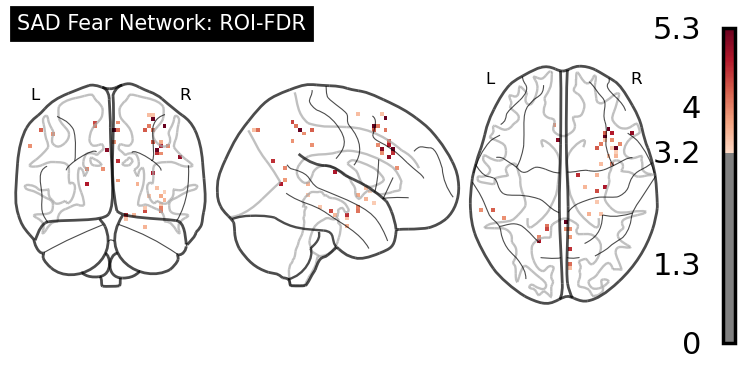


Results for HC (Top 48 (Matched)):
ROI Name                  | Voxels   | % ROI
--------------------------------------------------
right_SFG                 | 10       | 1.41%
left_MFG                  | 7        | 0.82%
right_hippocampus         | 7        | 3.27%
right_VVC                 | 7        | 0.53%
left_IFG                  | 2        | 0.43%
left_Precuneus            | 2        | 0.26%
right_SMG                 | 2        | 0.29%
right_Precuneus           | 2        | 0.23%
left_acc                  | 1        | 0.39%
left_amygdala             | 1        | 0.97%
left_insula               | 1        | 0.29%
left_VVC                  | 1        | 0.07%
left_AG                   | 1        | 0.29%
right_amygdala            | 1        | 0.96%
right_vmpfc               | 1        | 0.58%
right_AG                  | 1        | 0.21%
right_MFG                 | 1        | 0.13%


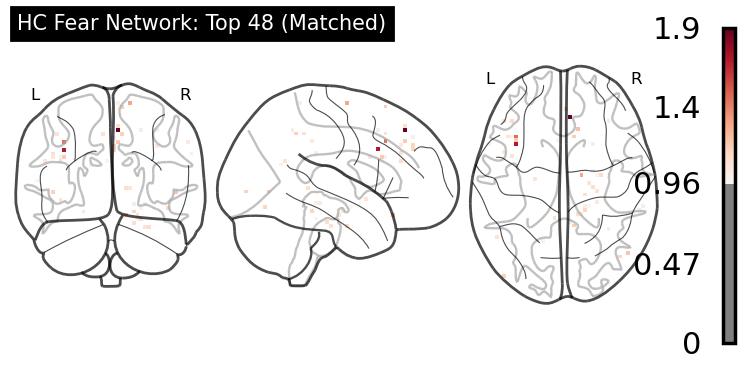

--- Cell 7 Fear Network Analysis Complete ---


In [26]:
#stage 7 Haufe/Z-scoring in fear network
STAGE = 7
if STAGE is None or STAGE == 7:
    print("--- Cell 7: Voxel-wise Spatial Analysis (Fear Network with Symmetry Fallback) ---")
    alpha_val = thresh_hold_p if 'thresh_hold_p' in locals() else 0.05
    fdr_alpha = 1 - alpha_val if alpha_val > 0.5 else alpha_val
    print(f"  [CONFIG] Using FDR Alpha: {fdr_alpha}")
    
    ROI_DIR = "/Users/xiaoqianxiao/tool/parcellation/ROIs/MemoryFearNetwork"
    ROI_ORDER = [
            'left_acc', 'left_amygdala', 'left_hippocampus', 'left_insula', 'left_vmpfc', 'left_VVC', 'left_AG', 'left_SMG', 'left_IFG', 'left_MFG', 'left_SFG', 'left_Precuneus',
            'right_acc', 'right_amygdala', 'right_hippocampus', 'right_insula', 'right_vmpfc', 'right_VVC', 'right_AG', 'right_SMG', 'right_IFG', 'right_MFG', 'right_SFG', 'right_Precuneus'
        ]
    target_pair = ['CSR', 'CSS']
    
    # Storage for raw data and initial FDR counts
    raw_results = {}
    fdr_counts = {}
    
    for name in ['SAD', 'HC']:
        # Appended fear_network to differentiate from future whole-brain analysis
        cache_file = os.path.join(CHECKPOINT_DIR, f'perm_results_{name}_fear_network_2way.joblib')
        
        # 1. LOAD CACHE OR CALCULATE
        if os.path.exists(cache_file):
            print(f"  [LOAD] {name} fear_network permutations found.")
            cache = joblib.load(cache_file)
            obs_w, null_w, p_raw = cache['obs_weights'], cache['null_weights'], cache['p_values_raw']
        else:
            print(f"  [CALC] No cache for {name}. Running {N_PERMUTATION} permutations...")
            X_p, y_p, sub_p = get_extinction_data(f"{name}_Placebo")
            mask_cls = np.isin(y_p, target_pair)
            
            # Retrieve best C from Analysis 1.1 (Cell 6) results
            best_c = results_11[f"acc_{name.lower()}_cv"] # Or however you stored the dict in Cell 6
            # If Cell 6 used the res_sad/res_hc naming convention:
            best_c = res_sad['best_C'] if name == 'SAD' else res_hc['best_C']
            
            obs_w, null_w, p_raw = run_raw_permutations(
                X_p[mask_cls], y_p[mask_cls], sub_p[mask_cls], 
                build_binary_pipeline(), best_c, N_PERMUTATION
            )
            save_permutation_results(obs_w, null_w, p_raw, cache_file)
            
        # Initial FDR Check to determine the logic for Phase 2
        _, sig_mask, _, _ = apply_flexible_voxel_correction(
            obs_w, null_w, p_raw, method='roi', roi_names=ROI_ORDER, roi_dir=ROI_DIR
        )
        
        raw_results[name] = {'obs': obs_w, 'null': null_w, 'p_raw': p_raw}
        fdr_counts[name] = np.sum(sig_mask)
        print(f"  > {name} Initial FDR-significant voxels: {fdr_counts[name]}")

    # 2. MATCHING LOGIC
    # CASE 1: Both have sig voxels -> Keep both (ROI-FDR)
    if fdr_counts['SAD'] > 0 and fdr_counts['HC'] > 0:
        match_cfg = {'SAD': None, 'HC': None}
    # CASE 2: SAD has sig, HC does not -> HC matches SAD count
    elif fdr_counts['SAD'] > 0 and fdr_counts['HC'] == 0:
        match_cfg = {'SAD': None, 'HC': fdr_counts['SAD']}
    # CASE 3: HC has sig, SAD does not -> SAD matches HC count
    elif fdr_counts['HC'] > 0 and fdr_counts['SAD'] == 0:
        match_cfg = {'SAD': fdr_counts['HC'], 'HC': None}
    # CASE 4: Both have 0 -> Both use 2% fallback
    else:
        match_cfg = {'SAD': 'fallback', 'HC': 'fallback'}

    # 3. FINAL CORRECTION, RECONSTRUCTION & PLOTTING
    for name in ['SAD', 'HC']:
        cfg = match_cfg[name]
        data = raw_results[name]
        
        if cfg == 'fallback':
            z_scores, sig_mask, roi_stats, mode = apply_flexible_voxel_correction(
                data['obs'], data['null'], data['p_raw'], method='top_n', 
                roi_names=ROI_ORDER, roi_dir=ROI_DIR, fallback_percentile=98)
        else:
            # If cfg is None, it uses FDR. If cfg is a number, it uses match_count.
            z_scores, sig_mask, roi_stats, mode = apply_flexible_voxel_correction(
                data['obs'], data['null'], data['p_raw'], method='roi', 
                roi_names=ROI_ORDER, roi_dir=ROI_DIR, match_count=cfg)

        # Direction Correction for plotting (CSR+ = Red)
        X_p, y_p, _ = get_extinction_data(f"{name}_Placebo")
        mask_cls = np.isin(y_p, target_pair)
        dummy_pipe = build_binary_pipeline(); dummy_pipe.fit(X_p[mask_cls], y_p[mask_cls])
        if dummy_pipe.classes_[0] == 'CSR': z_scores = -z_scores
        
        print(f"\nResults for {name} ({mode}):")
        print(f"{'ROI Name':<25} | {'Voxels':<8} | {'% ROI'}")
        print("-" * 50)
        for roi, stats in sorted(roi_stats.items(), key=lambda x: x[1]['count'], reverse=True):
            print(f"{roi:<25} | {stats['count']:<8} | {stats['perc']:.2f}%")

        # Visualization
        z_img = reconstruct_roi_map(z_scores * sig_mask, ROI_ORDER, ROI_DIR)
        if z_img:
            # Dynamically set threshold to the minimum significant voxel magnitude
            v_thresh = np.min(np.abs(z_scores[sig_mask])) if np.sum(sig_mask) > 0 else 1.96
            plotting.plot_glass_brain(z_img, threshold=v_thresh, colorbar=True, cmap='RdBu_r', 
                                      title=f"{name} Fear Network: {mode}")
            plt.show()

    print("--- Cell 7 Fear Network Analysis Complete ---")

In [ ]:
#stage 9 permutated importance in fear network
from sklearn.base import clone
import os
import joblib
import numpy as np

# Configuration Variables
N_NULL_PERMS = 5000  
ALPHA_LEVEL = 0.05
importance_mask_permutated = {}
importance_scores_permutated = {}

print(f"--- Stage 9: Generating Empirical Significance Masks (N={N_NULL_PERMS}) ---")

for group_name in ['SAD', 'HC']:
    # 1. DEFINE CACHE PATHS
    cache_null = os.path.join(CHECKPOINT_DIR, f"null_dist_{group_name}.joblib")
    cache_actual = os.path.join(CHECKPOINT_DIR, f"actual_imp_{group_name}.joblib")
    
    # 2. LOAD OR CALCULATE ACTUAL IMPORTANCE
    if os.path.exists(cache_actual):
        print(f"  [LOAD] Found actual importance for {group_name}.")
        actual_imp = joblib.load(cache_actual)
    else:
        # 2. DATA PREP
        data_ptr = data_subsets[f"{group_name}_Placebo"]["ext"]
        mask_cls = np.isin(data_ptr["y"], ['CSR', 'CSS'])
        X_target, y_target = data_ptr["X"][mask_cls], data_ptr["y"][mask_cls]
        
        # Use the specific trained model for each group
        model_template = res_sad['model'] if group_name == 'SAD' else res_hc['model']
        print(f"  [CALC] Computing Actual Importance for {group_name}...")
        actual_res = permutation_importance(
            model_template, X_target, y_target,
            n_repeats=5000, scoring=forced_choice_scorer, n_jobs=-1, random_state=RANDOM_STATE
        )
        # Ensure we grab the array from the Bunch object
        actual_imp = actual_res.importances_mean if hasattr(actual_res, 'importances_mean') else actual_res
        joblib.dump(actual_imp, cache_actual)
    
    importance_scores_permutated[group_name] = actual_imp

    # 4. LOAD OR CALCULATE NULL DISTRIBUTION
    if os.path.exists(cache_null):
        print(f"  [LOAD] Found null distribution for {group_name}. Skipping refits.")
        null_dist = joblib.load(cache_null)
    else:
        print(f"  [CALC] Computing Null Distribution (5,000 shuffles)...")
        n_features = X_target.shape[1]
        null_dist = np.zeros((N_NULL_PERMS, n_features))

        for i in range(N_NULL_PERMS):
            y_shuffled = np.random.permutation(y_target)
            
            # FIT: Necessary to see how the model behaves on noise
            null_model = clone(model_template).fit(X_target, y_shuffled)
            
            # IMPORTANT: n_repeats=1 is enough for the null items to save time
            null_res = permutation_importance(
                null_model, X_target, y_shuffled,
                n_repeats=1, scoring=forced_choice_scorer, n_jobs=-1
            )
            null_dist[i, :] = null_res.importances_mean if hasattr(null_res, 'importances_mean') else null_res

            if (i + 1) % 500 == 0:
                print(f"   > {group_name}: {i+1}/{N_NULL_PERMS} permutations complete.")
        
        joblib.dump(null_dist, cache_null)

    # 5. MASK GENERATION (Empirical P-value)
    # P-value = (Number of times null >= actual) / Total permutations
    p_values = (null_dist >= actual_imp).mean(axis=0)
    
    # Final Significance Mask
    sig_mask = (p_values < ALPHA_LEVEL) & (actual_imp > 0)
    importance_mask_permutated[group_name] = sig_mask

    print(f"   > Result: {np.sum(sig_mask)} voxels significant at p < {ALPHA_LEVEL}.")

# 6. SAVE EVERYTHING (Persistent across sessions)
# This prevents ever having to run the 5,000 refits again
save_checkpoint(9, {
    "importance_mask_permutated": importance_mask_permutated,
    "importance_scores_permutated": importance_scores_permutated,
    "p_values_permutated": p_values # Added for your records
})

save_intermediate("stage09_permutation_masks", {
    "importance_mask_permutated": importance_mask_permutated,
    "importance_scores_permutated": importance_scores_permutated
})

print("--- Stage 9 Complete: All masks and null distributions stored ---")

--- Stage 9: Generating Empirical Significance Masks (N=5000) ---
  [CALC] Computing Actual Importance for SAD...
  [CALC] Computing Null Distribution (5,000 shuffles)...
   > SAD: 500/5000 permutations complete.
   > SAD: 1000/5000 permutations complete.
   > SAD: 1500/5000 permutations complete.
   > SAD: 2000/5000 permutations complete.
   > SAD: 2500/5000 permutations complete.
   > SAD: 3000/5000 permutations complete.
   > SAD: 3500/5000 permutations complete.
   > SAD: 4000/5000 permutations complete.


--- Running Analysis 1.2: Static Representational Topology (I > 0, p < .05| Centroid) ---
  [LOAD] Found existing RDM results. Skipping Crossnobis calculation...


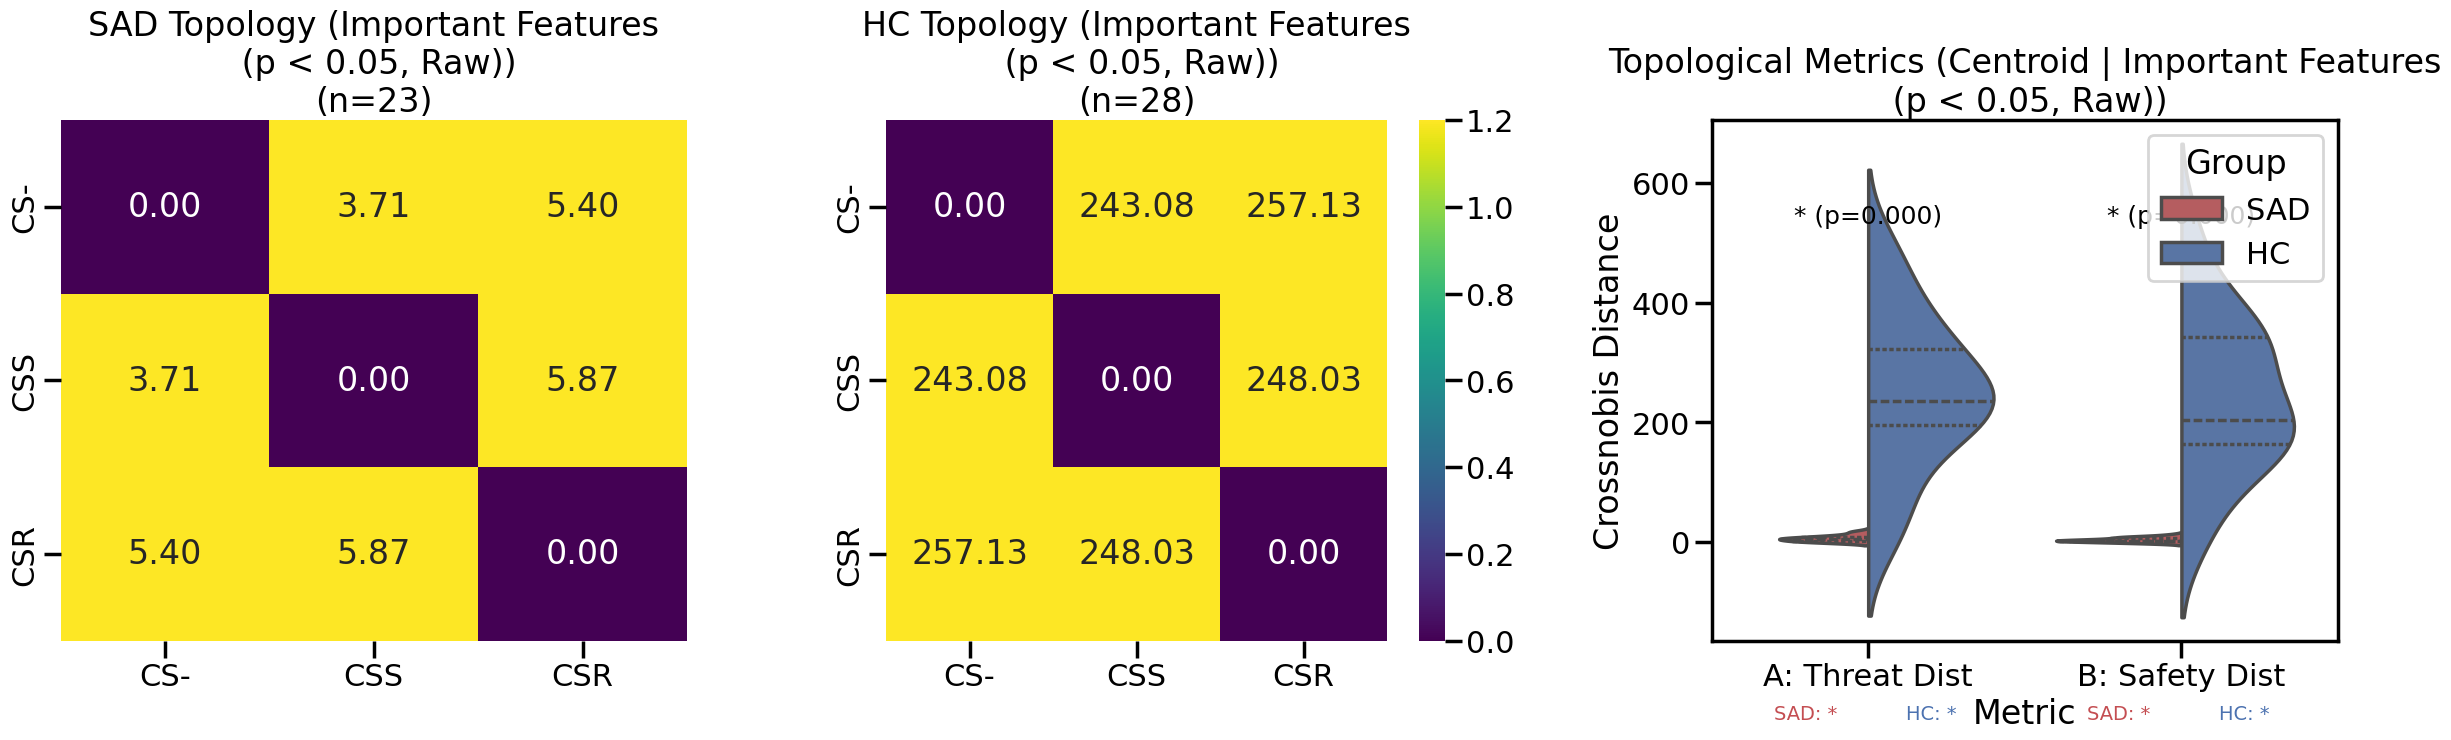

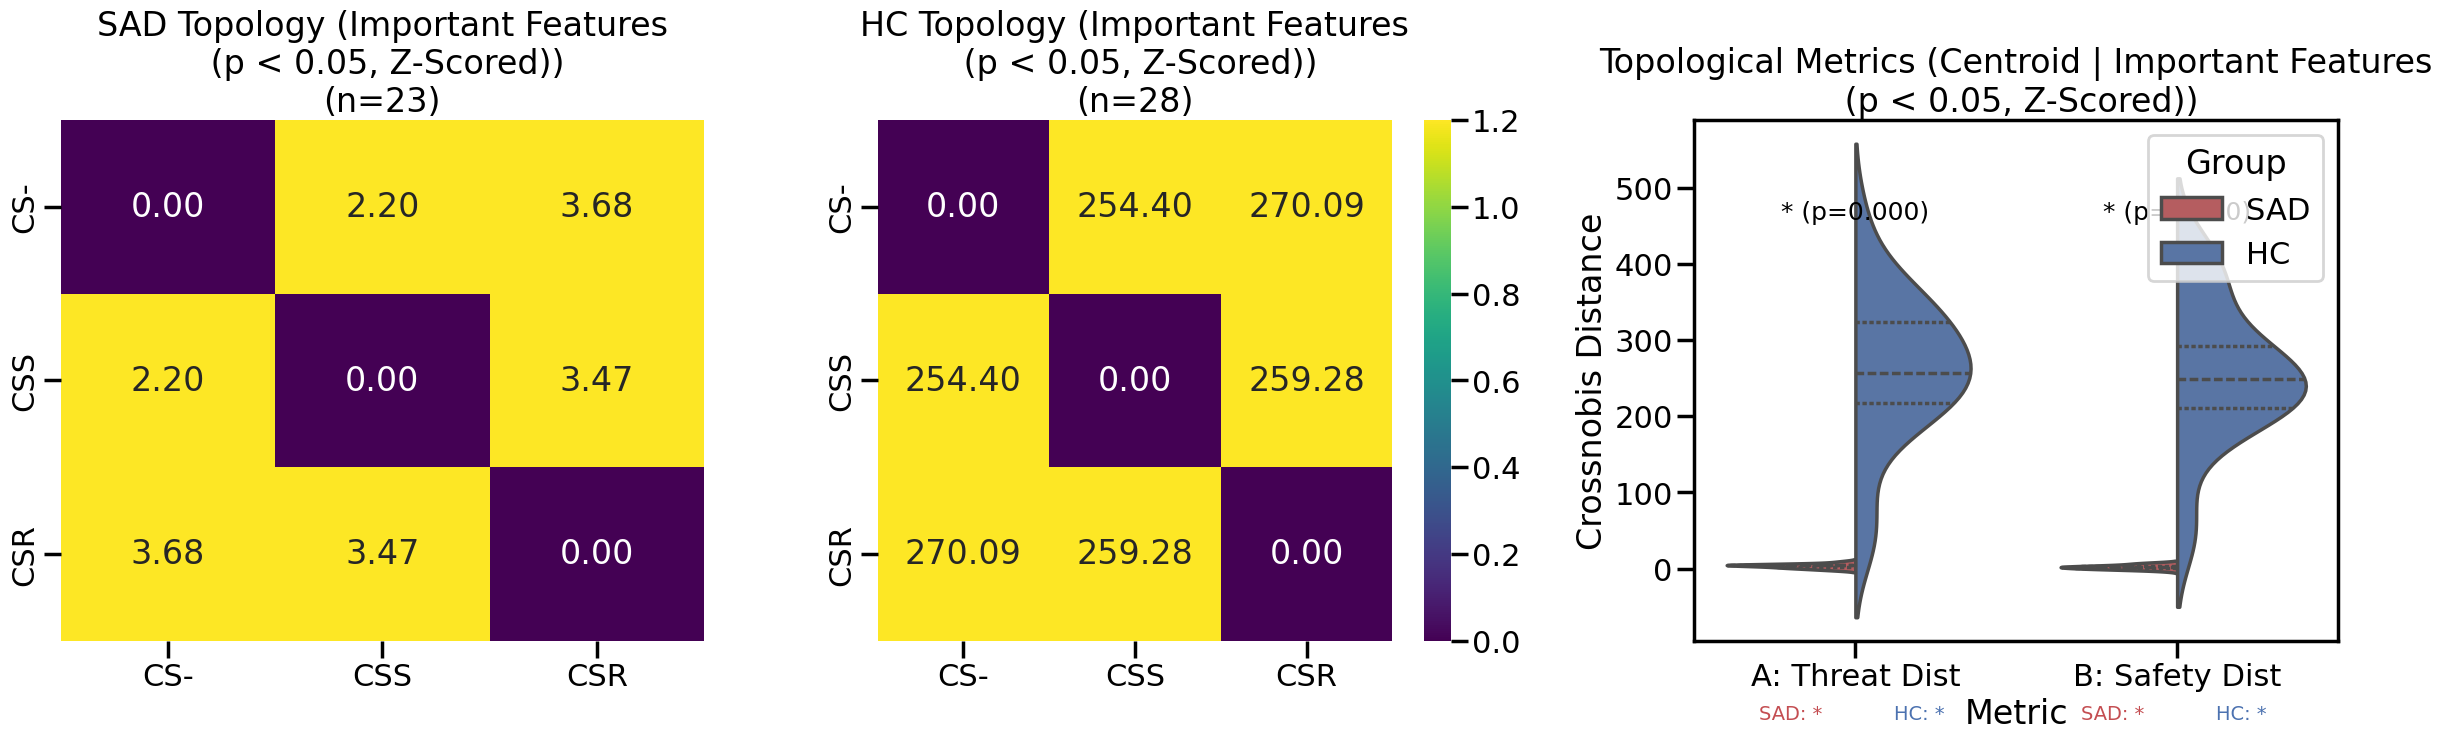

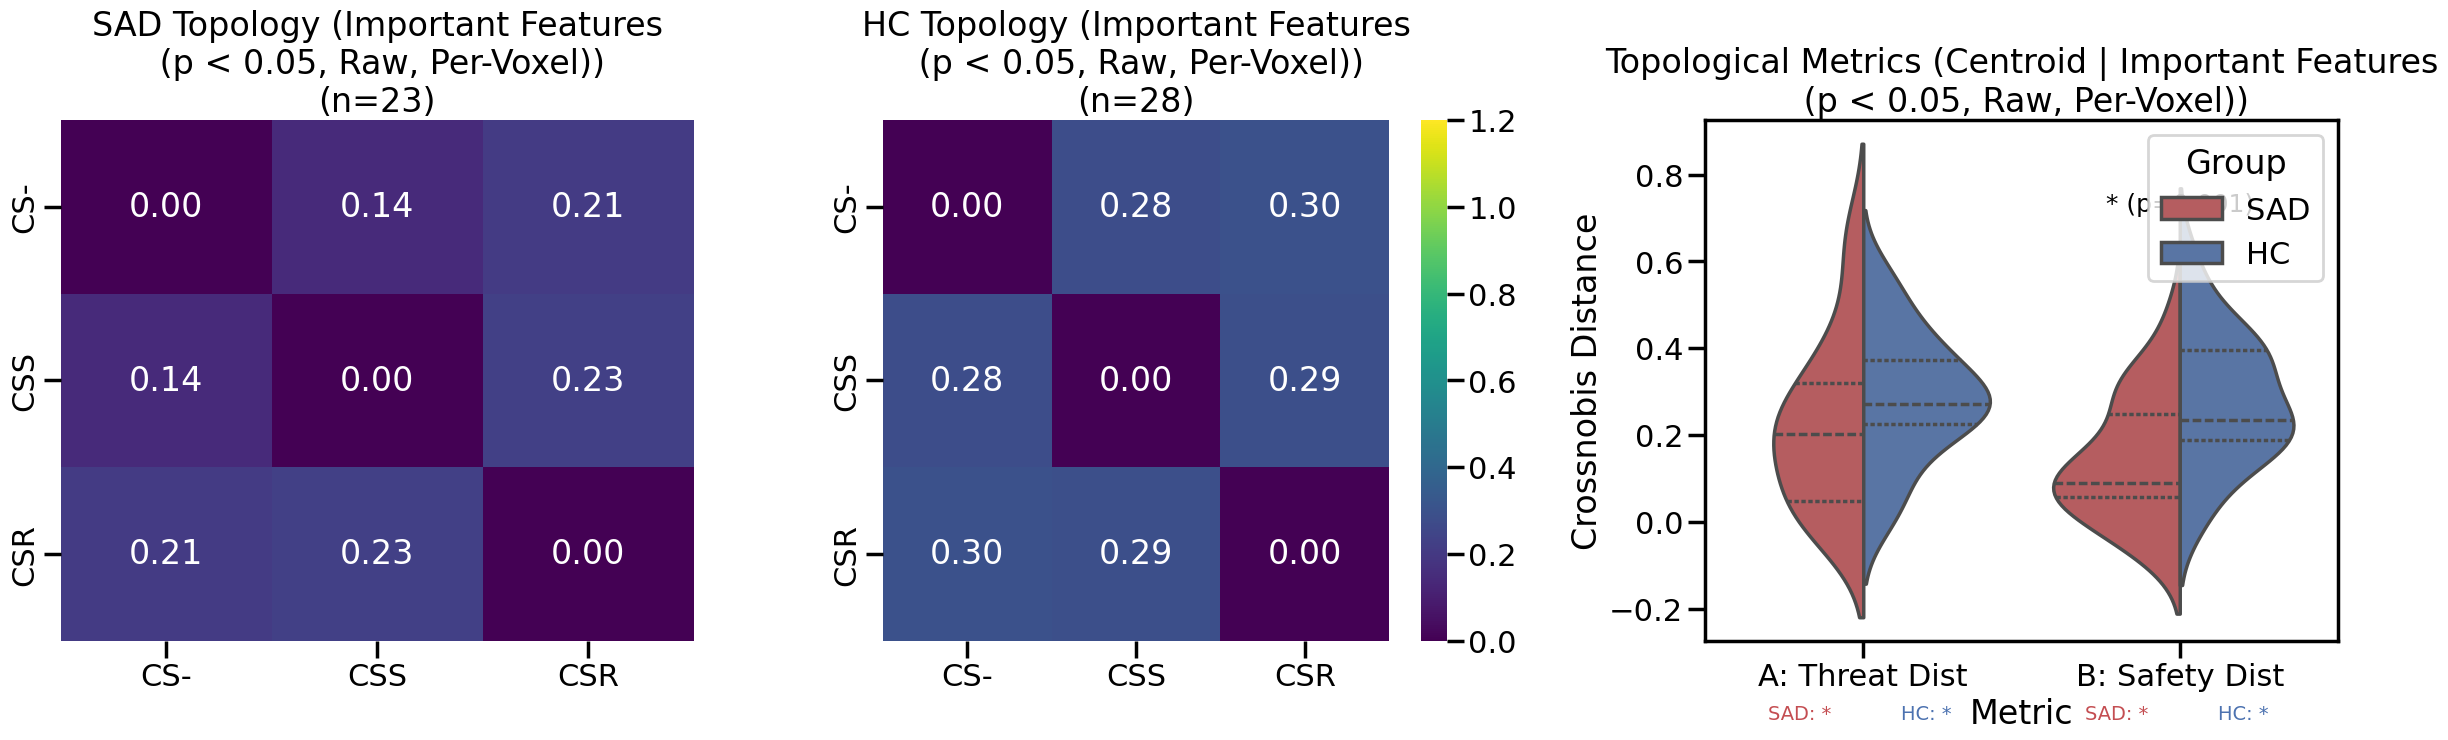


INDEX (PER-VOXEL)         | GROUP | MEAN       | t(vs 0)  | p(vs 0)  || t(GroupDiff) | p(GroupDiff)
--------------------------------------------------------------------------------------------------------------
Threat vs Safety (PV)     | SAD   | 0.225674   | 5.594    | 0.0000   || -1.269       | 0.2060      
                          | HC    | 0.286081   | 10.348   | 0.0000   ||              |             
--------------------------------------------------------------------------------------------------------------
Safety vs Backgr (PV)     | SAD   | 0.142575   | 4.884    | 0.0001   || -3.369       | 0.0014      
                          | HC    | 0.280370   | 9.919    | 0.0000   ||              |             
--------------------------------------------------------------------------------------------------------------


In [53]:
# Cell 10: Analysis 1.2 - Static Representational Topology (features with positive importance + p at .05)
# Objective: Characterize the stable organization of the social learning space.
# Method: Cross-validated Mahalanobis (crossnobis) distance with shrinkage covariance, averaged over split-half repeats.
# Tests: Group Comparison (SAD vs HC) AND One-Sample Test (Dist > 0).
# Reporting: Raw, z-scored, and per-voxel normalized crossnobis distances.

print("--- Running Analysis 1.2: Static Representational Topology (I > 0, p < .05| Centroid) ---")

from scipy.stats import ttest_1samp

# Global Constants
RDM_CONDITIONS = ["CS-", "CSS", "CSR"] 

cache_cell10 = os.path.join(CHECKPOINT_DIR, f"cell_10.joblib")
if os.path.exists(cache_cell10):
    print(f"  [LOAD] Found existing RDM results. Skipping Crossnobis calculation...")
    results_12 = joblib.load(cache_cell10)['results_12']
    # Extract calculated RDMs for plotting/stats blocks
    rdms_sad_raw = results_12["rdms_sad_raw"]
    rdms_hc_raw = results_12["rdms_hc_raw"]
    rdms_sad_z = results_12["rdms_sad_z"]
    rdms_hc_z = results_12["rdms_hc_z"]
    rdms_sad_raw_pv = results_12["rdms_sad_raw_pv"]
    rdms_hc_raw_pv = results_12["rdms_hc_raw_pv"]
else:
    # =============================================================================
    # 0. Feature Selection (All Features)
    print("\n[Step 0] Using all features (no feature selection).")
    importance_masks = importance_mask_permutated.copy()

    #mask_sad_top5 = np.ones(X_ext.shape[1], dtype=bool)
    #mask_hc_top5 = np.ones(X_ext.shape[1], dtype=bool)
    #use all important voxels
    mask_sad_top5 = importance_masks['SAD']
    mask_hc_top5 = importance_masks['HC']
    # =============================================================================
    # 1. Data Preparation (Recovering CS-)
    # =============================================================================
    print("\n[Step 1] Preparing Centroid Data...")

    # Validate Source Data
    if 'X_ext' not in locals() or 'y_ext' not in locals():
        raise ValueError("Global 'X_ext' variables missing. Cannot retrieve CS- trials (Cell 5 filtered them out).")

    # Retrieve Subject Lists from the Nested Dictionary (created in Cell 5)
    # structure: data_subsets['Group']['ext']['sub']
    try:
        known_hc = np.unique(data_subsets["HC_Placebo"]["ext"]["sub"])
        known_sad = np.unique(data_subsets["SAD_Placebo"]["ext"]["sub"])
    except (KeyError, TypeError):
        raise ValueError("Data structure mismatch. Ensure Cell 5 generated 'data_subsets' with ['ext'] keys.")

    # Create a temporary group mapping array matching the global X_ext
    group_ext = np.array(["Unknown"] * len(sub_ext), dtype=object)
    group_ext[np.isin(sub_ext, known_hc)] = "HC"
    group_ext[np.isin(sub_ext, known_sad)] = "SAD"

    # Filter Global Data for RDM Conditions
    mask_conds = np.isin(y_ext, RDM_CONDITIONS)
    X_raw = X_ext[mask_conds]
    y_raw = y_ext[mask_conds]
    sub_raw = sub_ext[mask_conds]
    grp_raw = group_ext[mask_conds]

    # Split by Group
    mask_sad_grp = (grp_raw == "SAD")
    mask_hc_grp = (grp_raw == "HC")

    # Slice Features (Apply the All Features Masks)
    X_sad_12 = X_raw[mask_sad_grp][:, mask_sad_top5]
    y_sad_12 = y_raw[mask_sad_grp]
    sub_sad_12 = sub_raw[mask_sad_grp]

    X_hc_12 = X_raw[mask_hc_grp][:, mask_hc_top5]
    y_hc_12 = y_raw[mask_hc_grp]
    sub_hc_12 = sub_raw[mask_hc_grp]

    print(f"  > SAD Matrix (top 5%): {X_sad_12.shape} | HC Matrix (top 5%): {X_hc_12.shape}")

    # =============================================================================
    # 2. Centroid RDM Calculation
    # =============================================================================


    # Compute RDMs (raw + z-scored)
    print(f"  Calculating Centroid RDMs (Conditions: {RDM_CONDITIONS}) with {CROSSNOBIS_REPEATS} split-half repeats...")
    rdms_sad_raw, subs_sad_rdm = calculate_crossnobis_rdm(X_sad_12, y_sad_12, sub_sad_12, RDM_CONDITIONS, standardize=False)
    rdms_hc_raw, subs_hc_rdm = calculate_crossnobis_rdm(X_hc_12, y_hc_12, sub_hc_12, RDM_CONDITIONS, standardize=False)

    rdms_sad_z, subs_sad_rdm_z = calculate_crossnobis_rdm(X_sad_12, y_sad_12, sub_sad_12, RDM_CONDITIONS, standardize=True)
    rdms_hc_z, subs_hc_rdm_z = calculate_crossnobis_rdm(X_hc_12, y_hc_12, sub_hc_12, RDM_CONDITIONS, standardize=True)

    print(f"  > Computed RDMs (raw): SAD (n={len(subs_sad_rdm)}), HC (n={len(subs_hc_rdm)})")
    print(f"  > Computed RDMs (z-scored): SAD (n={len(subs_sad_rdm_z)}), HC (n={len(subs_hc_rdm_z)})")

    # Per-voxel normalization (scale by number of features)
    n_feat_sad = X_sad_12.shape[1]
    n_feat_hc = X_hc_12.shape[1]
    rdms_sad_raw_pv = rdms_sad_raw / n_feat_sad
    rdms_hc_raw_pv = rdms_hc_raw / n_feat_hc
    rdms_sad_z_pv = rdms_sad_z / n_feat_sad
    rdms_hc_z_pv = rdms_hc_z / n_feat_hc

    # =============================================================================
    # 3. Metrics & Statistical Tests
    # =============================================================================
    # Conditions: 0=CS-, 1=CSS, 2=CSR
    idx_cs_minus, idx_css, idx_csr = 0, 1, 2

    print("\n[Step 3] Statistical Testing...")


    # ---- RAW ----
    print("\n[RAW] Metric A: Threat (CSR) vs Safety (CSS) Distance")
    vec_a_sad_raw, vec_b_sad_raw = extract_metrics(rdms_sad_raw)
    vec_a_hc_raw, vec_b_hc_raw = extract_metrics(rdms_hc_raw)

    p_a_sad_0_raw = one_sample_test(vec_a_sad_raw, "SAD (Dist > 0)")
    p_a_hc_0_raw = one_sample_test(vec_a_hc_raw, "HC  (Dist > 0)")

    print("  > Group Comparison (SAD vs HC):")
    t_a_raw, p_a_raw, m_a_sad_raw, m_a_hc_raw = perm_ttest_ind(vec_a_sad_raw, vec_a_hc_raw, n_perm=N_PERMUTATION)
    print(f"    Diff: SAD={m_a_sad_raw:.3f}, HC={m_a_hc_raw:.3f} | t={t_a_raw:.3f}, p={p_a_raw:.4f}")

    print("\n[RAW] Metric B: Safety (CSS) vs Background (CS-) Distance")
    p_b_sad_0_raw = one_sample_test(vec_b_sad_raw, "SAD (Dist > 0)")
    p_b_hc_0_raw = one_sample_test(vec_b_hc_raw, "HC  (Dist > 0)")

    print("  > Group Comparison (SAD vs HC):")
    t_b_raw, p_b_raw, m_b_sad_raw, m_b_hc_raw = perm_ttest_ind(vec_b_sad_raw, vec_b_hc_raw, n_perm=N_PERMUTATION)
    print(f"    Diff: SAD={m_b_sad_raw:.3f}, HC={m_b_hc_raw:.3f} | t={t_b_raw:.3f}, p={p_b_raw:.4f}")

    # ---- Z-SCORED ----
    print("\n[Z-SCORED] Metric A: Threat (CSR) vs Safety (CSS) Distance")
    vec_a_sad_z, vec_b_sad_z = extract_metrics(rdms_sad_z)
    vec_a_hc_z, vec_b_hc_z = extract_metrics(rdms_hc_z)

    p_a_sad_0_z = one_sample_test(vec_a_sad_z, "SAD (Dist > 0)")
    p_a_hc_0_z = one_sample_test(vec_a_hc_z, "HC  (Dist > 0)")

    print("  > Group Comparison (SAD vs HC):")
    t_a_z, p_a_z, m_a_sad_z, m_a_hc_z = perm_ttest_ind(vec_a_sad_z, vec_a_hc_z, n_perm=N_PERMUTATION)
    print(f"    Diff: SAD={m_a_sad_z:.3f}, HC={m_a_hc_z:.3f} | t={t_a_z:.3f}, p={p_a_z:.4f}")

    print("\n[Z-SCORED] Metric B: Safety (CSS) vs Background (CS-) Distance")
    p_b_sad_0_z = one_sample_test(vec_b_sad_z, "SAD (Dist > 0)")
    p_b_hc_0_z = one_sample_test(vec_b_hc_z, "HC  (Dist > 0)")

    print("  > Group Comparison (SAD vs HC):")
    t_b_z, p_b_z, m_b_sad_z, m_b_hc_z = perm_ttest_ind(vec_b_sad_z, vec_b_hc_z, n_perm=N_PERMUTATION)
    print(f"    Diff: SAD={m_b_sad_z:.3f}, HC={m_b_hc_z:.3f} | t={t_b_z:.3f}, p={p_b_z:.4f}")

    # ---- PER-VOXEL (RAW) ----
    print("\n[PER-VOXEL RAW] Metric A: Threat (CSR) vs Safety (CSS) Distance")
    vec_a_sad_raw_pv, vec_b_sad_raw_pv = extract_metrics(rdms_sad_raw_pv)
    vec_a_hc_raw_pv, vec_b_hc_raw_pv = extract_metrics(rdms_hc_raw_pv)

    p_a_sad_0_raw_pv = one_sample_test(vec_a_sad_raw_pv, "SAD (Dist > 0)")
    p_a_hc_0_raw_pv = one_sample_test(vec_a_hc_raw_pv, "HC  (Dist > 0)")

    print("  > Group Comparison (SAD vs HC):")
    t_a_raw_pv, p_a_raw_pv, m_a_sad_raw_pv, m_a_hc_raw_pv = perm_ttest_ind(vec_a_sad_raw_pv, vec_a_hc_raw_pv, n_perm=N_PERMUTATION)
    print(f"    Diff: SAD={m_a_sad_raw_pv:.6f}, HC={m_a_hc_raw_pv:.6f} | t={t_a_raw_pv:.3f}, p={p_a_raw_pv:.4f}")

    print("\n[PER-VOXEL RAW] Metric B: Safety (CSS) vs Background (CS-) Distance")
    p_b_sad_0_raw_pv = one_sample_test(vec_b_sad_raw_pv, "SAD (Dist > 0)")
    p_b_hc_0_raw_pv = one_sample_test(vec_b_hc_raw_pv, "HC  (Dist > 0)")

    print("  > Group Comparison (SAD vs HC):")
    t_b_raw_pv, p_b_raw_pv, m_b_sad_raw_pv, m_b_hc_raw_pv = perm_ttest_ind(vec_b_sad_raw_pv, vec_b_hc_raw_pv, n_perm=N_PERMUTATION)
    print(f"    Diff: SAD={m_b_sad_raw_pv:.6f}, HC={m_b_hc_raw_pv:.6f} | t={t_b_raw_pv:.3f}, p={p_b_raw_pv:.4f}")

    # Store Results
    results_12 = {
        "rdms_sad_raw": rdms_sad_raw,
        "rdms_hc_raw": rdms_hc_raw,
        "rdms_sad_z": rdms_sad_z,
        "rdms_hc_z": rdms_hc_z,
        "rdms_sad_raw_pv": rdms_sad_raw_pv,
        "rdms_hc_raw_pv": rdms_hc_raw_pv,
        "rdms_sad_z_pv": rdms_sad_z_pv,
        "rdms_hc_z_pv": rdms_hc_z_pv,
        "metric_a_stats_raw": (t_a_raw, p_a_raw),
        "metric_b_stats_raw": (t_b_raw, p_b_raw),
        "metric_a_stats_z": (t_a_z, p_a_z),
        "metric_b_stats_z": (t_b_z, p_b_z),
        "metric_a_stats_raw_pv": (t_a_raw_pv, p_a_raw_pv),
        "metric_b_stats_raw_pv": (t_b_raw_pv, p_b_raw_pv),
        "one_sample_stats_raw": {
            "p_a_sad": p_a_sad_0_raw,
            "p_a_hc": p_a_hc_0_raw,
            "p_b_sad": p_b_sad_0_raw,
            "p_b_hc": p_b_hc_0_raw,
        },
        "one_sample_stats_z": {
            "p_a_sad": p_a_sad_0_z,
            "p_a_hc": p_a_hc_0_z,
            "p_b_sad": p_b_sad_0_z,
            "p_b_hc": p_b_hc_0_z,
        },
        "one_sample_stats_raw_pv": {
            "p_a_sad": p_a_sad_0_raw_pv,
            "p_a_hc": p_a_hc_0_raw_pv,
            "p_b_sad": p_b_sad_0_raw_pv,
            "p_b_hc": p_b_hc_0_raw_pv,
        },
    }
    save_checkpoint(10, {"results_12": results_12})
    save_intermediate("stage10_topology_stats", results_12)


# =============================================================================
# 4. Visualization
# =============================================================================
# Plot RAW
plot_topology(
    rdms_sad_raw,
    rdms_hc_raw,
    vec_a_sad_raw,
    vec_a_hc_raw,
    vec_b_sad_raw,
    vec_b_hc_raw,
    p_a_raw,
    p_b_raw,
    p_a_sad_0_raw,
    p_a_hc_0_raw,
    p_b_sad_0_raw,
    p_b_hc_0_raw,
    title_suffix="Important Features\n (p < 0.05, Raw)",
)

# Plot Z-SCORED
plot_topology(
    rdms_sad_z,
    rdms_hc_z,
    vec_a_sad_z,
    vec_a_hc_z,
    vec_b_sad_z,
    vec_b_hc_z,
    p_a_z,
    p_b_z,
    p_a_sad_0_z,
    p_a_hc_0_z,
    p_b_sad_0_z,
    p_b_hc_0_z,
    title_suffix="Important Features\n (p < 0.05, Z-Scored)",
)

# Plot PER-VOXEL RAW
plot_topology(
    rdms_sad_raw_pv,
    rdms_hc_raw_pv,
    vec_a_sad_raw_pv,
    vec_a_hc_raw_pv,
    vec_b_sad_raw_pv,
    vec_b_hc_raw_pv,
    p_a_raw_pv,
    p_b_raw_pv,
    p_a_sad_0_raw_pv,
    p_a_hc_0_raw_pv,
    p_b_sad_0_raw_pv,
    p_b_hc_0_raw_pv,
    title_suffix="Important Features\n (p < 0.05, Raw, Per-Voxel)",
)
# =============================================================================
# 5. PER-VOXEL (PV) STATISTICAL REPORTING
# =============================================================================
from scipy.stats import ttest_1samp

# Constants for Condition Indices: ["CS-", "CSS", "CSR"]
I_CS_MINUS, I_CSS, I_CSR = 0, 1, 2 

def extract_metrics_pv(rdms_pv):
    """Slices the 3D Per-Voxel RDM array."""
    m_a = rdms_pv[:, I_CSR, I_CSS]        # Threat vs Safety
    m_b = rdms_pv[:, I_CSS, I_CS_MINUS]   # Safety vs Background
    return m_a, m_b

# 1. Extract PV Vectors
vA_sad_pv, vB_sad_pv = extract_metrics_pv(results_12["rdms_sad_raw_pv"])
vA_hc_pv, vB_hc_pv   = extract_metrics_pv(results_12["rdms_hc_raw_pv"])

print("\n" + "="*110)
print(f"{'INDEX (PER-VOXEL)':<25} | {'GROUP':<5} | {'MEAN':<10} | {'t(vs 0)':<8} | {'p(vs 0)':<8} || {'t(GroupDiff)':<12} | {'p(GroupDiff)':<12}")
print("-" * 110)

def report_pv_row(label, sad_vec, hc_vec, group_t_p):
    # Within-Group Existence (One-sample vs 0)
    t_sad_0, p_sad_0 = ttest_1samp(sad_vec, 0)
    t_hc_0, p_hc_0   = ttest_1samp(hc_vec, 0)
    
    # Between-Group Difference (Permutation results)
    t_diff, p_diff = group_t_p
    
    # Print Rows
    print(f"{label:<25} | {'SAD':<5} | {np.mean(sad_vec):<10.6f} | {t_sad_0:<8.3f} | {p_sad_0:<8.4f} || {t_diff:<12.3f} | {p_diff:<12.4f}")
    print(f"{' ':<25} | {'HC':<5} | {np.mean(hc_vec):<10.6f} | {t_hc_0:<8.3f} | {p_hc_0:<8.4f} || {'':<12} | {'' :<12}")
    print("-" * 110)

# --- Execute PV Reporting ---
report_pv_row("Threat vs Safety (PV)", vA_sad_pv, vA_hc_pv, results_12["metric_a_stats_raw_pv"])
report_pv_row("Safety vs Backgr (PV)", vB_sad_pv, vB_hc_pv, results_12["metric_b_stats_raw_pv"])

print("="*110)

--- Running Analysis 1.3: Dynamic Representational Drift (I > 0, p < .05) ---
  [LOAD] Found existing Drift results in /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_network/checkpoint/cell_11.joblib. Skipping calculation...

[Step 3] Analyzing 101 subject vectors...

--- Statistical Summary (p-values) ---
  > Group Diff: Safety projection t=1.992, p=0.0520 ns
  > Group Diff: Threat projection t=-1.050, p=0.2989 ns
  > Group Diff: Safety cosine t=0.440, p=0.6619 ns
  > Group Diff: Threat cosine t=-0.167, p=0.8678 ns


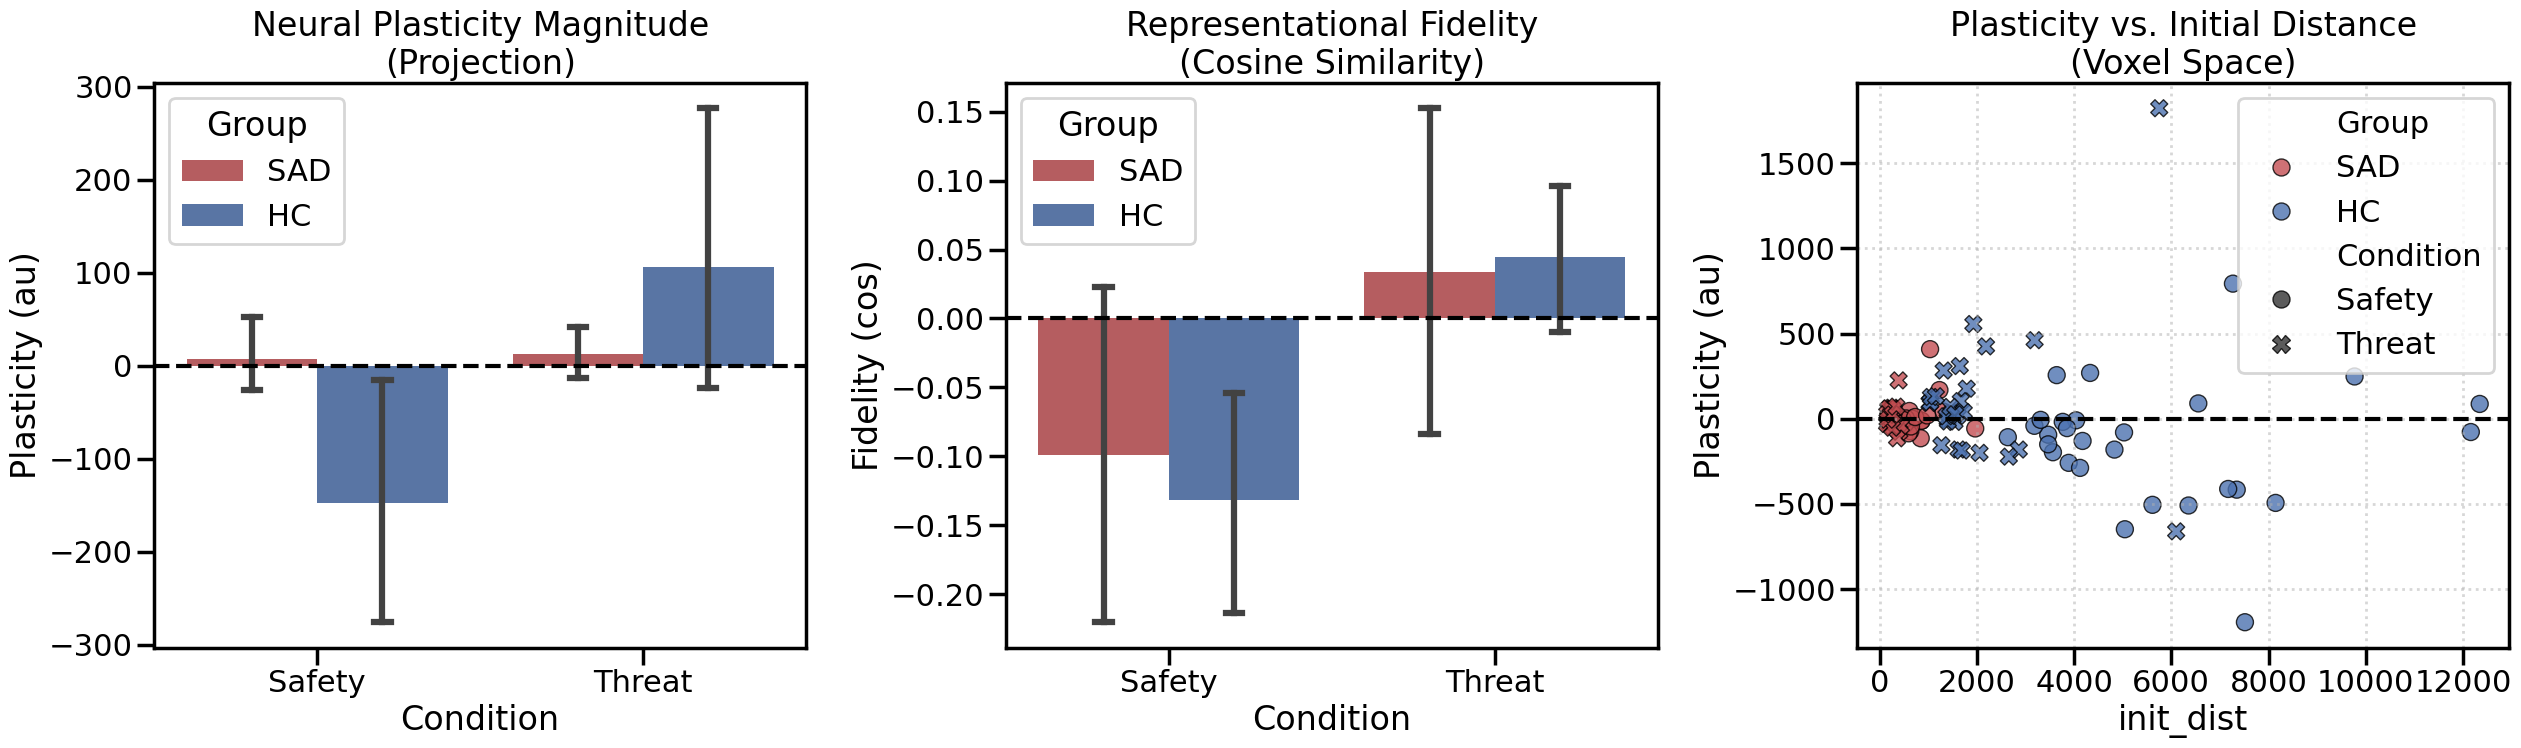

--- Cell 11 Complete: Visualization reorganized ---


In [56]:
# Cell 11: Analysis 1.3 - Dynamic Representational Drift
print("--- Running Analysis 1.3: Dynamic Representational Drift (I > 0, p < .05) ---")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import joblib
from scipy.stats import ttest_1samp, ttest_ind

# Constants
COND_SAFETY_TARGET = "CS-"
COND_SAFETY_LEARN = "CSS"
COND_THREAT_LEARN = "CSR"

# =============================================================================
# 0. CACHE GATE & DATA SETUP
# =============================================================================
# Using your requested naming convention from Cell 11
cache_cell11 = os.path.join(CHECKPOINT_DIR, "cell_11.joblib")

if os.path.exists(cache_cell11):
    print(f"  [LOAD] Found existing Drift results in {cache_cell11}. Skipping calculation...")
    results_13 = joblib.load(cache_cell11)
    df_plot = results_13["df_plot"]
else:
    print(f"\n[Step 0] Significance Mask Setup...")
    # [Internal Note: Ensure you run the Stage 9 Significance Block before this cell]
    
    # 1. Feature Selection: Prioritize the Stage 9 Empirical Mask (26 vs 1300)
    if 'importance_mask_permutated' in locals():
        importance_masks = importance_mask_permutated
    elif 'importance_masks' not in locals():
        raise ValueError("Significance masks not found. Run Cell 9 (Stage 9) first.")

    mask_sad = importance_masks['SAD']
    mask_hc = importance_masks['HC']
    print(f"  > Using Significant Voxels: SAD={np.sum(mask_sad)}, HC={np.sum(mask_hc)}")

    # 2. Load Phase Data (Beta Maps)
    X_ext_sad, y_ext_sad, sub_ext_sad = get_phase_data("SAD_Placebo", "ext")
    X_ext_hc, y_ext_hc, sub_ext_hc = get_phase_data("HC_Placebo", "ext")
    X_rst_sad, y_rst_sad, sub_rst_sad = get_phase_data("SAD_Placebo", "rst")
    X_rst_hc, y_rst_hc, sub_rst_hc = get_phase_data("HC_Placebo", "rst")

    # Safety Baseline (CS-) recovery
    if 'X_ext' in locals():
        X_global, y_global, sub_global = X_ext, y_ext, sub_ext
    else:
        print("  ! Warning: X_ext not in locals, using Extinction phase fallback.")
        X_global, y_global, sub_global = X_ext_sad, y_ext_sad, sub_ext_sad

    # =============================================================================
    # 2. Execution (Vector Plasticity Calculation)
    # =============================================================================
    # Note: Requires updated Cell 22 function definition (NameError fix)
    print("[Step 2] Computing Projection and Cosine Fidelity Vectors...")
    
    # Safety: CSS(Ext) -> CS-(Ext)
    df_safe_sad = calculate_plasticity_vectors(X_ext_sad, y_ext_sad, sub_ext_sad, X_global, y_global, sub_global, mask_sad, COND_SAFETY_LEARN, COND_SAFETY_TARGET)
    df_safe_hc = calculate_plasticity_vectors(X_ext_hc, y_ext_hc, sub_ext_hc, X_global, y_global, sub_global, mask_hc, COND_SAFETY_LEARN, COND_SAFETY_TARGET)
    # Threat: CSR(Ext) -> CSR(Rst)
    df_threat_sad = calculate_plasticity_vectors(X_ext_sad, y_ext_sad, sub_ext_sad, X_rst_sad, y_rst_sad, sub_rst_sad, mask_sad, COND_THREAT_LEARN, COND_THREAT_LEARN)
    df_threat_hc = calculate_plasticity_vectors(X_ext_hc, y_ext_hc, sub_ext_hc, X_rst_hc, y_rst_hc, sub_rst_hc, mask_hc, COND_THREAT_LEARN, COND_THREAT_LEARN)

    # Combine into unified dataset
    df_plot = pd.concat([
        tag_df(df_safe_sad, 'SAD', 'Safety'), tag_df(df_safe_hc, 'HC', 'Safety'),
        tag_df(df_threat_sad, 'SAD', 'Threat'), tag_df(df_threat_hc, 'HC', 'Threat')
    ])

    # Store for next time
    results_13 = {'df_plot': df_plot}
    joblib.dump(results_13, cache_cell11)

# =============================================================================
# 3. STATISTICS & VISUALIZATION (Updated Layout: 1 Row, 3 Columns)
# =============================================================================
if df_plot.empty:
    print("! Error: Dataframe is empty. Vector calculation likely failed.")
else:
    print(f"\n[Step 3] Analyzing {len(df_plot)} subject vectors...")
    
    sns.set_context("poster")
    # UPDATED: Changed height_ratios for 1 row, adjusted figsize
    fig, axes = plt.subplots(1, 3, figsize=(26, 8), gridspec_kw={'height_ratios': [1]})
    
    # Plot A: Magnitude (Scalar Projection)
    sns.barplot(data=df_plot, x='Condition', y='projection', hue='Group', 
                palette={'SAD': '#c44e52', 'HC': '#4c72b0'}, ax=axes[0], capsize=.1)
    axes[0].axhline(0, color='k', ls='--')
    axes[0].set_title("Neural Plasticity Magnitude\n(Projection)")
    axes[0].set_ylabel("Plasticity (au)")
    
    # Plot B: Fidelity (Cosine Similarity)
    sns.barplot(data=df_plot, x='Condition', y='cosine', hue='Group', 
                palette={'SAD': '#c44e52', 'HC': '#4c72b0'}, ax=axes[1], capsize=.1)
    axes[1].axhline(0, color='k', ls='--')
    axes[1].set_title("Representational Fidelity\n(Cosine Similarity)")
    axes[1].set_ylabel("Fidelity (cos)")
    
    # Plot C: Learning vs Initial Distance
    # This scatter plot stays in the new Row 1, Column 3 slot
    sns.scatterplot(data=df_plot, x='init_dist', y='projection', hue='Group', style='Condition', 
                    palette={'SAD': '#c44e52', 'HC': '#4c72b0'}, ax=axes[2], s=150, alpha=0.8, edgecolor='black')
    axes[2].axhline(0, color='k', ls='--')
    axes[2].set_title("Plasticity vs. Initial Distance\n(Voxel Space)")
    axes[2].set_ylabel("Plasticity (au)")
    axes[2].grid(True, linestyle=':', alpha=0.5)

    # FINAL STEP: Print Statistical Summaries (Independent of Cache)
    print("\n--- Statistical Summary (p-values) ---")
    for met in ['projection', 'cosine']:
        for cond in ['Safety', 'Threat']:
            d_s = df_plot[(df_plot['Condition']==cond) & (df_plot['Group']=='SAD')][met]
            d_h = df_plot[(df_plot['Condition']==cond) & (df_plot['Group']=='HC')][met]
            if len(d_s)>1 and len(d_h)>1:
                t, p = ttest_ind(d_s, d_h)
                sig = "*" if p < 0.05 else "ns"
                print(f"  > Group Diff: {cond} {met} t={t:.3f}, p={p:.4f} {sig}")

    plt.tight_layout()
    # Save the finalized figure to results dir
    plt.savefig(os.path.join(CHECKPOINT_DIR, "stage11_drift_plots_row.png"), dpi=300)
    plt.show()

print("--- Cell 11 Complete: Visualization reorganized ---")

--- Running Analysis 1.3 part 2: Single-Trial Trajectories (I > 0, p < .05) ---

[Step 0] Significance Mask Setup & Calculation...
  Calculating Trajectories for Safety and Threat...
  Calculating Statistics...

--- Statistics: Safety Learning ---
No significant group differences found (FDR corrected).

--- Statistics: Threat Maintenance ---
Significant Group Differences (FDR < 0.05):
 Trial    Diff_t  Diff_df   Diff_p  Diff_p_fdr
     7 -3.391182       48 0.001401    0.011208
[Checkpoint] Saved cell 12 -> /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_network/checkpoint/cell_12.joblib


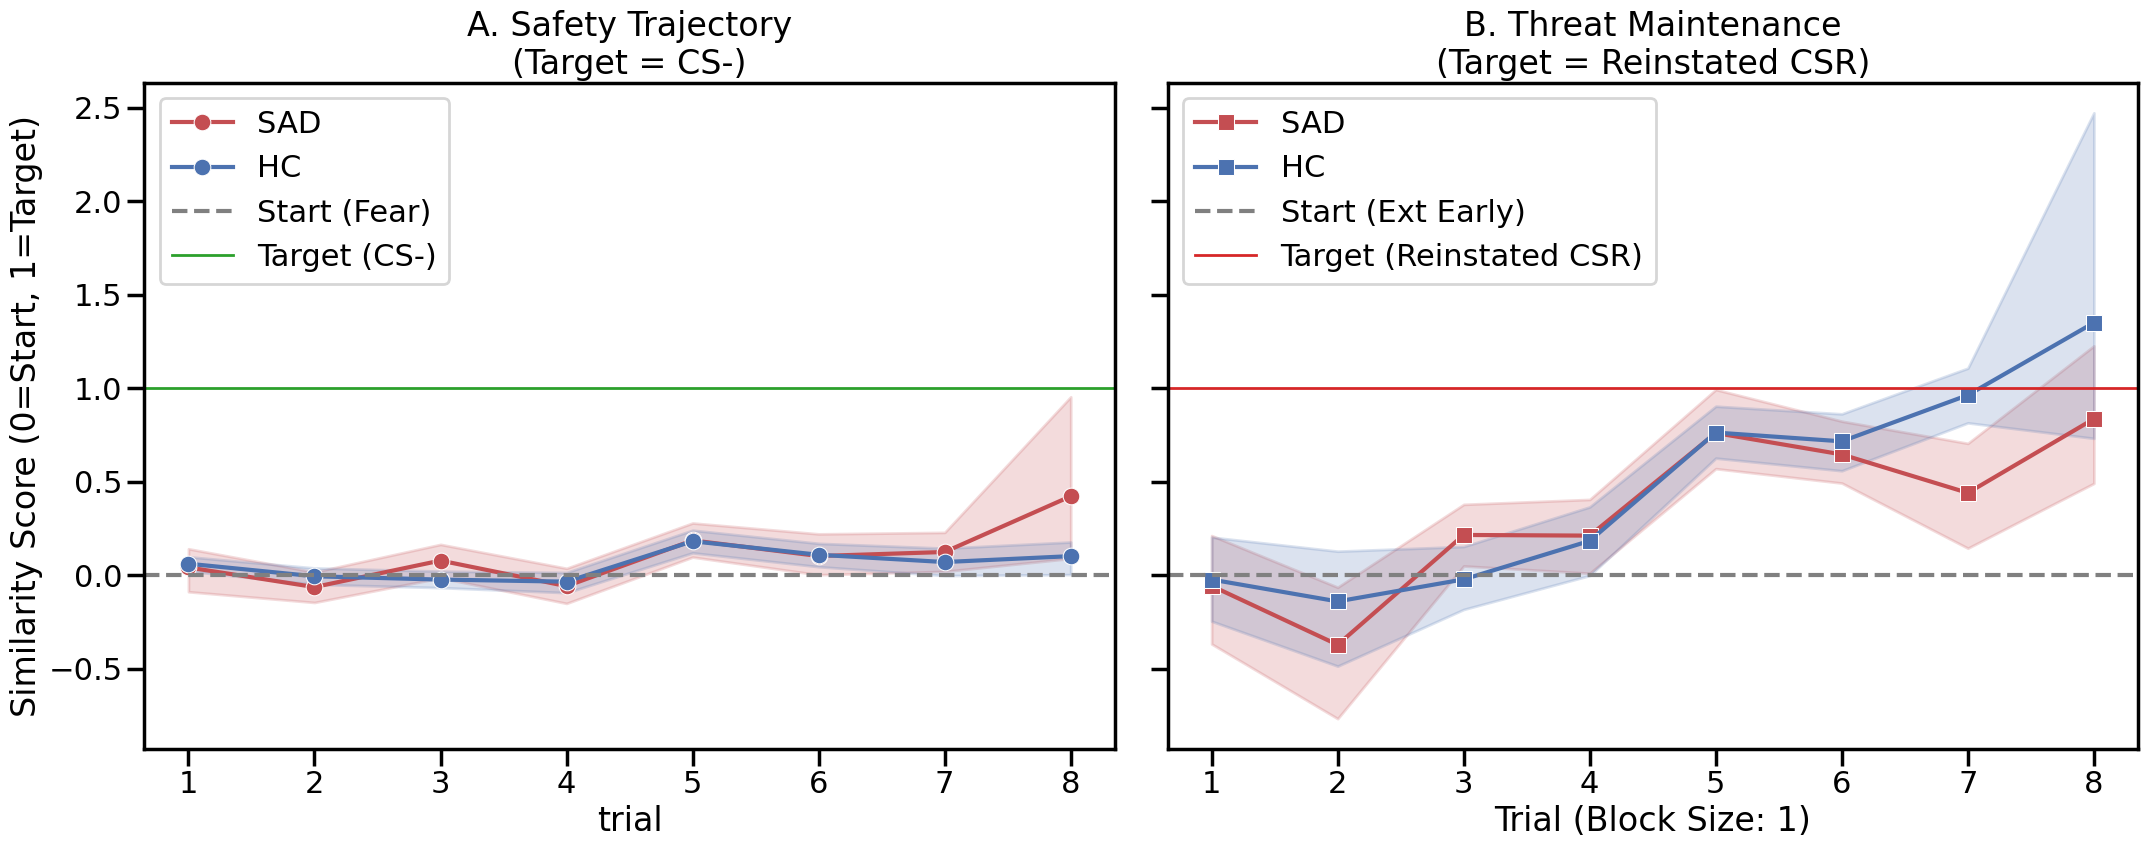

--- Cell 12 Complete: Persistent Trajectories stored ---


In [71]:
# Cell 12: Analysis 1.3 part 2 - Single-Trial Trajectories
print("--- Running Analysis 1.3 part 2: Single-Trial Trajectories (I > 0, p < .05) ---")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import joblib
from numpy.linalg import norm

# Constants
COND_SAFETY_TARGET = "CS-"
COND_SAFETY_LEARN = "CSS"
COND_THREAT_LEARN = "CSR"
BLOCK_SIZE = 1  

# =============================================================================
# 0. CACHE GATE & DATA SETUP
# =============================================================================
cache_cell12_part2 = os.path.join(CHECKPOINT_DIR, "cell_12_trajectories.joblib")

if os.path.exists(cache_cell12_part2):
    print(f"  [LOAD] Found existing Trajectory results in {cache_cell12_part2}. Skipping calculation...")
    results_13_2 = joblib.load(cache_cell12_part2)
    stats_safe = results_13_2['stats_safe']
    stats_threat = results_13_2['stats_threat']
    df_safe = results_13_2['data_safe']
    df_threat = results_13_2['data_threat']
else:
    print(f"\n[Step 0] Significance Mask Setup & Calculation...")

    # Logic: Prioritize the Stage 9 Empirical Mask
    if 'importance_mask_permutated' in locals():
        importance_masks = importance_mask_permutated
    elif 'importance_masks' not in locals():
        raise ValueError("Significance masks not found. Run Cell 9 first.")

    mask_sad = importance_masks['SAD']
    mask_hc = importance_masks['HC']

    # 1. Load Phase Data
    X_ext_sad, y_ext_sad, sub_ext_sad = get_phase_data("SAD_Placebo", "ext")
    X_ext_hc, y_ext_hc, sub_ext_hc = get_phase_data("HC_Placebo", "ext")
    X_rst_sad, y_rst_sad, sub_rst_sad = get_phase_data("SAD_Placebo", "rst")
    X_rst_hc, y_rst_hc, sub_rst_hc = get_phase_data("HC_Placebo", "rst")

    # Handle Global/CS- recovery
    if 'X_ext' in locals():
        X_glob, y_glob, sub_glob = X_ext, y_ext, sub_ext
    else:
        X_glob, y_glob, sub_glob = X_ext_sad, y_ext_sad, sub_ext_sad

    # 2. Execute Trajectory Calculations
    print("  Calculating Trajectories for Safety and Threat...")
    df_safe_sad = calc_trajectory(X_ext_sad, y_ext_sad, sub_ext_sad, X_glob, y_glob, sub_glob, mask_sad, COND_SAFETY_LEARN, COND_SAFETY_TARGET)
    df_safe_hc = calc_trajectory(X_ext_hc, y_ext_hc, sub_ext_hc, X_glob, y_glob, sub_glob, mask_hc, COND_SAFETY_LEARN, COND_SAFETY_TARGET)
    df_threat_sad = calc_trajectory(X_ext_sad, y_ext_sad, sub_ext_sad, X_rst_sad, y_rst_sad, sub_rst_sad, mask_sad, COND_THREAT_LEARN, COND_THREAT_LEARN)
    df_threat_hc = calc_trajectory(X_ext_hc, y_ext_hc, sub_ext_hc, X_rst_hc, y_rst_hc, sub_rst_hc, mask_hc, COND_THREAT_LEARN, COND_THREAT_LEARN)

    # 3. Calculate Statistics
    print("  Calculating Statistics...")
    stats_safe = run_detailed_stats(df_safe_sad, df_safe_hc, "Safety Learning")
    stats_threat = run_detailed_stats(df_threat_sad, df_threat_hc, "Threat Maintenance")

    # 4. Prepare Plotting Data
    df_safe = prepare_plot(df_safe_sad, df_safe_hc, "Safety Learning")
    df_threat = prepare_plot(df_threat_sad, df_threat_hc, "Threat Maintenance")

    # Save to Cache
    results_13_2 = {
        'stats_safe': stats_safe, 
        'stats_threat': stats_threat,
        'data_safe': df_safe,
        'data_threat': df_threat
    }
    joblib.dump(results_13_2, cache_cell12_part2)
    save_checkpoint(12, {"results_13_2": results_13_2})

# =============================================================================
# 4. VISUALIZATION (Always Runs)
# =============================================================================
if df_safe.empty and df_threat.empty:
    print("! No data to plot.")
else:
    sns.set_context("poster")
    fig, axes = plt.subplots(1, 2, figsize=(22, 9), sharey=True)
    
    # 1. Safety Plot
    if not df_safe.empty:
        sns.lineplot(data=df_safe, x='trial', y='score', hue='Group', 
                     palette={'SAD': '#c44e52', 'HC': '#4c72b0'}, 
                     lw=3, marker="o", err_style="band", ax=axes[0])
        axes[0].set_title("A. Safety Trajectory\n(Target = CS-)")
        axes[0].set_ylabel("Similarity Score (0=Start, 1=Target)")
        axes[0].axhline(0, color='gray', ls='--', label='Start (Fear)')
        axes[0].axhline(1, color='#2ca02c', ls='-', lw=2, label='Target (CS-)')
        axes[0].legend(loc='upper left')

    # 2. Threat Plot
    if not df_threat.empty:
        sns.lineplot(data=df_threat, x='trial', y='score', hue='Group', 
                     palette={'SAD': '#c44e52', 'HC': '#4c72b0'}, 
                     lw=3, marker="s", err_style="band", ax=axes[1])
        axes[1].set_title("B. Threat Maintenance\n(Target = Reinstated CSR)")
        axes[1].set_xlabel(f"Trial (Block Size: {BLOCK_SIZE})")
        axes[1].axhline(0, color='gray', ls='--', label='Start (Ext Early)')
        axes[1].axhline(1, color='#d62728', ls='-', lw=2, label='Target (Reinstated CSR)')
        axes[1].legend(loc='upper left')
    
    plt.tight_layout()
    # Save high-res figure to global results
    plt.savefig(os.path.join(CHECKPOINT_DIR, "stage12_trajectories_plot.png"), dpi=300)
    plt.show()

print("--- Cell 12 Complete: Persistent Trajectories stored ---")

--- Running Analysis 1.4: Self-Network Statistics (Optimized C) ---
  [LOAD] Found existing optimized results in /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_network/checkpoint/cell_13_decision_stats_opt.joblib.

  STATISTICAL SUMMARY: SAD vs HC
  Entropy (Uncertainty): t = -1.7156, p = 0.0926
  Kurtosis (Sharpness):  t = -0.1021, p = 0.9191
  KS Test (Distribution): D = 0.0693, p = 0.2706



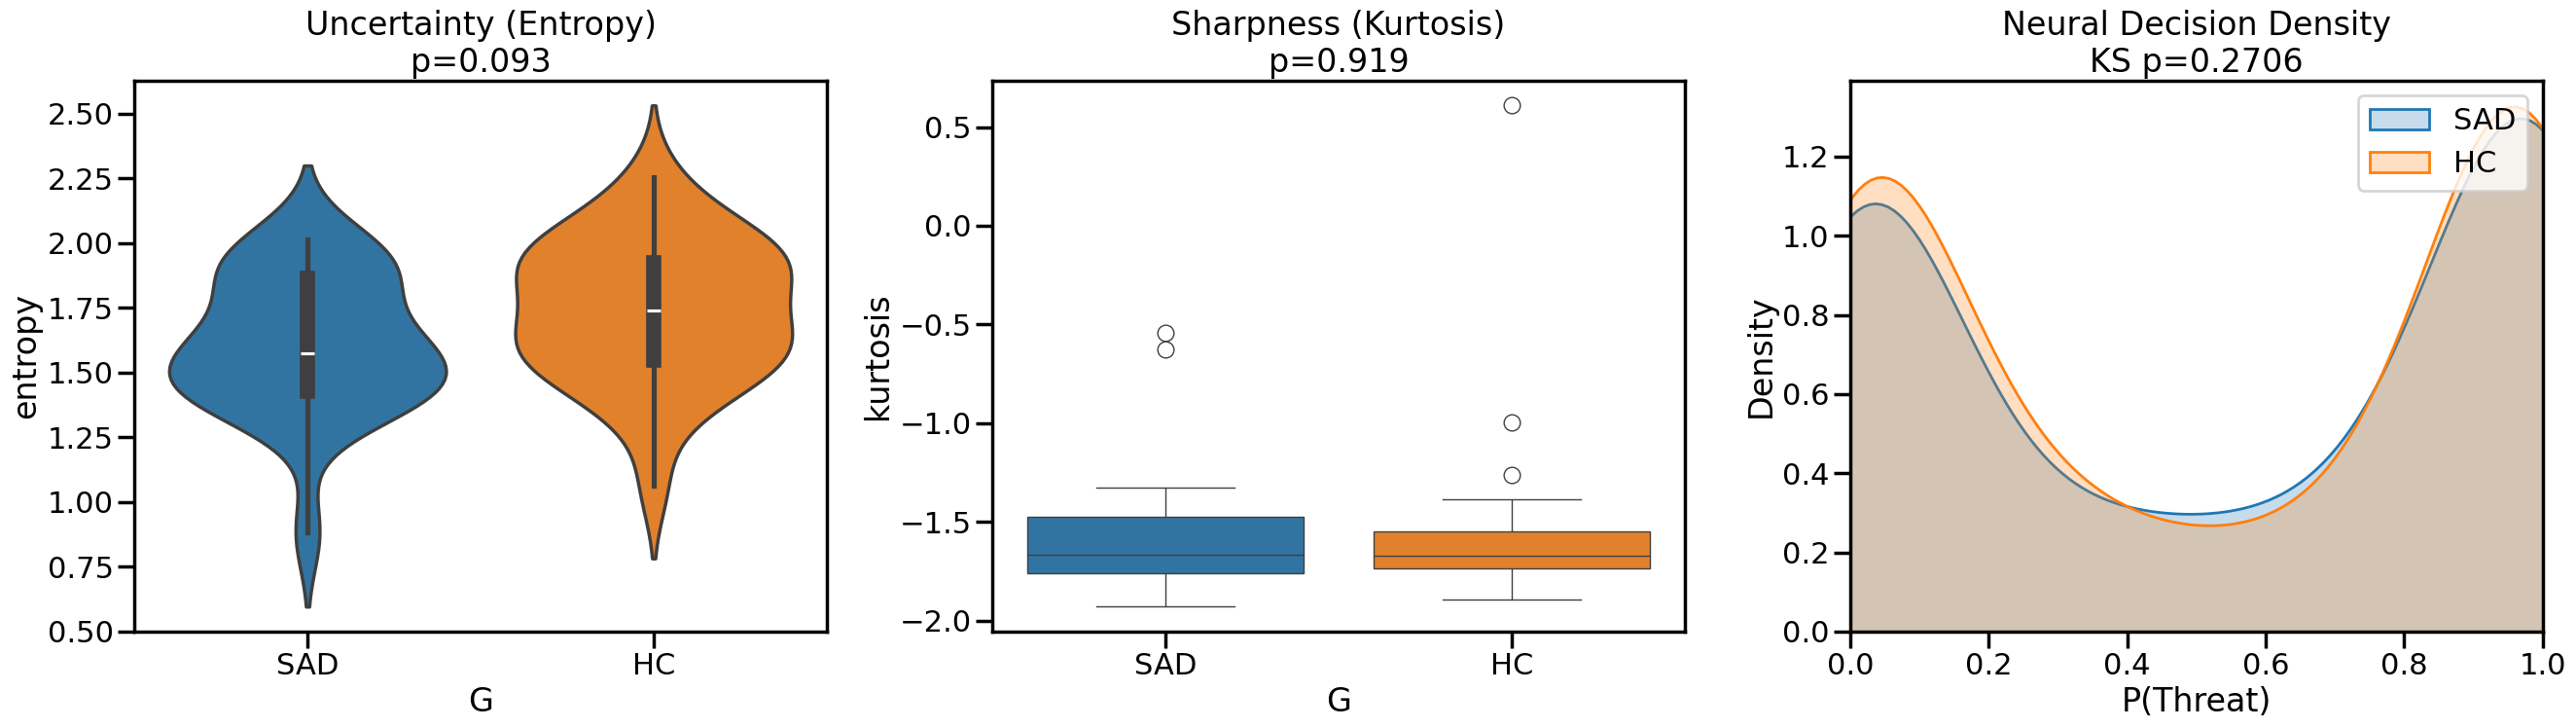

--- Cell 13 Complete ---


In [35]:
# Cell 13: Analysis 1.4 - Decision Boundary Characteristics
print("--- Running Analysis 1.4: Self-Network Statistics (Optimized C) ---")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import joblib
from scipy.stats import entropy, kurtosis, ttest_ind, ks_2samp

# =============================================================================
# 0. CACHE GATE
# =============================================================================
cache_cell13 = os.path.join(CHECKPOINT_DIR, "cell_13_decision_stats_opt.joblib")

if os.path.exists(cache_cell13): 
    print(f"  [LOAD] Found existing optimized results in {cache_cell13}.")
    results_14_self = joblib.load(cache_cell13)
    df_sad_stats = results_14_self['df_sad']
    df_hc_stats = results_14_self['df_hc']
else:
    print(f"  [CALC] Calculating Decision Stats using Optimized C...")
    # Retrieve optimized C from your Cell 6 results
    c_sad = res_sad['model_sad'].named_steps['classification'].C
    c_hc = res_hc['model_hc'].named_steps['classification'].C

    def get_stats_calibrated(data_ptr, mask, opt_c):
        from sklearn.linear_model import LogisticRegression
        from sklearn.model_selection import LeaveOneGroupOut
        
        X, y, subs = data_ptr["X"], data_ptr["y"], data_ptr["sub"]
        u_subs = np.unique(subs)
        rows = []
        
        for sub in u_subs:
            m = (subs == sub) & np.isin(y, ["CSR", "CSS"])
            if np.sum(m) < 8: continue
            
            xs, ys = X[m][:, mask], y[m]
            # Leave-One-Trial-Out ensures we don't overfit to the test trial
            logo = LeaveOneGroupOut()
            probs = []
            
            for train, test in logo.split(xs, ys, groups=np.arange(len(ys))):
                clf = LogisticRegression(C=opt_c, solver='liblinear', random_state=42)
                clf.fit(xs[train], ys[train])
                
                csr_idx = np.where(clf.classes_ == "CSR")[0][0]
                probs.append(clf.predict_proba(xs[test])[0, csr_idx])
            
            probs = np.array(probs)
            # 20-bin histogram for Shannon Entropy
            hist, _ = np.histogram(probs, bins=20, range=(0, 1), density=True)
            ent_val = entropy(hist + 1e-9)
            kurt_val = kurtosis(probs, fisher=True)
            
            rows.append({'sub': sub, 'entropy': ent_val, 'kurtosis': kurt_val, 'probabilities': probs})
        return pd.DataFrame(rows)

    df_sad_stats = get_stats_calibrated(data_subsets["SAD_Placebo"]["ext"], importance_mask_permutated['SAD'], c_sad)
    df_hc_stats = get_stats_calibrated(data_subsets["HC_Placebo"]["ext"], importance_mask_permutated['HC'], c_hc)

    results_14_self = {'df_sad': df_sad_stats, 'df_hc': df_hc_stats}
    joblib.dump(results_14_self, cache_cell13)

# =============================================================================
# 4. STATISTICS & VISUALIZATION
# =============================================================================
# A. Metric Tests (Subject-wise)
t_ent, p_ent = ttest_ind(df_sad_stats['entropy'], df_hc_stats['entropy'])
t_kurt, p_kurt = ttest_ind(df_sad_stats['kurtosis'], df_hc_stats['kurtosis'])

# B. Distribution Test (Trial-wise KS Test)
all_p_sad = np.concatenate([p for p in df_sad_stats['probabilities'].values if len(p) > 0])
all_p_hc = np.concatenate([p for p in df_hc_stats['probabilities'].values if len(p) > 0])
ks_stat, p_ks = ks_2samp(all_p_sad, all_p_hc)

print("\n" + "="*45)
print("  STATISTICAL SUMMARY: SAD vs HC")
print("="*45)
print(f"  Entropy (Uncertainty): t = {t_ent:.4f}, p = {p_ent:.4f}")
print(f"  Kurtosis (Sharpness):  t = {t_kurt:.4f}, p = {p_kurt:.4f}")
print(f"  KS Test (Distribution): D = {ks_stat:.4f}, p = {p_ks:.4f}")
print("="*45 + "\n")

sns.set_context("poster")
fig, axes = plt.subplots(1, 3, figsize=(27, 8))
df_plot = pd.concat([df_sad_stats.assign(G='SAD'), df_hc_stats.assign(G='HC')])

# Panel 1: Entropy
sns.violinplot(data=df_plot, x='G', y='entropy', hue='G', legend=False, ax=axes[0])
axes[0].set_title(f"Uncertainty (Entropy)\np={p_ent:.3f}")

# Panel 2: Kurtosis
sns.boxplot(data=df_plot, x='G', y='kurtosis', hue='G', legend=False, ax=axes[1])
axes[1].set_title(f"Sharpness (Kurtosis)\np={p_kurt:.3f}")

# Panel 3: Probability Density
sns.kdeplot(all_p_sad, fill=True, label='SAD', ax=axes[2], bw_adjust=1.0)
sns.kdeplot(all_p_hc, fill=True, label='HC', ax=axes[2], bw_adjust=1.0)
axes[2].set_title(f"Neural Decision Density\nKS p={p_ks:.4f}")
axes[2].set_xlabel("P(Threat)")
axes[2].set_xlim(0, 1)
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "stage13_decision_final_stats.png"), dpi=300)
plt.show()

print("--- Cell 13 Complete ---")

--- Running Analysis 2.1: Safety Restoration & Threat Discrimination (LME | Per-Voxel Normalized) ---
  > Normalizing by Voxel Counts: SAD=26, HC=867
  > Calculating Per-Voxel (PV) Metrics...
  > Computed PV metrics for 102 subjects.

[Step 2] Testing for Interaction (Mixed Effects on PV Metrics)...

--- Metric 1: Safety Restoration (PV) ---
                                                  Mixed Linear Model Regression Results
Model:                                       MixedLM                          Dependent Variable:                          Dist_Safety_PV
No. Observations:                            102                              Method:                                      REML          
No. Groups:                                  102                              Scale:                                       0.0000        
Min. group size:                             1                                Log-Likelihood:                              481.4316      
Max. group size:

/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


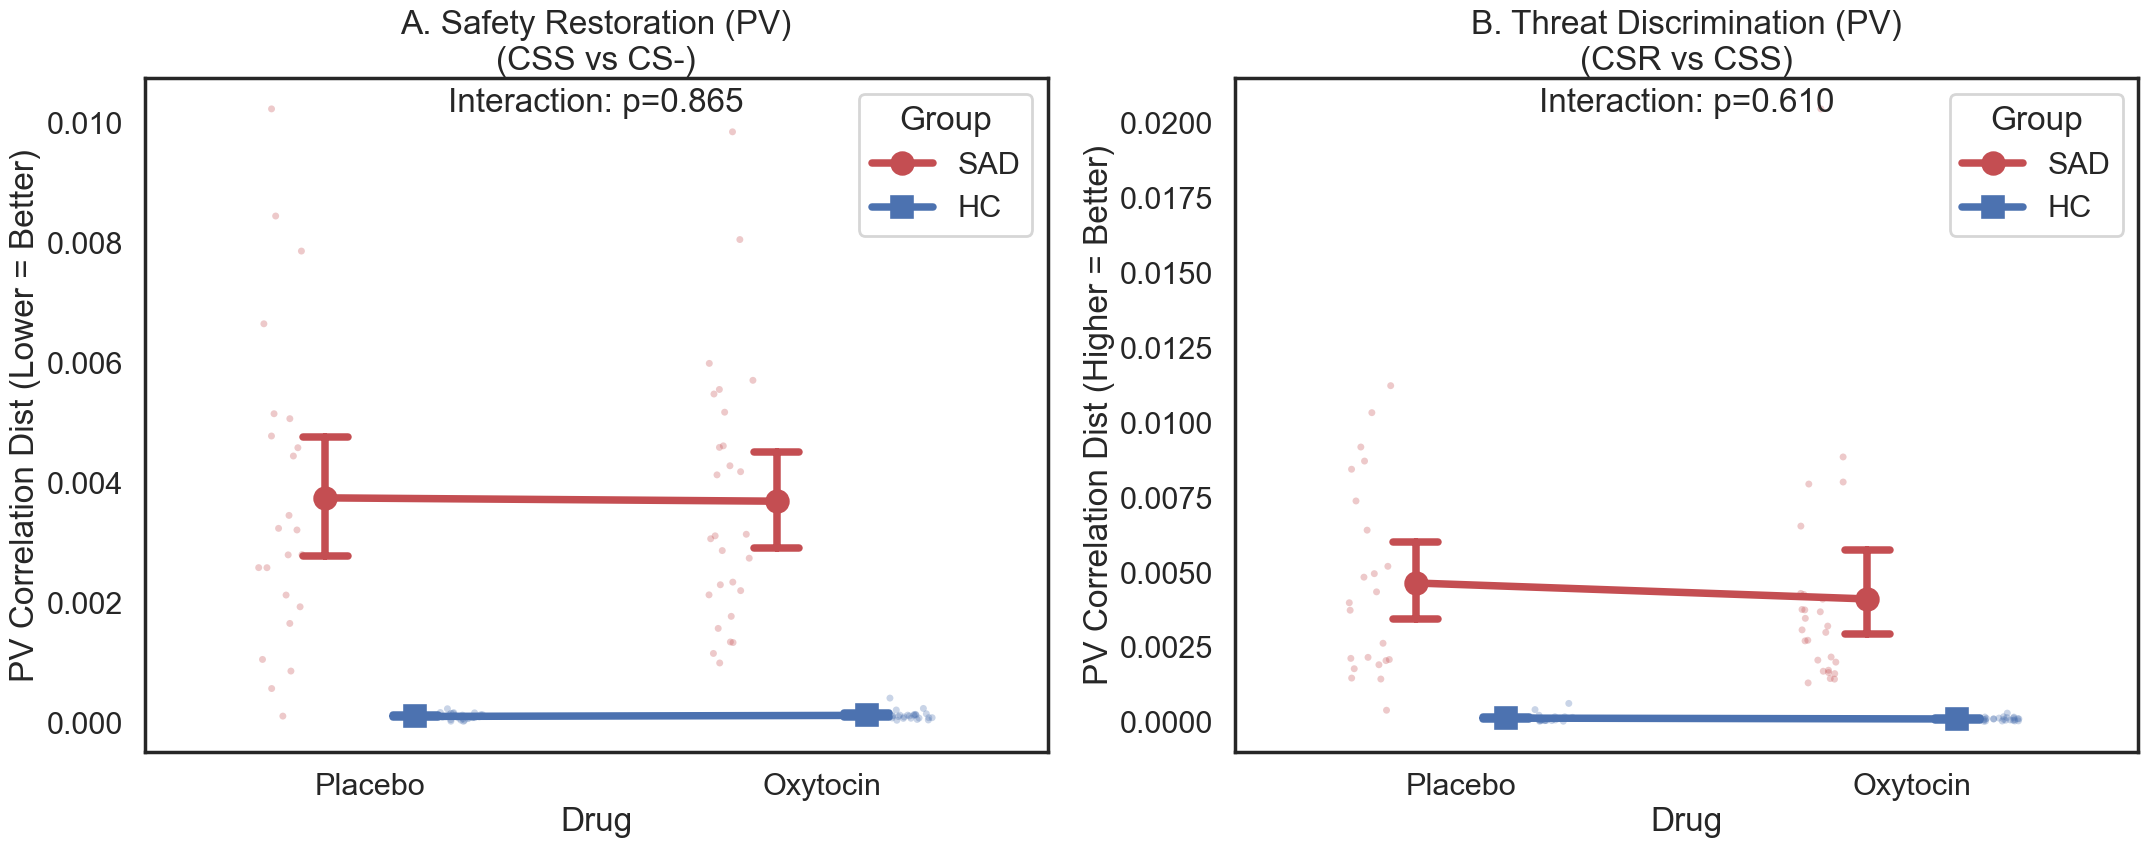

In [185]:
# Cell 14: Analysis 2.1 - Safety Restoration & Threat Discrimination (Mixed Effects - PV Normalized)
# Objective: Test if Oxytocin rescues network topology in SAD using Per-Voxel normalization.

print("--- Running Analysis 2.1: Safety Restoration & Threat Discrimination (LME | Per-Voxel Normalized) ---")

# Constants
COND_SAFE_LEARN = "CSS"
COND_SAFE_BASE  = "CS-"
COND_THREAT     = "CSR"

# =============================================================================
# 0. Validate Masks & Constants from Cell 9/10
# =============================================================================
if 'importance_mask_permutated' not in locals():
    raise ValueError("Importance masks not found! Please run Cell 9 first.")

mask_sad = importance_mask_permutated['SAD']
mask_hc = importance_mask_permutated['HC']

# Get voxel counts for Per-Voxel (PV) normalization
n_vox_sad = np.sum(mask_sad)
n_vox_hc = np.sum(mask_hc)

print(f"  > Normalizing by Voxel Counts: SAD={n_vox_sad}, HC={n_vox_hc}")

# =============================================================================
# 1. Calculate PV-Normalized Distances
# =============================================================================
subgroups_21 = {"SAD_Placebo": [], "SAD_Oxytocin": [], "HC_Placebo": [], "HC_Oxytocin": []}

if 'sub_to_meta' not in locals():
    if 'meta' in locals():
        sub_to_meta = meta.set_index("subject_id")[["Group", "Drug"]].to_dict('index')
    else:
        raise ValueError("Metadata not found.")

for sub in np.unique(sub_ext):
    s_str = str(sub).strip()
    # Handle various subject string formats
    info = sub_to_meta.get(s_str) or sub_to_meta.get(f"sub-{s_str}")
    if not info: continue

    key = f"{info['Group']}_{info['Drug']}"
    if key in subgroups_21: subgroups_21[key].append(sub)

data_rows = []
print("  > Calculating Per-Voxel (PV) Metrics...")

for key, subject_list in subgroups_21.items():
    group, drug = key.split('_')
    
    # Select Native Mask and PV Scale Factor
    current_mask = mask_sad if group == "SAD" else mask_hc
    n_feat = n_vox_sad if group == "SAD" else n_vox_hc
        
    for sub in subject_list:
        mask_sub = (sub_ext == sub)
        if not np.any(mask_sub): continue
        
        X_sub = X_ext[mask_sub][:, current_mask]
        y_sub = y_ext[mask_sub]
        
        # Extract Prototypes (Centroids)
        idx_css = (y_sub == COND_SAFE_LEARN)
        idx_cs_ = (y_sub == COND_SAFE_BASE)
        idx_csr = (y_sub == COND_THREAT)
        
        # Requirement: At least 1 trial per condition for centroid calculation
        if not (np.any(idx_css) and np.any(idx_cs_) and np.any(idx_csr)): continue
        
        p_css = np.mean(X_sub[idx_css], axis=0).reshape(1, -1)
        p_cs_ = np.mean(X_sub[idx_cs_], axis=0).reshape(1, -1)
        p_csr = np.mean(X_sub[idx_csr], axis=0).reshape(1, -1)
        
        # 1. Calculate Raw Correlation Distance
        raw_dist_safety = cdist(p_css, p_cs_, metric='correlation')[0][0]
        raw_dist_threat = cdist(p_csr, p_css, metric='correlation')[0][0]
        
        # 2. PV Normalization (Metric / Number of Voxels)
        # This matches the logic used in Cell 10 for static topology
        pv_dist_safety = raw_dist_safety / n_feat
        pv_dist_threat = raw_dist_threat / n_feat
            
        data_rows.append({
            "Subject": sub, "Group": group, "Drug": drug, "Condition": key,
            "Dist_Safety_PV": pv_dist_safety,
            "Dist_Threat_PV": pv_dist_threat
        })

df_topo_pv = pd.DataFrame(data_rows)
print(f"  > Computed PV metrics for {len(df_topo_pv)} subjects.")

# =============================================================================
# 2. Statistical Tests (Linear Mixed Effects)
# =============================================================================
print("\n[Step 2] Testing for Interaction (Mixed Effects on PV Metrics)...")
form_base = "~ C(Group, Treatment(reference='HC')) * C(Drug, Treatment(reference='Placebo'))"

# Test 1: Safety Restoration (PV)
p_int_safe = run_lme("Dist_Safety_PV " + form_base, df_topo_pv, "Metric 1: Safety Restoration (PV)")

# Test 2: Threat Discrimination (PV)
p_int_threat = run_lme("Dist_Threat_PV " + form_base, df_topo_pv, "Metric 2: Threat Discrimination (PV)")

# =============================================================================
# 3. Visualization
# =============================================================================
sns.set_context("poster")
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
pal_group = {'SAD': '#c44e52', 'HC': '#4c72b0'}

# Plotting Function to keep code clean
def plot_pv_metric(ax, y_col, title, ylabel, p_val):
    sns.pointplot(data=df_topo_pv, x='Drug', y=y_col, hue='Group', 
                  palette=pal_group, order=['Placebo', 'Oxytocin'], hue_order=['SAD', 'HC'],
                  dodge=0.2, markers=['o', 's'], capsize=0.1, ax=ax)
    sns.stripplot(data=df_topo_pv, x='Drug', y=y_col, hue='Group', 
                  palette=pal_group, order=['Placebo', 'Oxytocin'], hue_order=['SAD', 'HC'],
                  dodge=True, alpha=0.3, jitter=True, legend=False, ax=ax)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    if p_val < 0.05:
        ax.text(0.5, 0.95, f"Interaction: p={p_val:.3f}*", transform=ax.transAxes, ha='center', color='red', fontweight='bold')
    else:
        ax.text(0.5, 0.95, f"Interaction: p={p_val:.3f}", transform=ax.transAxes, ha='center')

plot_pv_metric(axes[0], 'Dist_Safety_PV', "A. Safety Restoration (PV)\n(CSS vs CS-)", "PV Correlation Dist (Lower = Better)", p_int_safe)
plot_pv_metric(axes[1], 'Dist_Threat_PV', "B. Threat Discrimination (PV)\n(CSR vs CSS)", "PV Correlation Dist (Higher = Better)", p_int_threat)

plt.tight_layout()
plt.show()

results_21_pv = {'df': df_topo_pv, 'p_safe': p_int_safe, 'p_threat': p_int_threat}

--- Running Analysis 2.1: Safety Restoration & Threat Discrimination (LME) ---
  > Calculating distances (Metric A & Metric B)...
  > Computed metrics for 102 subjects.

[Step 2] Testing for Interaction (Mixed Effects)...

--- Metric 1: Safety Restoration (CSS - CS-) ---
                                                  Mixed Linear Model Regression Results
Model:                                        MixedLM                           Dependent Variable:                           Dist_Safety
No. Observations:                             102                               Method:                                       REML       
No. Groups:                                   102                               Scale:                                        0.0017     
Min. group size:                              1                                 Log-Likelihood:                               132.7120   
Max. group size:                              1                                 Converge

/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


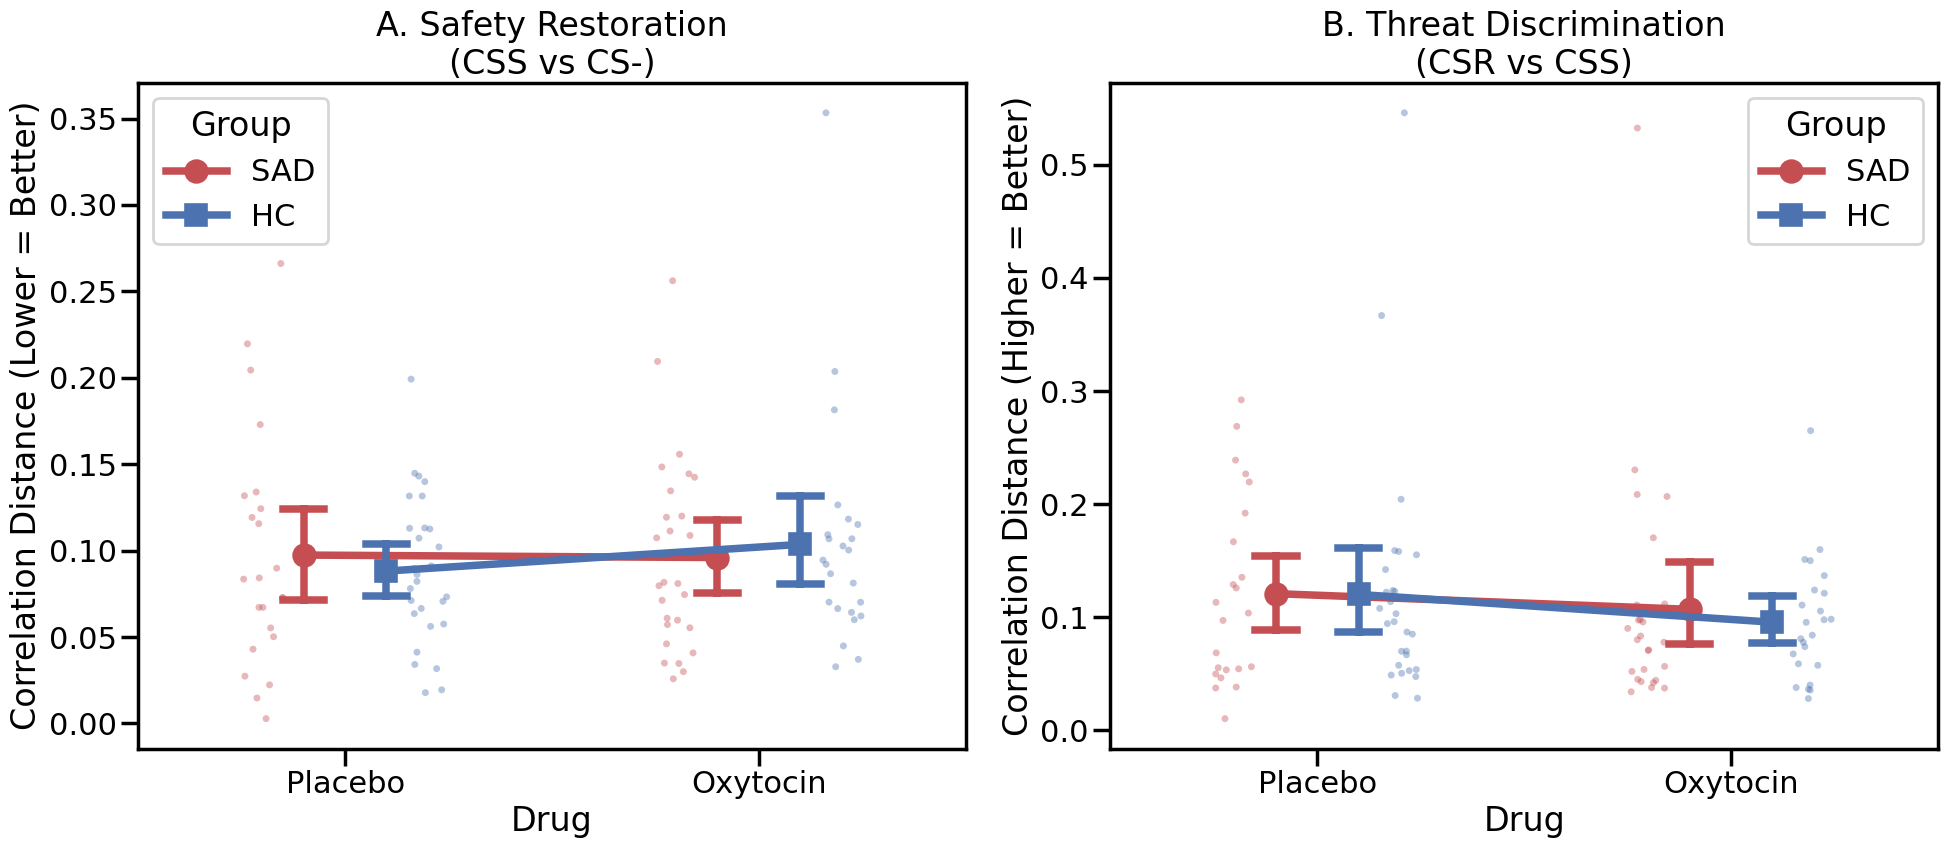

In [ ]:
# Cell 14: Analysis 2.1 - Safety Restoration & Threat Discrimination (Mixed Effects)
# Objective: Test if Oxytocin rescues network topology in SAD.
# Metrics:
#   1. Safety Restoration: Dist(CSS, CS-) -> Should DECREASE (Return to baseline).
#   2. Threat Discrimination: Dist(CSR, CSS) -> Should INCREASE (Better separation).
# Statistical Model: Linear Mixed Effects (LME)
#   Formula: Metric ~ Group * Drug
#   Random Effect: 1 | Subject (Implicitly handles variance if repeated measures exist)

print("--- Running Analysis 2.1: Safety Restoration & Threat Discrimination (LME) ---")

# Constants
COND_SAFE_LEARN = "CSS"
COND_SAFE_BASE  = "CS-"
COND_THREAT     = "CSR"

# =============================================================================
# 0. Validate Masks from Cell 9
# =============================================================================
if 'mask_sad_top5' not in locals() or 'mask_hc_top5' not in locals():
    raise ValueError("Top 5% Masks not found! Please run Cell 9 first.")

# =============================================================================
# 1. Calculate Distances (Both Metrics)
# =============================================================================
subgroups_21 = {"SAD_Placebo": [], "SAD_Oxytocin": [], "HC_Placebo": [], "HC_Oxytocin": []}

# Link subjects to groups
if 'sub_to_meta' not in locals():
    if 'meta' in locals():
        sub_to_meta = meta.set_index("subject_id")[["Group", "Drug"]].to_dict('index')
    else:
        raise ValueError("Metadata not found.")

for sub in np.unique(sub_ext):
    s_str = str(sub).strip()
    if s_str in sub_to_meta: info = sub_to_meta[s_str]
    elif f"sub-{s_str}" in sub_to_meta: info = sub_to_meta[f"sub-{s_str}"]
    else: continue

    key = f"{info['Group']}_{info['Drug']}"
    if key in subgroups_21: subgroups_21[key].append(sub)

data_rows = []
print("  > Calculating distances (Metric A & Metric B)...")

for key, subject_list in subgroups_21.items():
    group, drug = key.split('_')
    
    # Select Native Mask
    current_mask = mask_sad_top5 if group == "SAD" else mask_hc_top5
        
    for sub in subject_list:
        mask_sub = (sub_ext == sub)
        X_sub = X_ext[mask_sub]
        y_sub = y_ext[mask_sub]
        
        # Apply Mask & Center
        X_masked = X_sub[:, current_mask]
        
        # Extract Prototypes
        idx_css = (y_sub == COND_SAFE_LEARN)
        idx_cs_ = (y_sub == COND_SAFE_BASE)
        idx_csr = (y_sub == COND_THREAT)
        
        if np.sum(idx_css) < 3 or np.sum(idx_cs_) < 3 or np.sum(idx_csr) < 3: continue
        
        p_css = np.mean(X_masked[idx_css], axis=0).reshape(1, -1)
        p_cs_ = np.mean(X_masked[idx_cs_], axis=0).reshape(1, -1)
        p_csr = np.mean(X_masked[idx_csr], axis=0).reshape(1, -1)
        
        # Metric 1: Safety Restoration (CSS vs CS-)
        dist_safety = cdist(p_css, p_cs_, metric='correlation')[0][0]
        
        # Metric 2: Threat Discrimination (CSR vs CSS)
        dist_threat = cdist(p_csr, p_css, metric='correlation')[0][0]
            
        data_rows.append({
            "Subject": sub, "Group": group, "Drug": drug, "Condition": key,
            "Dist_Safety": dist_safety,
            "Dist_Threat": dist_threat
        })

df_topo = pd.DataFrame(data_rows)
print(f"  > Computed metrics for {len(df_topo)} subjects.")

# =============================================================================
# 2. Statistical Tests (Linear Mixed Effects)
# =============================================================================
print("\n[Step 2] Testing for Interaction (Mixed Effects)...")
# Formula: Metric ~ Group * Drug
# We set references explicitly: Group=HC, Drug=Placebo
form_base = "~ C(Group, Treatment(reference='HC')) * C(Drug, Treatment(reference='Placebo'))"

# Test 1: Safety Restoration
p_int_safe = run_lme("Dist_Safety " + form_base, df_topo, "Metric 1: Safety Restoration (CSS - CS-)")

# Test 2: Threat Discrimination
p_int_threat = run_lme("Dist_Threat " + form_base, df_topo, "Metric 2: Threat Discrimination (CSR - CSS)")

# =============================================================================
# 3. Visualization
# =============================================================================
sns.set_context("poster")
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
pal_group = {'SAD': '#c44e52', 'HC': '#4c72b0'}

# Plot A: Safety Restoration
sns.pointplot(data=df_topo, x='Drug', y='Dist_Safety', hue='Group', 
              palette=pal_group, order=['Placebo', 'Oxytocin'], hue_order=['SAD', 'HC'],
              dodge=0.2, markers=['o', 's'], capsize=0.1, ax=axes[0])
sns.stripplot(data=df_topo, x='Drug', y='Dist_Safety', hue='Group', 
              palette=pal_group, order=['Placebo', 'Oxytocin'], hue_order=['SAD', 'HC'],
              dodge=True, alpha=0.4, jitter=True, legend=False, ax=axes[0])

axes[0].set_title("A. Safety Restoration\n(CSS vs CS-)")
axes[0].set_ylabel("Correlation Distance (Lower = Better)")
if p_int_safe < 0.05:
    axes[0].text(0.5, 0.95, f"Interaction: p={p_int_safe:.3f}", transform=axes[0].transAxes, ha='center', fontweight='bold')

# Plot B: Threat Discrimination
sns.pointplot(data=df_topo, x='Drug', y='Dist_Threat', hue='Group', 
              palette=pal_group, order=['Placebo', 'Oxytocin'], hue_order=['SAD', 'HC'],
              dodge=0.2, markers=['o', 's'], capsize=0.1, ax=axes[1])
sns.stripplot(data=df_topo, x='Drug', y='Dist_Threat', hue='Group', 
              palette=pal_group, order=['Placebo', 'Oxytocin'], hue_order=['SAD', 'HC'],
              dodge=True, alpha=0.4, jitter=True, legend=False, ax=axes[1])

axes[1].set_title("B. Threat Discrimination\n(CSR vs CSS)")
axes[1].set_ylabel("Correlation Distance (Higher = Better)")
if p_int_threat < 0.05:
    axes[1].text(0.5, 0.95, f"Interaction: p={p_int_threat:.3f}", transform=axes[1].transAxes, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

results_21 = {'df': df_topo, 'p_safe': p_int_safe, 'p_threat': p_int_threat}

--- Running Analysis 2.2: Drift Efficiency (Means ± SEM) ---

[Step 0] Setup & Data Loading...
  > Computed vectors for 102 subjects.

[Step 2] Statistical Testing (LME)...

--- Domain: Safety ---
  > Cosine: Interaction p=0.6824 
  > Projection: Interaction p=0.3358 

--- Domain: Threat ---
  > Cosine: Interaction p=0.9900 
  > Projection: Interaction p=0.5425 


/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/var/folders/63/3j_hstl9

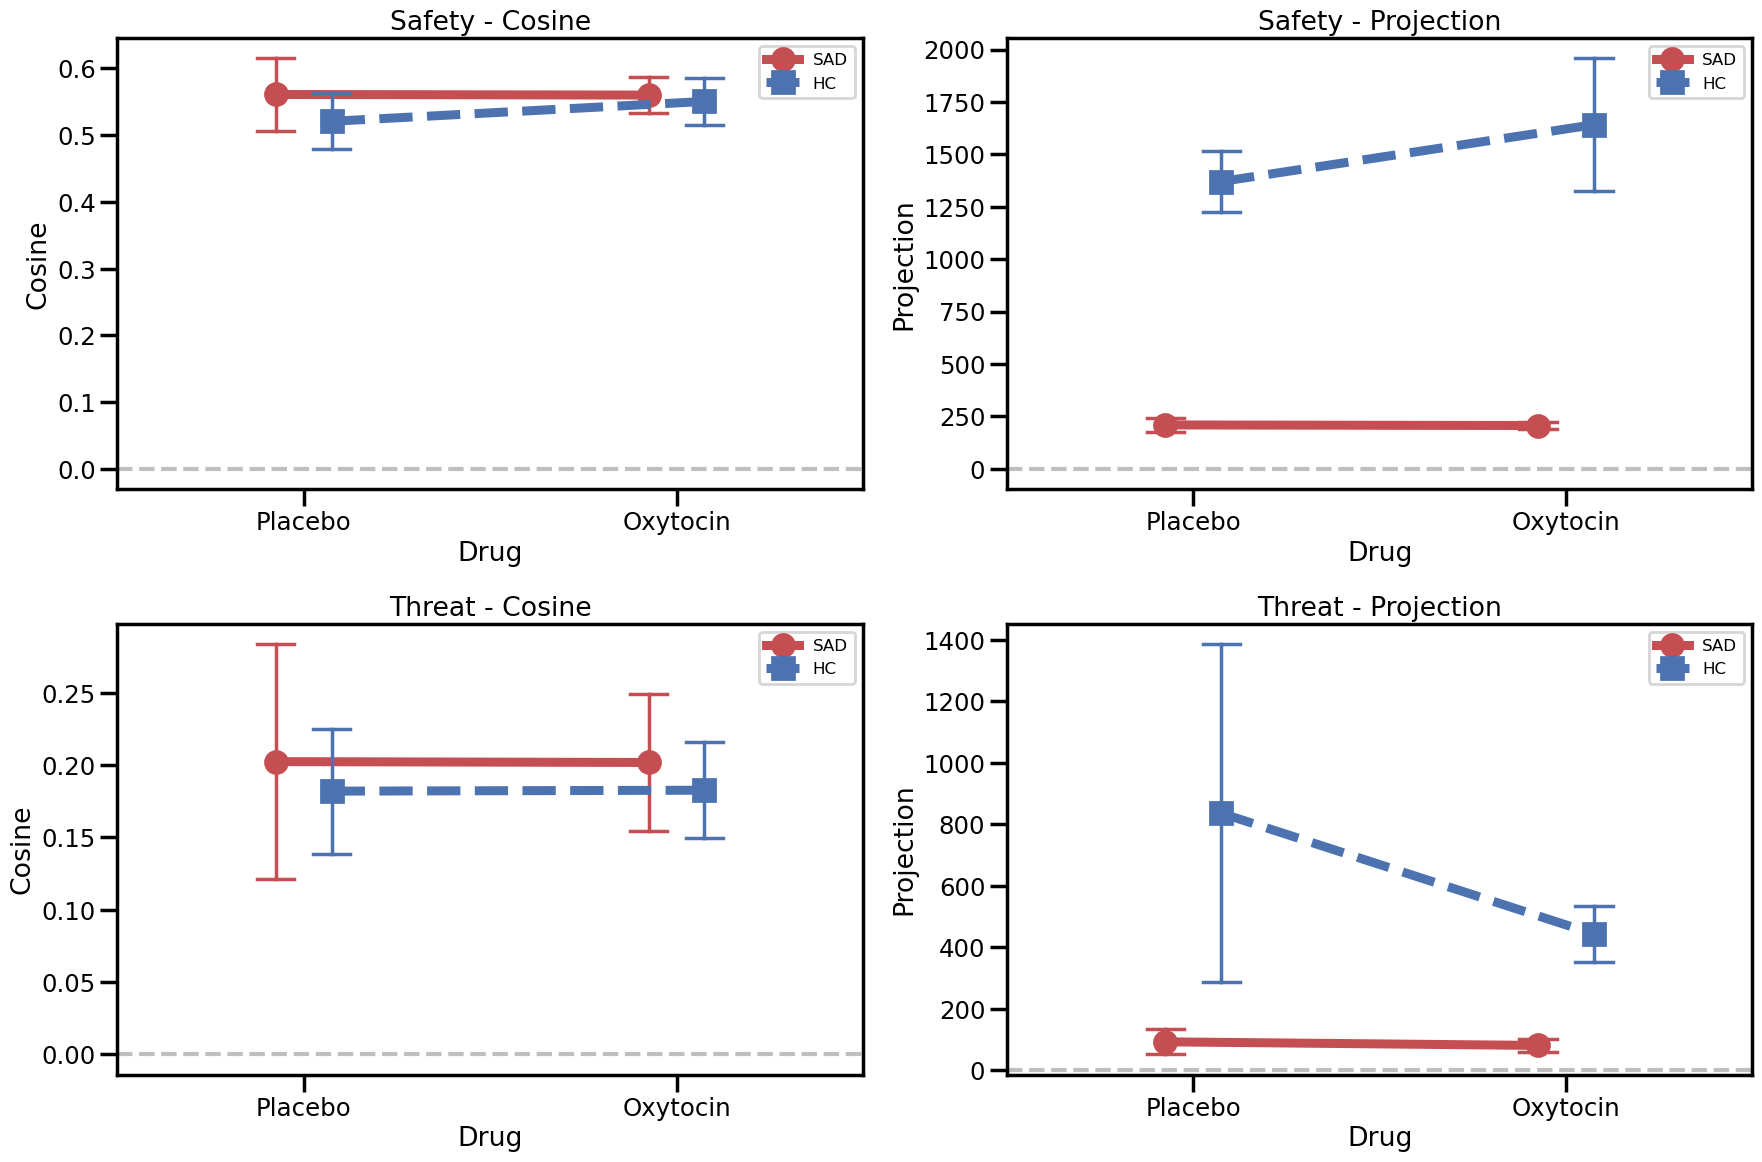

Note: Error bars represent Standard Error of the Mean (SEM).


In [ ]:
# Cell 15: Analysis 2.2 - Drift Efficiency (Safety & Threat Maintenance)
# Objective: Test OXT effect on neural drift efficiency in the Core Top 5% Network.
# Domains:
#   1. Safety Learning:    CSS(Ext) -> CS-(Ext)
#   2. Threat Maintenance: CSR(Ext) -> CSR(Reinst)
# Stats: Linear Mixed Effects (LME)
# Visualization: Line plots (Means ± SEM)

print("--- Running Analysis 2.2: Drift Efficiency (Means ± SEM) ---")

# Constants
COND_SAFE_TGT = "CS-"
COND_SAFE_LRN = "CSS"
COND_THREAT_LRN = "CSR"
PERCENTILE_THRESH = 95  # Top 5%

# =============================================================================
# 0. Setup: Masks & Data Loading
# =============================================================================
print(f"\n[Step 0] Setup & Data Loading...")

# Reinstatement data source from Cell 5 (X_rein/y_rein/sub_rein)
if 'X_rein' not in locals() or X_rein is None:
    raise ValueError("Reinstatement data missing (X_rein). Run Cell 5.")
X_rst_all = X_rein
y_rst_all = y_rein
sub_rst_all = sub_rein

# Ensure core masks exist
if 'mask_sad_core' not in locals() or 'mask_hc_core' not in locals():
    if 'importance_masks' in locals():
        mask_sad_core = importance_masks['SAD']
        mask_hc_core = importance_masks['HC']
    else:
        raise ValueError("Core masks not found. Run Analysis 1.1 / Cell 9 first.")

# Build subject lists if missing
if 'subgroups_22' not in locals():
    subgroups_22 = {}
    for key, d in data_subsets.items():
        if d is None or 'ext' not in d or d['ext'] is None:
            continue
        subgroups_22[key] = np.unique(d['ext']['sub'])

# Container for outputs

# Reinstatement data (global) fallback
data_rows = []

if 'importance_masks' not in locals():
    raise ValueError("Top 5% masks not found. Run Analysis 1.1 / Cell 9 first.")


for key, subject_list in subgroups_22.items():
    group, drug = key.split('_')
    curr_mask = mask_sad_core if group == "SAD" else mask_hc_core
    
    for sub in subject_list:
        m_ext = (sub_ext == sub)
        X_e, y_e = X_ext[m_ext], y_ext[m_ext]
        
        # 1. Safety
        res_safe = calc_drift_metrics(X_e, y_e, X_e, y_e, COND_SAFE_LRN, COND_SAFE_TGT, curr_mask, sub)
        if res_safe:
            data_rows.append({"Subject": sub, "Group": group, "Drug": drug, "Domain": "Safety", **res_safe})
            
        # 2. Threat
        if X_rst_all is not None:
            m_rst = (sub_rst_all == sub)
            if np.sum(m_rst) > 0:
                X_r, y_r = X_rst_all[m_rst], y_rst_all[m_rst]
                res_threat = calc_drift_metrics(X_e, y_e, X_r, y_r, COND_THREAT_LRN, COND_THREAT_LRN, curr_mask, sub)
                if res_threat:
                    data_rows.append({"Subject": sub, "Group": group, "Drug": drug, "Domain": "Threat", **res_threat})

df_drift = pd.DataFrame(data_rows)
print(f"  > Computed vectors for {len(df_drift['Subject'].unique())} subjects.")

# =============================================================================
# 2. Statistics (LME)
# =============================================================================
print("\n[Step 2] Statistical Testing (LME)...")
lme_results = {}

for domain in ["Safety", "Threat"]:
    if domain not in df_drift['Domain'].values: continue
    df_sub = df_drift[df_drift["Domain"] == domain].copy()
    form_base = "~ C(Group, Treatment(reference='HC')) * C(Drug, Treatment(reference='Placebo'))"
    
    print(f"\n--- Domain: {domain} ---")
    for metric in ["Cosine", "Projection"]:
        try:
            md = smf.mixedlm(f"{metric} {form_base}", df_sub, groups=df_sub["Subject"])
            mdf = md.fit()
            term = "C(Group, Treatment(reference='HC'))[T.SAD]:C(Drug, Treatment(reference='Placebo'))[T.Oxytocin]"
            p_val = mdf.pvalues.get(term, 1.0)
            print(f"  > {metric}: Interaction p={p_val:.4f} {'*' if p_val<0.05 else ''}")
            lme_results[f"{domain}_{metric}"] = p_val
        except:
            lme_results[f"{domain}_{metric}"] = 1.0

# =============================================================================
# 3. Visualization (Lines Only, Error=SE)
# =============================================================================
sns.set_context("poster", font_scale=0.8)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
pal_group = {'SAD': '#c44e52', 'HC': '#4c72b0'}# Plot Grid
plot_interaction(axes[0,0], df_drift, "Safety", "Cosine", lme_results.get("Safety_Cosine", 1.0))
plot_interaction(axes[0,1], df_drift, "Safety", "Projection", lme_results.get("Safety_Projection", 1.0))
plot_interaction(axes[1,0], df_drift, "Threat", "Cosine", lme_results.get("Threat_Cosine", 1.0))
plot_interaction(axes[1,1], df_drift, "Threat", "Projection", lme_results.get("Threat_Projection", 1.0))

plt.tight_layout()
plt.show()

print("Note: Error bars represent Standard Error of the Mean (SEM).")
results_22 = {'df': df_drift, 'stats': lme_results}

  [CALC] Executing Probability Extraction across Groups/Drugs...

[Step 2] Statistical Testing (Metric ~ Group * Drug)...
  > Entropy Interaction p=0.9459
  > Kurtosis Interaction p=0.0493
  > Variance Interaction p=0.2084


/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/xiaoqianxiao/fsl/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


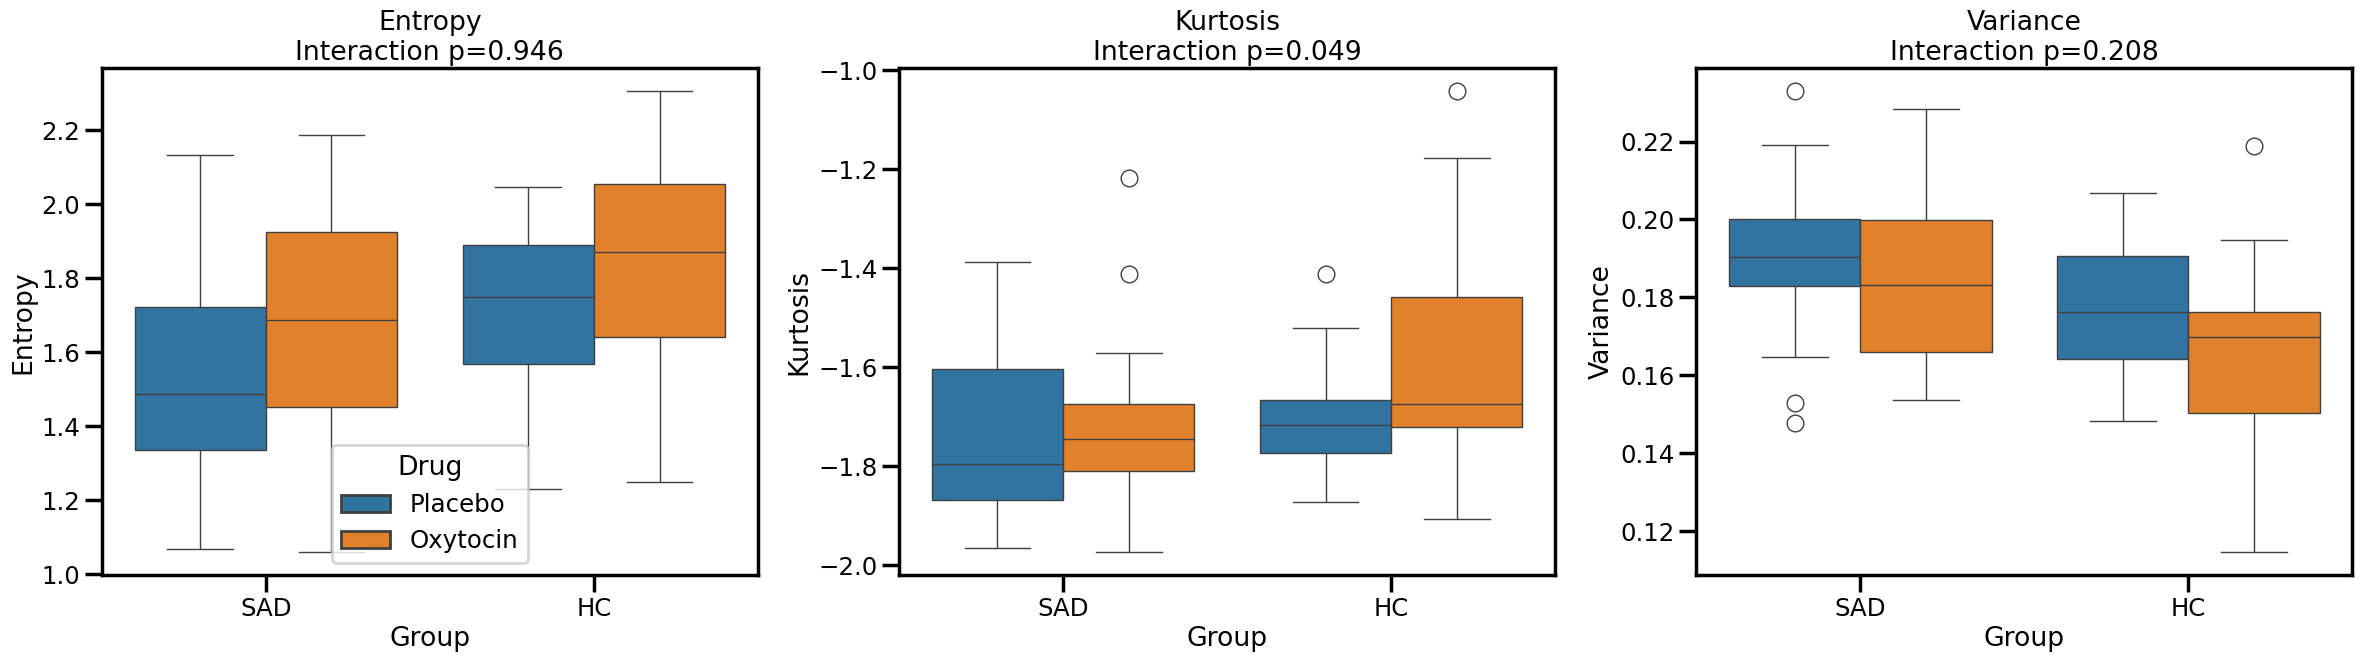

--- Cell 16 Complete ---


In [40]:
# =============================================================================
# 0. CACHE GATE & SETUP
# =============================================================================
cache_cell16 = os.path.join(CHECKPOINT_DIR, "cell_16_opening_test.joblib")

if os.path.exists(cache_cell16):
    print(f"  [LOAD] Found existing metrics in {cache_cell16}. Skipping calculation...")
    results_23 = joblib.load(cache_cell16)
    df_metrics = results_23['df']
    stats_results = results_23['stats']
else:
    print(f"  [CALC] Executing Probability Extraction across Groups/Drugs...")
    
    # 1. Verification of Required Variables
    if 'importance_mask_permutated' not in locals(): 
        raise ValueError("Importance masks missing. Run Cell 9.")
    
    mask_sad_native = importance_mask_permutated['SAD']
    mask_hc_native = importance_mask_permutated['HC']

    # 2. Extract Optimized C from Cell 6
    try:
        c_sad = res_sad['model_sad'].named_steps['classification'].C
        c_hc = res_hc['model_hc'].named_steps['classification'].C
    except:
        c_sad, c_hc = 0.01, 1.0 # Defaulting to your known optimized values
        print("    [WARN] Optimized C not found in memory. Using SAD=0.01, HC=1.0.")

    # 3. Execution Loop
    subgroups_23 = {"SAD_Placebo": [], "SAD_Oxytocin": [], "HC_Placebo": [], "HC_Oxytocin": []}
    for sub in np.unique(sub_ext):
        s_str = str(sub).strip()
        info = sub_to_meta.get(s_str) or sub_to_meta.get(f"sub-{s_str}")
        if info:
            key = f"{info['Group']}_{info['Drug']}"
            if key in subgroups_23: subgroups_23[key].append(sub)

    data_rows = []
    for key, sub_list in subgroups_23.items():
        group, drug = key.split('_')
        curr_mask = mask_sad_native if group == "SAD" else mask_hc_native
        curr_c = c_sad if group == "SAD" else c_hc
        
        for sub in sub_list:
            mask_s = (sub_ext == sub) & np.isin(y_ext, ["CSR", "CSS"])
            if np.sum(mask_s) < 8: continue
            
            # Slicing data for current subject and mask
            X_sub = X_ext[mask_s][:, curr_mask]
            y_sub = y_ext[mask_s]
            
            # LOTO (Leave-One-Trial-Out) Probability Extraction
            logo = LeaveOneGroupOut()
            probs = []
            
            # Treat each trial as its own group for LOTO
            trial_indices = np.arange(len(y_sub))
            
            for train, test in logo.split(X_sub, y_sub, groups=trial_indices):
                clf = LogisticRegression(C=curr_c, solver='liblinear', random_state=42)
                clf.fit(X_sub[train], y_sub[train])
                
                # Get P(Threat)
                csr_idx = np.where(clf.classes_ == "CSR")[0][0]
                probs.append(clf.predict_proba(X_sub[test])[0, csr_idx])
            
            probs = np.array(probs)
            
            # Metric Calculation (matching Analysis 1.4 logic)
            hist, _ = np.histogram(probs, bins=20, range=(0, 1), density=True)
            ent_val = entropy(hist + 1e-9)
            kurt_val = kurtosis(probs, fisher=True)
            var_val = np.var(probs)
            
            data_rows.append({
                "Subject": sub, "Group": group, "Drug": drug, 
                "Entropy": ent_val, 
                "Kurtosis": kurt_val, 
                "Variance": var_val
            })

    df_metrics = pd.DataFrame(data_rows)
    
    # 4. Statistical Testing (LME)
    print("\n[Step 2] Statistical Testing (Metric ~ Group * Drug)...")
    stats_results = {}
    for met in ["Entropy", "Kurtosis", "Variance"]:
        try:
            formula = f"{met} ~ C(Group, Treatment(reference='HC')) * C(Drug, Treatment(reference='Placebo'))"
            md = smf.mixedlm(formula, df_metrics, groups=df_metrics["Subject"])
            mdf = md.fit()
            
            term_int = "C(Group, Treatment(reference='HC'))[T.SAD]:C(Drug, Treatment(reference='Placebo'))[T.Oxytocin]"
            stats_results[met] = mdf.pvalues.get(term_int, 1.0)
            print(f"  > {met} Interaction p={stats_results[met]:.4f}")
        except Exception as e:
            print(f"  ! {met} failed: {e}")
            stats_results[met] = 1.0

    results_23 = {'df': df_metrics, 'stats': stats_results}
    joblib.dump(results_23, cache_cell16)

# =============================================================================
# 5. VISUALIZATION
# =============================================================================
sns.set_context("poster", font_scale=0.8)
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for i, met in enumerate(["Entropy", "Kurtosis", "Variance"]):
    sns.boxplot(data=df_metrics, x='Group', y=met, hue='Drug', ax=axes[i])
    axes[i].set_title(f"{met}\nInteraction p={stats_results[met]:.3f}")
    if i > 0: axes[i].get_legend().remove()

plt.tight_layout()
plt.show()

print("--- Cell 16 Complete ---")

--- Running Analysis 2.4: Spatial Re-Alignment (Using Analysis 1.1 Output) ---
  [LOAD] Loading Healthy Template from: /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_network/checkpoint/results_analysis_11.joblib
  > Successfully retrieved 'model_hc'.
  > Model Classes: ['CSR' 'CSS']

[Step 1] Applying Healthy Model to SAD Subgroups...
  > Accuracy (Train HC -> Test SAD-PLC): 52.7%
  > Accuracy (Train HC -> Test SAD-OXT): 55.3%


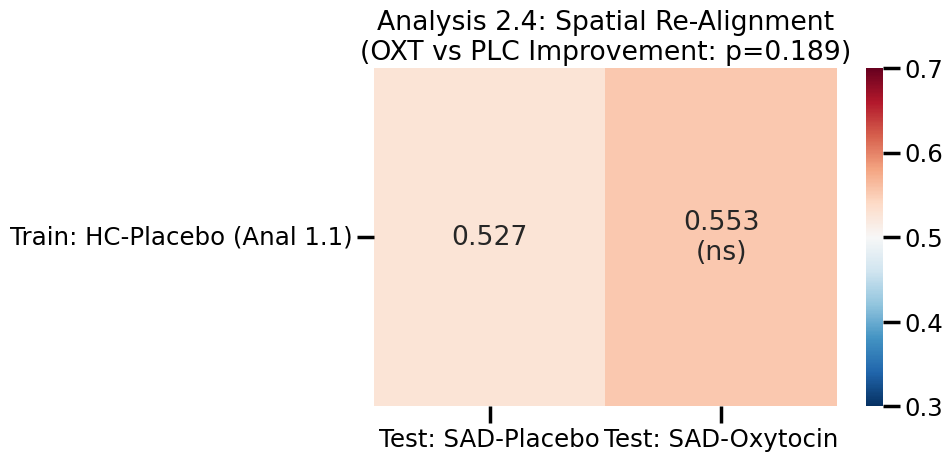

['/Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_network/checkpoint/cell_17_realignment.joblib']

In [43]:
# Cell 17: Analysis 2.4 - Spatial Re-Alignment (The "Normalizing" Effect)
print("--- Running Analysis 2.4: Spatial Re-Alignment (Using Analysis 1.1 Output) ---")
# Constants
COND_SAFE = "CSS"
COND_THREAT = "CSR"
LABELS = [COND_SAFE, COND_THREAT]

# =============================================================================
# 0. Setup: Retrieve Correct Model from Cell 6 Results
# =============================================================================
path_c6 = os.path.join(CHECKPOINT_DIR, "results_analysis_11.joblib")

if os.path.exists(path_c6):
    print(f"  [LOAD] Loading Healthy Template from: {path_c6}")
    res_11 = joblib.load(path_c6)
    
    # Extract the refitted HC model
    if 'model_hc' in res_11:
        gold_model = res_11['model_hc']
        print(f"  > Successfully retrieved 'model_hc'.")
    else:
        # Fallback in case it's nested in a dict
        gold_model = res_11.get('HC', {}).get('model')
        if gold_model is None:
            raise KeyError("Could not find 'model_hc' or 'HC' model in the joblib file.")
else:
    raise FileNotFoundError(f"Analysis 1.1 results not found at {path_c6}. Please run Cell 6.")

# Verify Classes
print(f"  > Model Classes: {gold_model.classes_}")
if not set(LABELS).issubset(set(gold_model.classes_)):
    raise ValueError(f"Model trained on {gold_model.classes_}, but {LABELS} required.")

# =============================================================================
# 1. Data Retrieval (SAD Placebo vs SAD Oxytocin)
# =============================================================================
# Pulling the 'X', 'y', and 'sub' arrays for the respective drug groups
X_sad_plc, y_sad_plc, sub_sad_plc = get_ext_data("SAD_Placebo")
X_sad_oxt, y_sad_oxt, sub_sad_oxt = get_ext_data("SAD_Oxytocin")

# =============================================================================
# 2. Cross-Decoding (Forced-Choice Accuracy)
# =============================================================================
print("\n[Step 1] Applying Healthy Model to SAD Subgroups...")

def get_forced_choice_metrics(X, y, subs, model):
    mask = np.isin(y, LABELS)
    X_f, y_f, sub_f = X[mask], y[mask], subs[mask]
    
    # Get decision scores (distance from hyperplane)
    scores = model.decision_function(X_f)
    
    # Convert 1D scores to 2D for the forced-choice helper
    scores_2d = np.column_stack((-scores, scores)) if scores.ndim == 1 else scores
    
    # Calculate subject-level forced-choice accuracy
    # Requires compute_subject_forced_choice_accs to be defined in Utils
    accs = compute_subject_forced_choice_accs(
        y_f, scores_2d, sub_f, list(model.classes_)
    )
    return accs

acc_sad_plc = get_forced_choice_metrics(X_sad_plc, y_sad_plc, sub_sad_plc, gold_model)
acc_sad_oxt = get_forced_choice_metrics(X_sad_oxt, y_sad_oxt, sub_sad_oxt, gold_model)

m_plc = np.mean(acc_sad_plc)
m_oxt = np.mean(acc_sad_oxt)

print(f"  > Accuracy (Train HC -> Test SAD-PLC): {m_plc:.1%}")
print(f"  > Accuracy (Train HC -> Test SAD-OXT): {m_oxt:.1%}")

# =============================================================================
# 3. Statistical Test & Visualization
# =============================================================================
t_stat, p_val = ttest_ind(acc_sad_oxt, acc_sad_plc, alternative='greater')
sig_label = "*" if p_val < 0.05 else "ns"

sns.set_context("poster", font_scale=0.8)
fig, ax = plt.subplots(figsize=(10, 5))

# Prepare Matrix: 1 Row (Train HC) x 2 Cols (Test PLC, Test OXT)
matrix_data = np.array([[m_plc, m_oxt]])

# Annotation String
annot_data = np.array([
    [f"{m_plc:.3f}", f"{m_oxt:.3f}\n({sig_label})"]
])

# Draw Heatmap
sns.heatmap(matrix_data, annot=annot_data, fmt="", cmap="RdBu_r", 
            vmin=0.3, vmax=0.7, center=0.5, cbar=True,
            xticklabels=['Test: SAD-Placebo', 'Test: SAD-Oxytocin'], 
            yticklabels=['Train: HC-Placebo (Anal 1.1)'], ax=ax)

ax.set_title(f"Analysis 2.4: Spatial Re-Alignment\n(OXT vs PLC Improvement: p={p_val:.3f})")
plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()

# Save results for manuscript
results_24 = {'acc_plc': acc_sad_plc, 'acc_oxt': acc_sad_oxt, 'p_val': p_val}
joblib.dump(results_24, os.path.join(CHECKPOINT_DIR, "cell_17_realignment.joblib"))

--- Running Analysis 2.5: Reverse Cross-Decoding (SAD -> HC) ---
  [LOAD] Loading Healthy Template from: /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_network/checkpoint/results_analysis_11.joblib
  > Successfully retrieved 'model_sad'.
  > Model Classes: ['CSR' 'CSS']

[Step 1] Applying SAD Model to Healthy Subgroups...
  > Accuracy (Train SAD -> Test HC-PLC): 55.8%
  > Accuracy (Train SAD -> Test HC-OXT): 56.0%


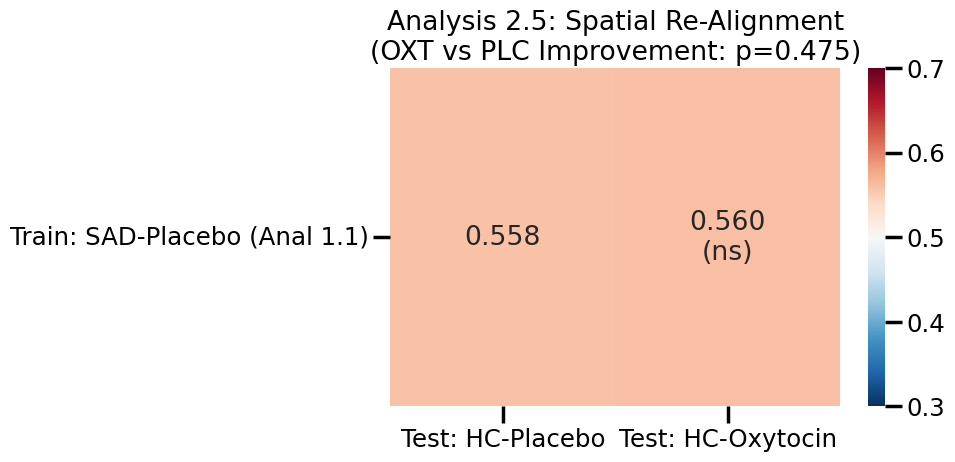

['/Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_network/checkpoint/cell_18_realignment.joblib']

In [75]:
# Cell 18: Analysis 2.5 - Reverse Cross-Decoding (SAD Template -> HC)
# Objective: Test if the "Disordered" SAD representation generalizes to Healthy brains.
# Protocol:
#   1. Train Model on SAD-Placebo (CSS vs CSR).
#   2. Feature Selection: Full feature set.
#   3. Test on HC-Placebo and HC-Oxytocin.
#   4. Metric: Subject-level forced-choice accuracy from decision scores.
# Hypothesis: Accuracy should be LOW (near chance), confirming "Functional Specificity".

print("--- Running Analysis 2.5: Reverse Cross-Decoding (SAD -> HC) ---")

# Constants
COND_SAFE = "CSS"
COND_THREAT = "CSR"
LABELS = [COND_SAFE, COND_THREAT]

# =============================================================================
# 0. Setup: Retrieve Correct Model from Cell 6 Results
# =============================================================================
path_c6 = os.path.join(CHECKPOINT_DIR, "results_analysis_11.joblib")

if os.path.exists(path_c6):
    print(f"  [LOAD] Loading Healthy Template from: {path_c6}")
    res_11 = joblib.load(path_c6)
    
    # Extract the refitted HC model
    if 'model_sad' in res_11:
        gold_model = res_11['model_sad']
        print(f"  > Successfully retrieved 'model_sad'.")
    else:
        # Fallback in case it's nested in a dict
        gold_model = res_11.get('HC', {}).get('model')
        if gold_model is None:
            raise KeyError("Could not find 'model_sad' or 'SAD' model in the joblib file.")
else:
    raise FileNotFoundError(f"Analysis 1.1 results not found at {path_c6}. Please run Cell 6.")

# Verify Classes
print(f"  > Model Classes: {gold_model.classes_}")
if not set(LABELS).issubset(set(gold_model.classes_)):
    raise ValueError(f"Model trained on {gold_model.classes_}, but {LABELS} required.")

# =============================================================================
# 1. Data Retrieval (SAD Placebo vs SAD Oxytocin)
# =============================================================================
# Pulling the 'X', 'y', and 'sub' arrays for the respective drug groups
X_hc_plc, y_hc_plc, sub_hc_plc = get_ext_data("HC_Placebo")
X_hc_oxt, y_hc_oxt, sub_hc_oxt = get_ext_data("HC_Oxytocin")

# =============================================================================
# 2. Cross-Decoding (Forced-Choice Accuracy)
# =============================================================================
print("\n[Step 1] Applying SAD Model to Healthy Subgroups...")

def get_forced_choice_metrics(X, y, subs, model):
    mask = np.isin(y, LABELS)
    X_f, y_f, sub_f = X[mask], y[mask], subs[mask]
    
    # Get decision scores (distance from hyperplane)
    scores = model.decision_function(X_f)
    
    # Convert 1D scores to 2D for the forced-choice helper
    scores_2d = np.column_stack((-scores, scores)) if scores.ndim == 1 else scores
    
    # Calculate subject-level forced-choice accuracy
    # Requires compute_subject_forced_choice_accs to be defined in Utils
    accs = compute_subject_forced_choice_accs(
        y_f, scores_2d, sub_f, list(model.classes_)
    )
    return accs

acc_hc_plc = get_forced_choice_metrics(X_hc_plc, y_hc_plc, sub_hc_plc, gold_model)
acc_hc_oxt = get_forced_choice_metrics(X_hc_oxt, y_hc_oxt, sub_hc_oxt, gold_model)

m_plc = np.mean(acc_hc_plc)
m_oxt = np.mean(acc_hc_oxt)

print(f"  > Accuracy (Train SAD -> Test HC-PLC): {m_plc:.1%}")
print(f"  > Accuracy (Train SAD -> Test HC-OXT): {m_oxt:.1%}")

# =============================================================================
# 3. Statistical Test & Visualization
# =============================================================================
t_stat, p_val = ttest_ind(acc_hc_oxt, acc_hc_plc, alternative='greater')
sig_label = "*" if p_val < 0.05 else "ns"

sns.set_context("poster", font_scale=0.8)
fig, ax = plt.subplots(figsize=(10, 5))

# Prepare Matrix: 1 Row (Train HC) x 2 Cols (Test PLC, Test OXT)
matrix_data = np.array([[m_plc, m_oxt]])

# Annotation String
annot_data = np.array([
    [f"{m_plc:.3f}", f"{m_oxt:.3f}\n({sig_label})"]
])

# Draw Heatmap
sns.heatmap(matrix_data, annot=annot_data, fmt="", cmap="RdBu_r", 
            vmin=0.3, vmax=0.7, center=0.5, cbar=True,
            xticklabels=['Test: HC-Placebo', 'Test: HC-Oxytocin'], 
            yticklabels=['Train: SAD-Placebo (Anal 1.1)'], ax=ax)

ax.set_title(f"Analysis 2.5: Spatial Re-Alignment\n(OXT vs PLC Improvement: p={p_val:.3f})")
plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()

# Save results for manuscript
results_25 = {'acc_plc': acc_sad_plc, 'acc_oxt': acc_sad_oxt, 'p_val': p_val}
joblib.dump(results_25, os.path.join(CHECKPOINT_DIR, "cell_18_realignment.joblib"))

In [97]:
clinical_dir = '/Users/xiaoqianxiao/projects/NARSAD/MRI/source_data/behav'
LSAS_path = os.path.join(clinical_dir, 'SocialSafetyLearning-LSASSubtotals_DATA_2026-04-25_2306.csv')
ECR_path = os.path.join(clinical_dir, 'SocialSafetyLearning-ECR_DATA_2026-04-25_2306.csv')
DASS_path = os.path.join(clinical_dir, 'SocialSafetyLearning-DASS_DATA_2026-04-25_2306.csv')
#login_participantid; lsas_fear_total; lsas_avoid_total; lsas_total;
df_lsas_raw = pd.read_csv(LSAS_path)
df_lsas = pd.DataFrame()
df_lsas['sub_ID'] = df_lsas_raw['login_participantid']
df_lsas['lsas_fear'] = df_lsas_raw['lsas_fear_total']
df_lsas['lsas_avoid'] = df_lsas_raw['lsas_avoid_total']
df_lsas['lsas_total'] = df_lsas_raw['lsas_total']
#login_participantid; ecr_total;
df_ecr_raw = pd.read_csv(ECR_path)
df_ecr = pd.DataFrame()
df_ecr['sub_ID'] = df_ecr_raw['login_participantid']
df_ecr['ecr_total'] = df_ecr_raw['ecr_total']
#login_participantid; ecr_total;
df_dass_raw = pd.read_csv(DASS_path)
# Define item groupings (Note: indices match your dass_q# names)
depression_items = ['dass_q3_positive', 'dass_q5_initiative', 'dass_q10_forward', 
                    'dass_q13_blue', 'das_q16_enthusiastic', 'dass_q17_worth', 'dass_q21_life']

anxiety_items = ['dass_q2_drymouth', 'dass_q4_breathing', 'dass_q7_trembling', 
                 'dass_q9_panic', 'dass_q15_panic', 'dass_q19_heart', 'dass_q20_scared']

stress_items = ['dass_q1_winddown', 'dass_q6_overreact', 'dass_q8_nervousenergy', 
                'dass_q11_agitated', 'dass_q12_relax', 'dass_q14_intolerant', 'dass_q18_touch']

# Calculate Subscale Totals (Summing and multiplying by 2 per DASS-21 protocol)
df_dass = pd.DataFrame()
df_dass['sub_ID'] = df_dass_raw['login_participantid']
df_dass['dass_depression'] = df_dass_raw[depression_items].sum(axis=1) * 2
df_dass['dass_anxiety'] = df_dass_raw[anxiety_items].sum(axis=1) * 2
df_dass['dass_stress'] = df_dass_raw[stress_items].sum(axis=1) * 2
df_scored_clinical = df_dass \
    .merge(df_lsas, on='sub_ID', how='inner') \
    .merge(df_ecr, on='sub_ID', how='inner')

In [101]:
# 1. Extract PV Distance Vectors
vA_sad_pv, vB_sad_pv = extract_metrics_pv(results_12["rdms_sad_raw_pv"])
vA_hc_pv, vB_hc_pv   = extract_metrics_pv(results_12["rdms_hc_raw_pv"])

# 2. Extract Subject IDs from the RDM source arrays
# If 'subs_sad_rdm' isn't in results_12, we derive them from the input variables 
# used in the original calculation loop.
try:
    s_id_sad = results_12['subs_sad_rdm']
    s_id_hc = results_12['subs_hc_rdm']
except KeyError:
    # Fallback: Recover from the variables that were in scope during Cell 10 calculation
    print("[INFO] IDs not in dictionary. Recovering from local scope variables...")
    s_id_sad = np.unique(sub_sad_12)
    s_id_hc = np.unique(sub_hc_12)

# 3. Validation Check
print(f"Lengths: SAD_IDs({len(s_id_sad)}) vs SAD_Dist({len(vA_sad_pv)})")
print(f"Lengths: HC_IDs({len(s_id_hc)}) vs HC_Dist({len(vA_hc_pv)})")

# 4. Final Dataframe Construction
# Using explicit slicing to force match lengths in case of trailing index errors
df_neural_topology = pd.DataFrame({
    'sub_ID': np.concatenate([s_id_sad, s_id_hc]).astype(str),
    'Neural_Dist_Threat_Safety': np.concatenate([vA_sad_pv, vA_hc_pv]),
    'Neural_Dist_Safety_Backgr': np.concatenate([vB_sad_pv, vB_hc_pv]),
    'Group': ['SAD']*len(s_id_sad) + ['HC']*len(s_id_hc)
})

# =============================================================================
# NEURAL INDEX GENERATION (Analysis 1.3: Trajectory Slope)
# =============================================================================

# 1. Prepare Data Containers
# We extract the slopes from df_safe (Safety Learning) 
# because it is the most clinical relevant learning phase.
if 'df_safe' not in locals():
    # If the cell above just ran, it might be nested in the results dictionary
    df_safe = results_13_2['data_safe']

# 2. Calculate Linear Slope per Subject
# This represents the 'Rate of Safety Learning'
def calculate_subject_slopes(df):
    slopes = []
    for sub in df['sub'].unique():
        sub_data = df[df['sub'] == sub].sort_values('trial')
        if len(sub_data) < 3: continue  # Need enough points for a trend
        
        # Linear fit: y = mx + b (we want 'm')
        m, _ = np.polyfit(sub_data['trial'], sub_data['score'], 1)
        
        slopes.append({
            'sub_ID': str(sub),
            'Neural_Rigidity_Slope': m,
            'Neural_Safety_Mean': sub_data['score'].mean()
        })
    return pd.DataFrame(slopes)

df_neural_trajectories = calculate_subject_slopes(df_safe)

print(f"Trajectory Indices generated for {len(df_neural_trajectories)} subjects.")
print(df_neural_trajectories.head())

# =============================================================================
# NEURAL INDEX GENERATION (Analysis 1.4: Decision Uncertainty)
# =============================================================================

# 1. Access the Dataframes from memory (or cache if just loaded)
if 'df_sad_stats' not in locals():
    df_sad_stats = results_14_self['df_sad']
    df_hc_stats = results_14_self['df_hc']

# 2. Tag Groups and Combine
df_sad_idx = df_sad_stats[['sub', 'entropy', 'kurtosis']].copy()
df_sad_idx['Group'] = 'SAD'

df_hc_idx = df_hc_stats[['sub', 'entropy', 'kurtosis']].copy()
df_hc_idx['Group'] = 'HC'

# 3. Final Neural Profile Construction
df_neural_uncertainty = pd.concat([df_sad_idx, df_hc_idx])
df_neural_uncertainty = df_neural_uncertainty.rename(columns={
    'sub': 'sub_ID',
    'entropy': 'Neural_Uncertainty_Entropy',
    'kurtosis': 'Neural_Sharpness_Kurtosis'
})

# Ensure ID is a string for merging
df_neural_uncertainty['sub_ID'] = df_neural_uncertainty['sub_ID'].astype(str)

print(f"Decision Profile generated for {len(df_neural_uncertainty)} subjects.")
print(df_neural_uncertainty.head())

[INFO] IDs not in dictionary. Recovering from local scope variables...
Lengths: SAD_IDs(23) vs SAD_Dist(23)
Lengths: HC_IDs(28) vs HC_Dist(28)
Trajectory Indices generated for 51 subjects.
  sub_ID  Neural_Rigidity_Slope  Neural_Safety_Mean
0   N101               0.015977            0.053029
1   N110               0.018815            0.057112
2   N111               0.018680            0.060701
3   N112               0.028084            0.077048
4   N114               0.025436            0.055405
Decision Profile generated for 51 subjects.
  sub_ID  Neural_Uncertainty_Entropy  Neural_Sharpness_Kurtosis Group
0   N101                    1.977006                  -1.771386   SAD
1   N110                    1.424443                  -1.639568   SAD
2   N111                    1.418304                  -1.697831   SAD
3   N112                    1.526878                  -1.475795   SAD
4   N114                    0.881532                  -1.928846   SAD


In [173]:
df_final_indecision.columns

Index(['sub_ID', 'dass_depression', 'dass_anxiety', 'dass_stress', 'lsas_fear',
       'lsas_avoid', 'lsas_total', 'ecr_total', 'Neural_Dist_Threat_Safety',
       'Neural_Dist_Safety_Backgr', 'Group_x', 'Neural_Rigidity_Slope',
       'Neural_Safety_Mean', 'Neural_Uncertainty_Entropy',
       'Neural_Sharpness_Kurtosis', 'Group_y'],
      dtype='object')

In [136]:
#df_neural_topology
df_final_indecision = df_scored_clinical \
    .merge(df_neural_topology, on='sub_ID', how='inner') \
    .merge(df_neural_trajectories, on='sub_ID', how='inner') \
    .merge(df_neural_uncertainty, on='sub_ID', how='inner')

df_final_indecision['sub_ID'] = df_final_indecision['sub_ID'].astype(str)
meta['sub_ID'] = meta['subject_id'].astype(str)

df_master_analysis = df_final_indecision.merge(
    meta, 
    on='sub_ID', 
    how='inner'
)

Group  | Neural Metric                | Clinical     | r      | p        | Sig
--------------------------------------------------------------------------------
SAD    | Neural_Dist_Threat_Safety    | lsas_total   | -0.06  | 0.7702   | ns
SAD    | Neural_Dist_Threat_Safety    | lsas_fear    | -0.09  | 0.6937   | ns
SAD    | Neural_Dist_Threat_Safety    | lsas_avoid   | -0.03  | 0.8853   | ns
SAD    | Neural_Dist_Threat_Safety    | dass_anxiety | 0.35   | 0.0977   | ns
SAD    | Neural_Dist_Threat_Safety    | dass_stress  | -0.01  | 0.9503   | ns
SAD    | Neural_Dist_Threat_Safety    | ecr_total    | 0.03   | 0.8981   | ns
SAD    | Neural_Dist_Safety_Backgr    | lsas_total   | 0.07   | 0.7434   | ns
SAD    | Neural_Dist_Safety_Backgr    | lsas_fear    | 0.08   | 0.7292   | ns
SAD    | Neural_Dist_Safety_Backgr    | lsas_avoid   | 0.06   | 0.8009   | ns
SAD    | Neural_Dist_Safety_Backgr    | dass_anxiety | 0.23   | 0.2990   | ns
SAD    | Neural_Dist_Safety_Backgr    | dass_stress  | 0.05 

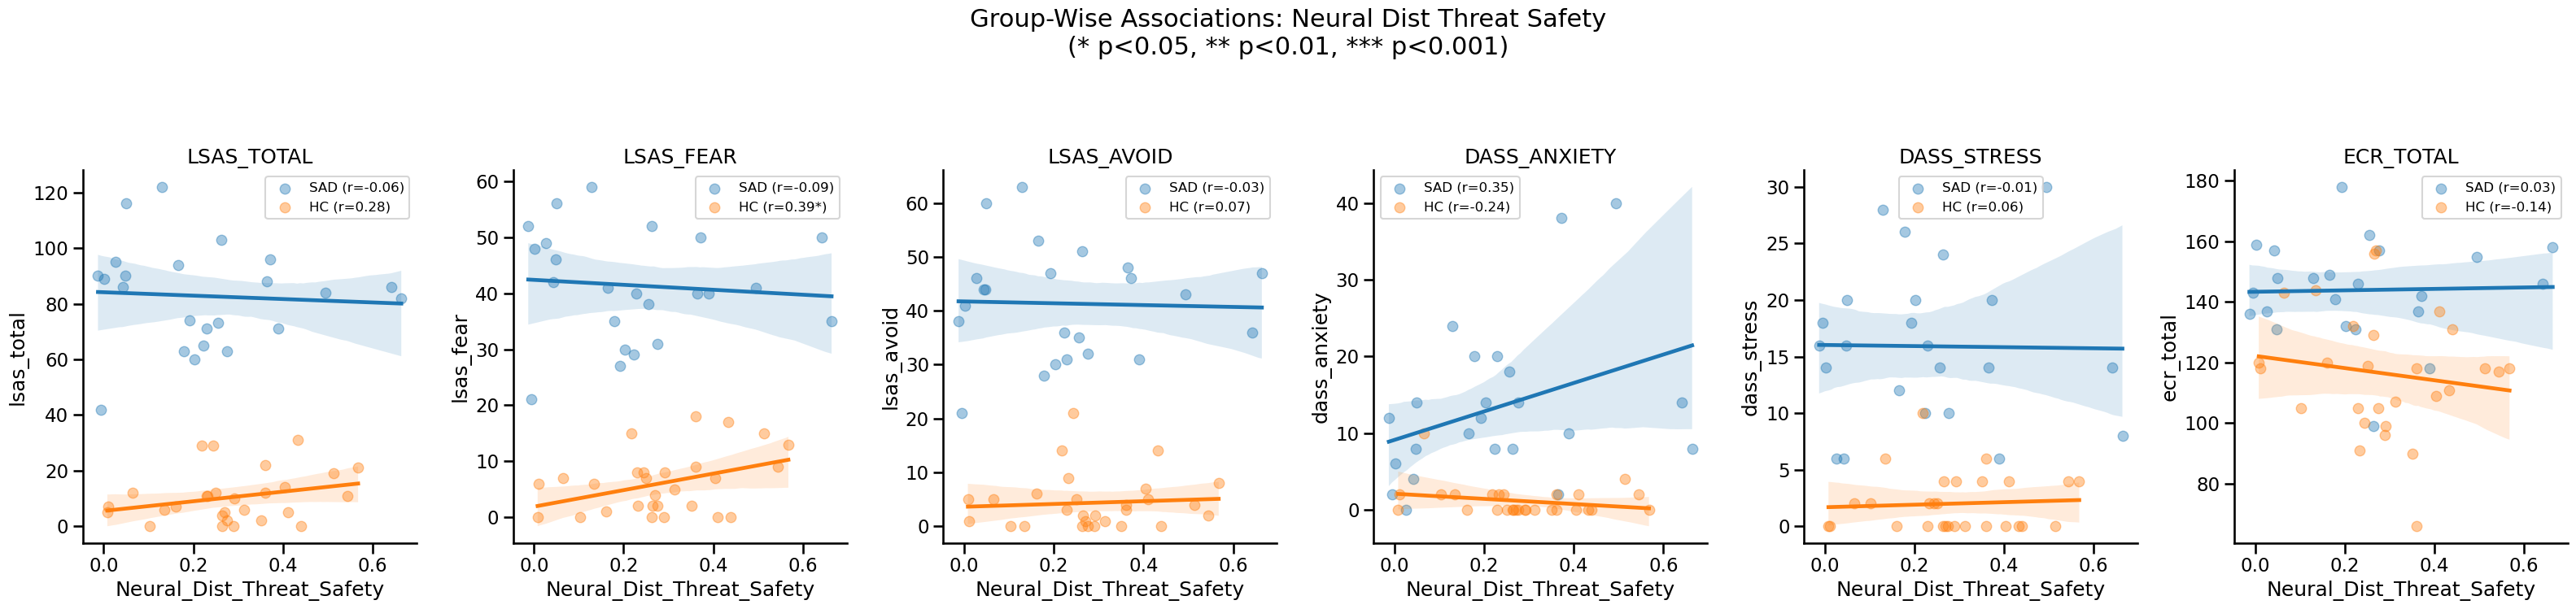

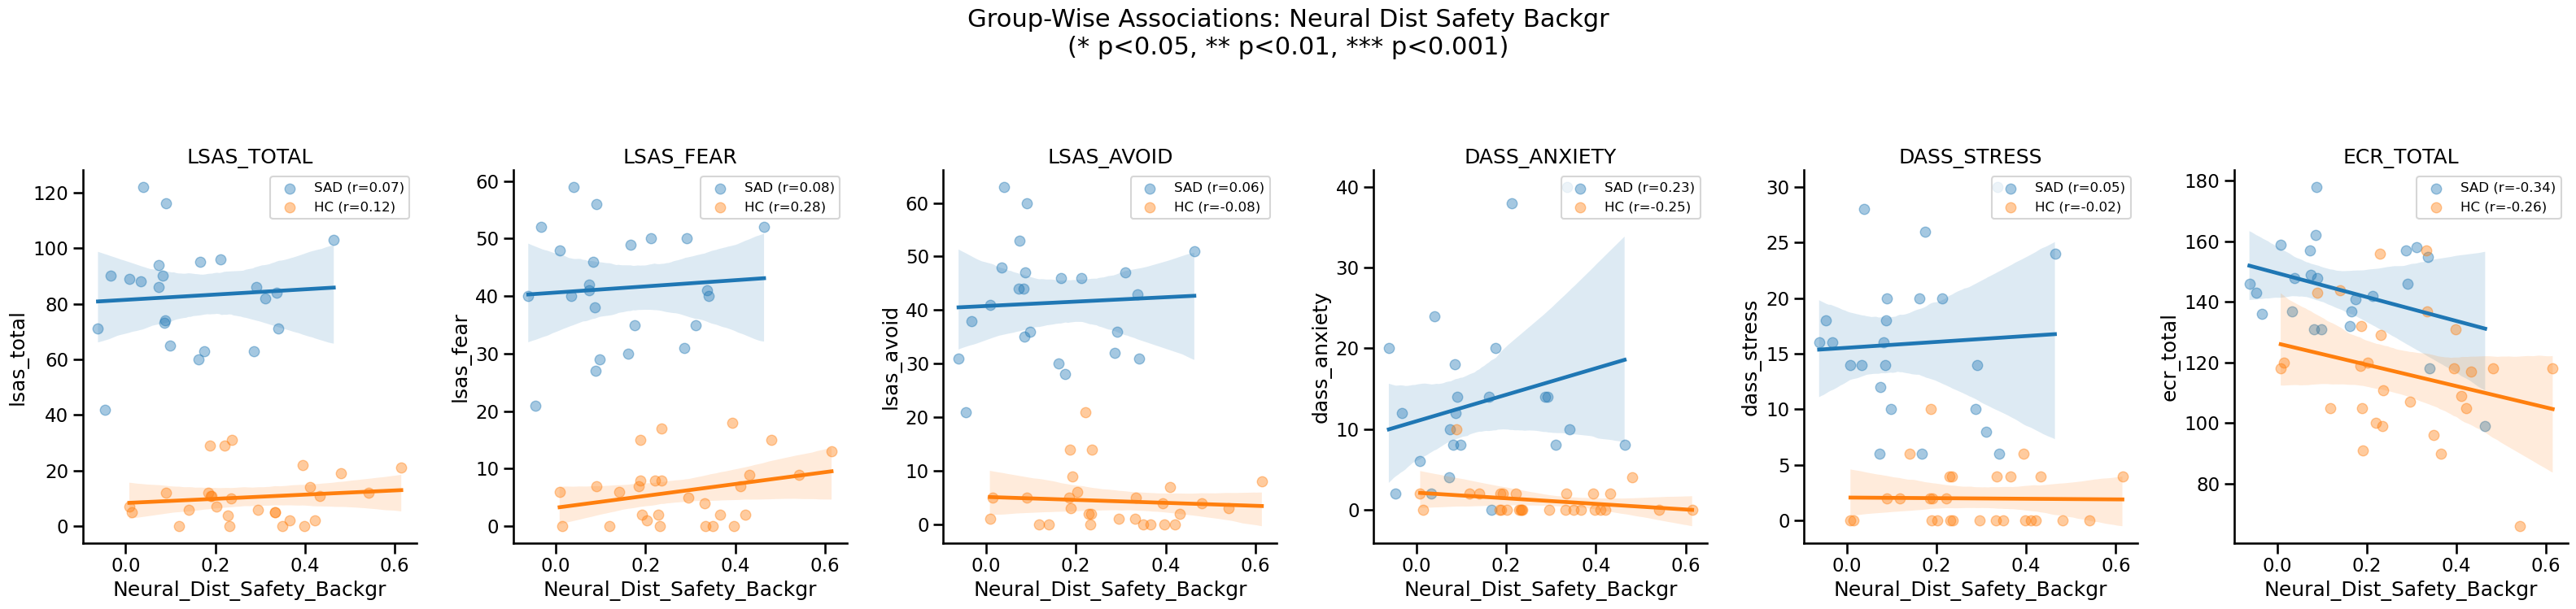

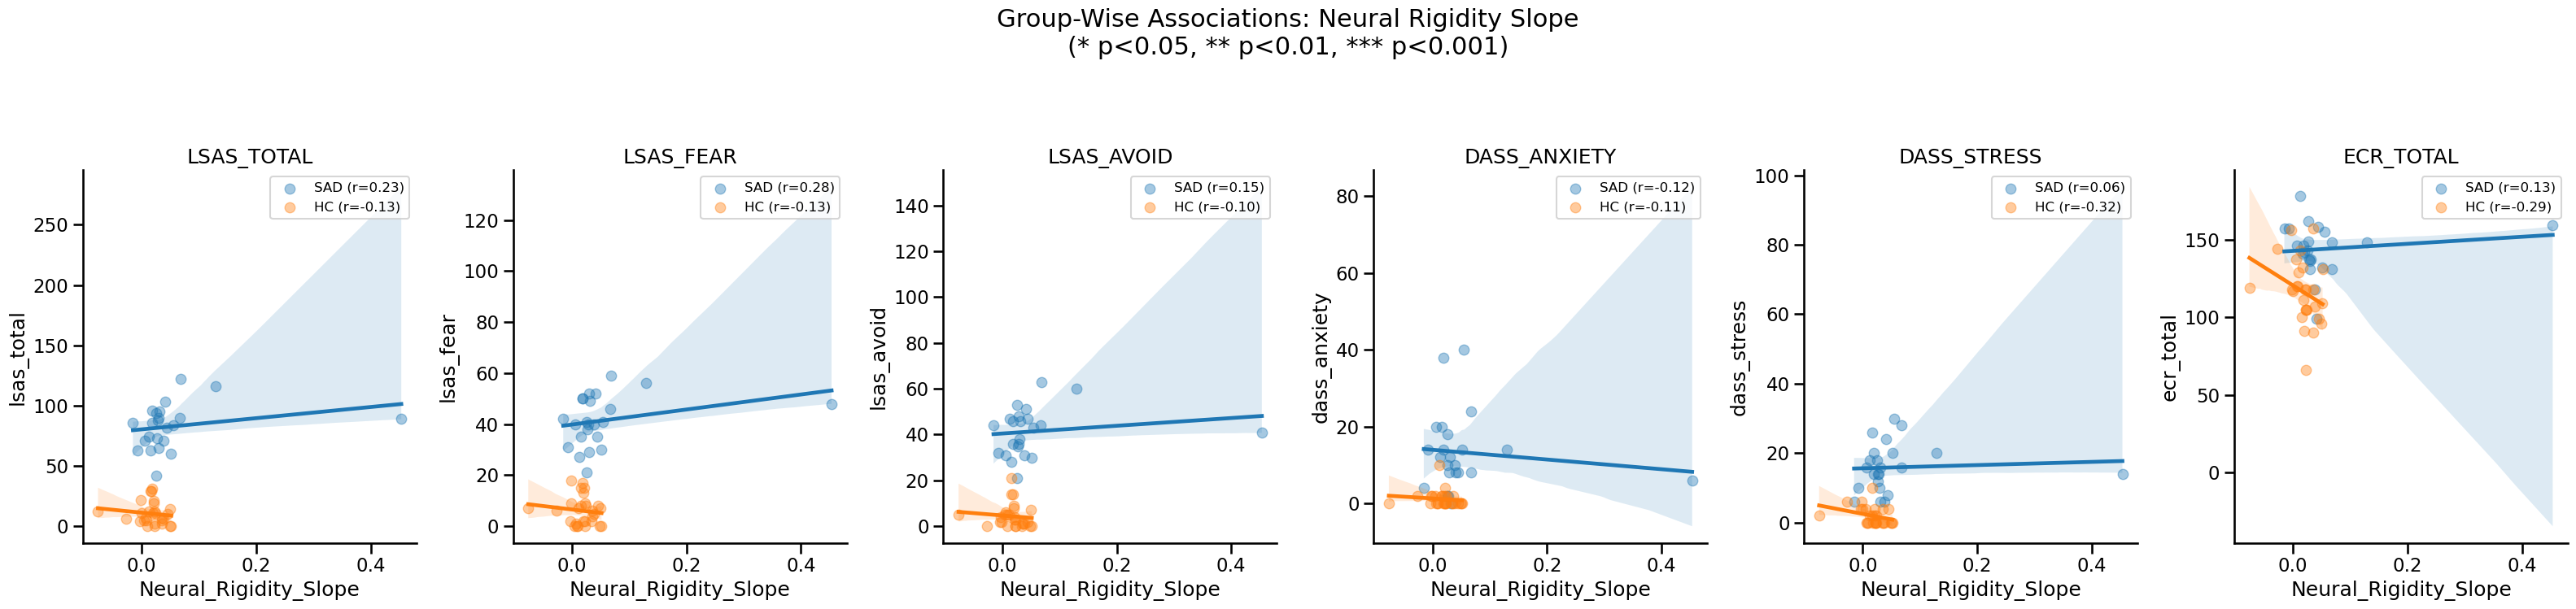

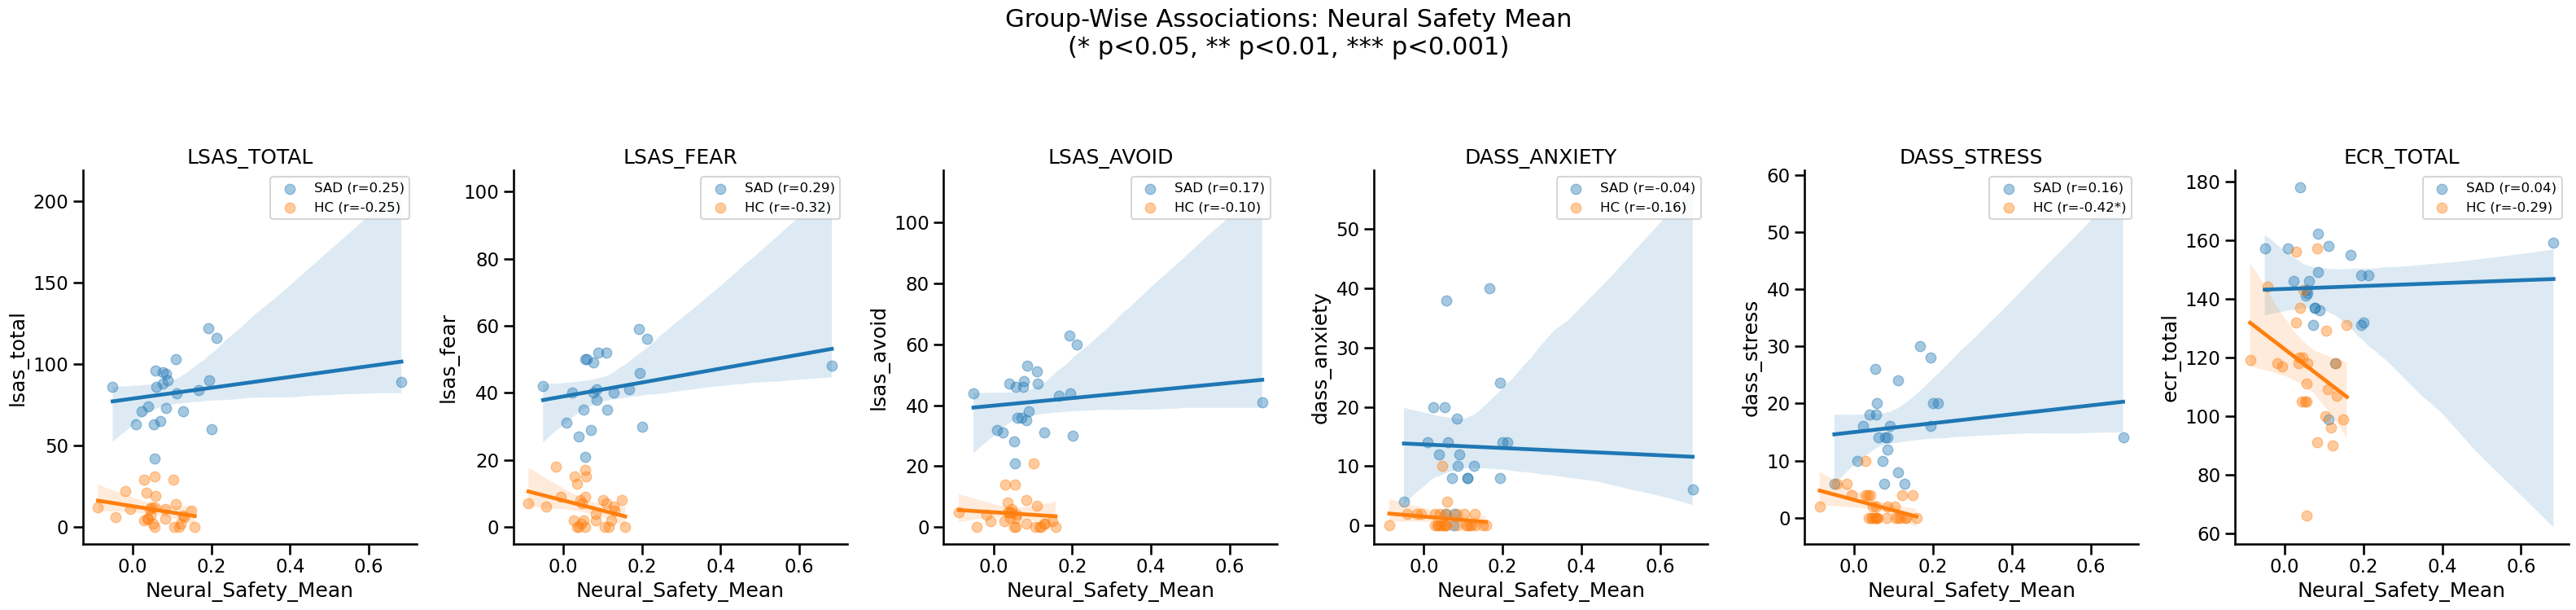

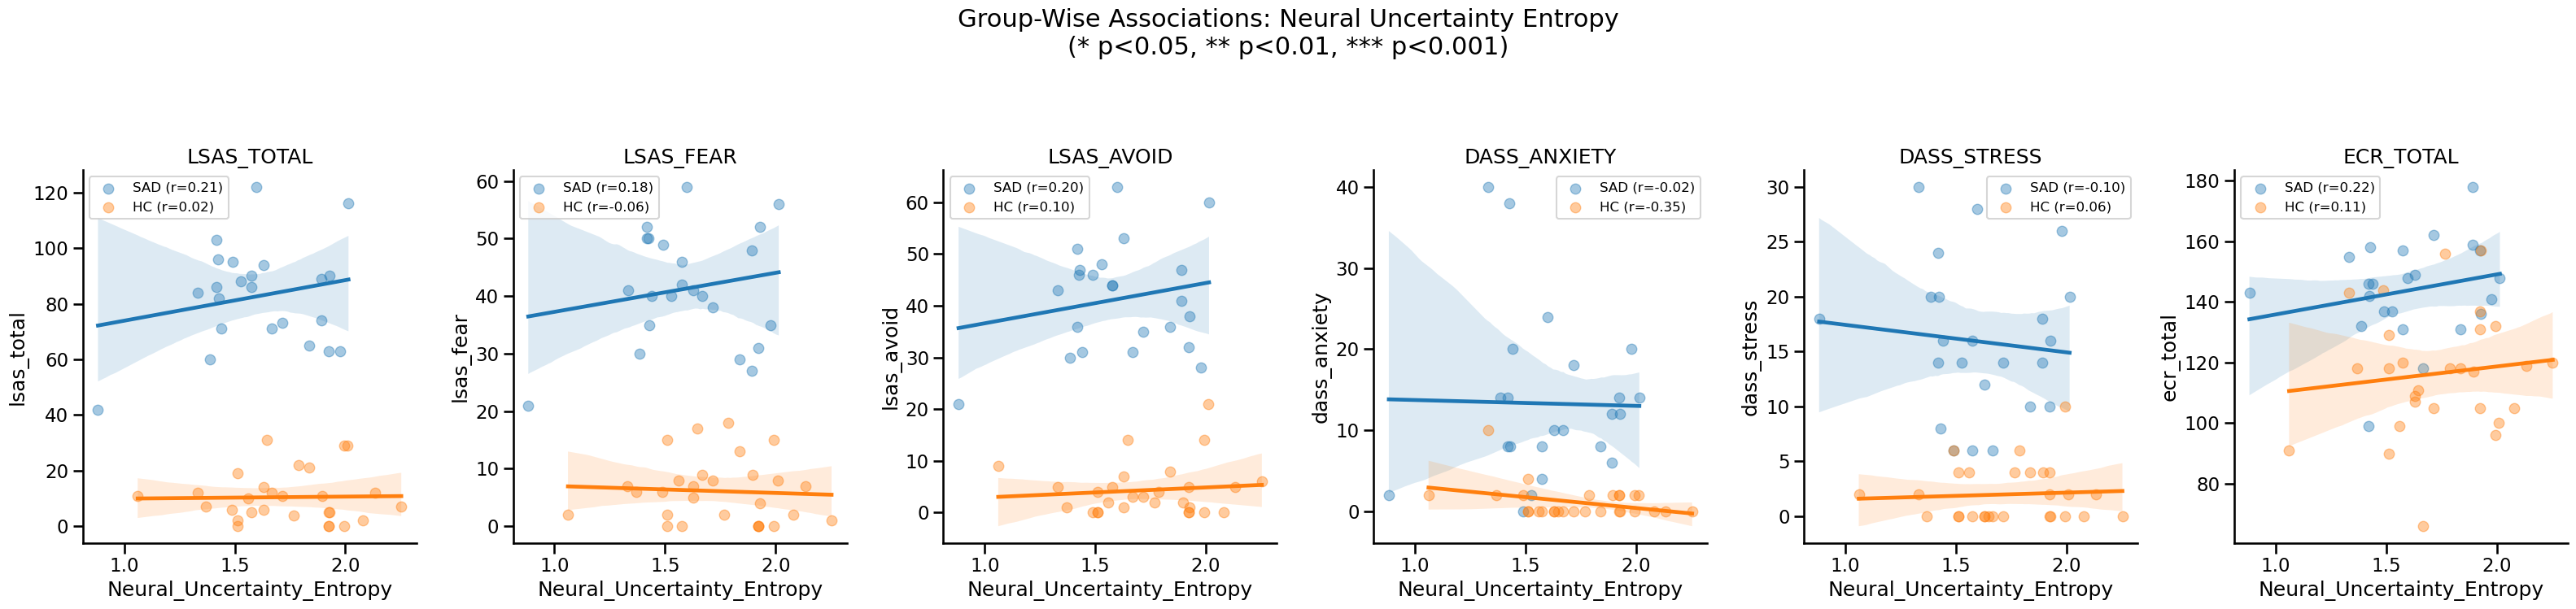

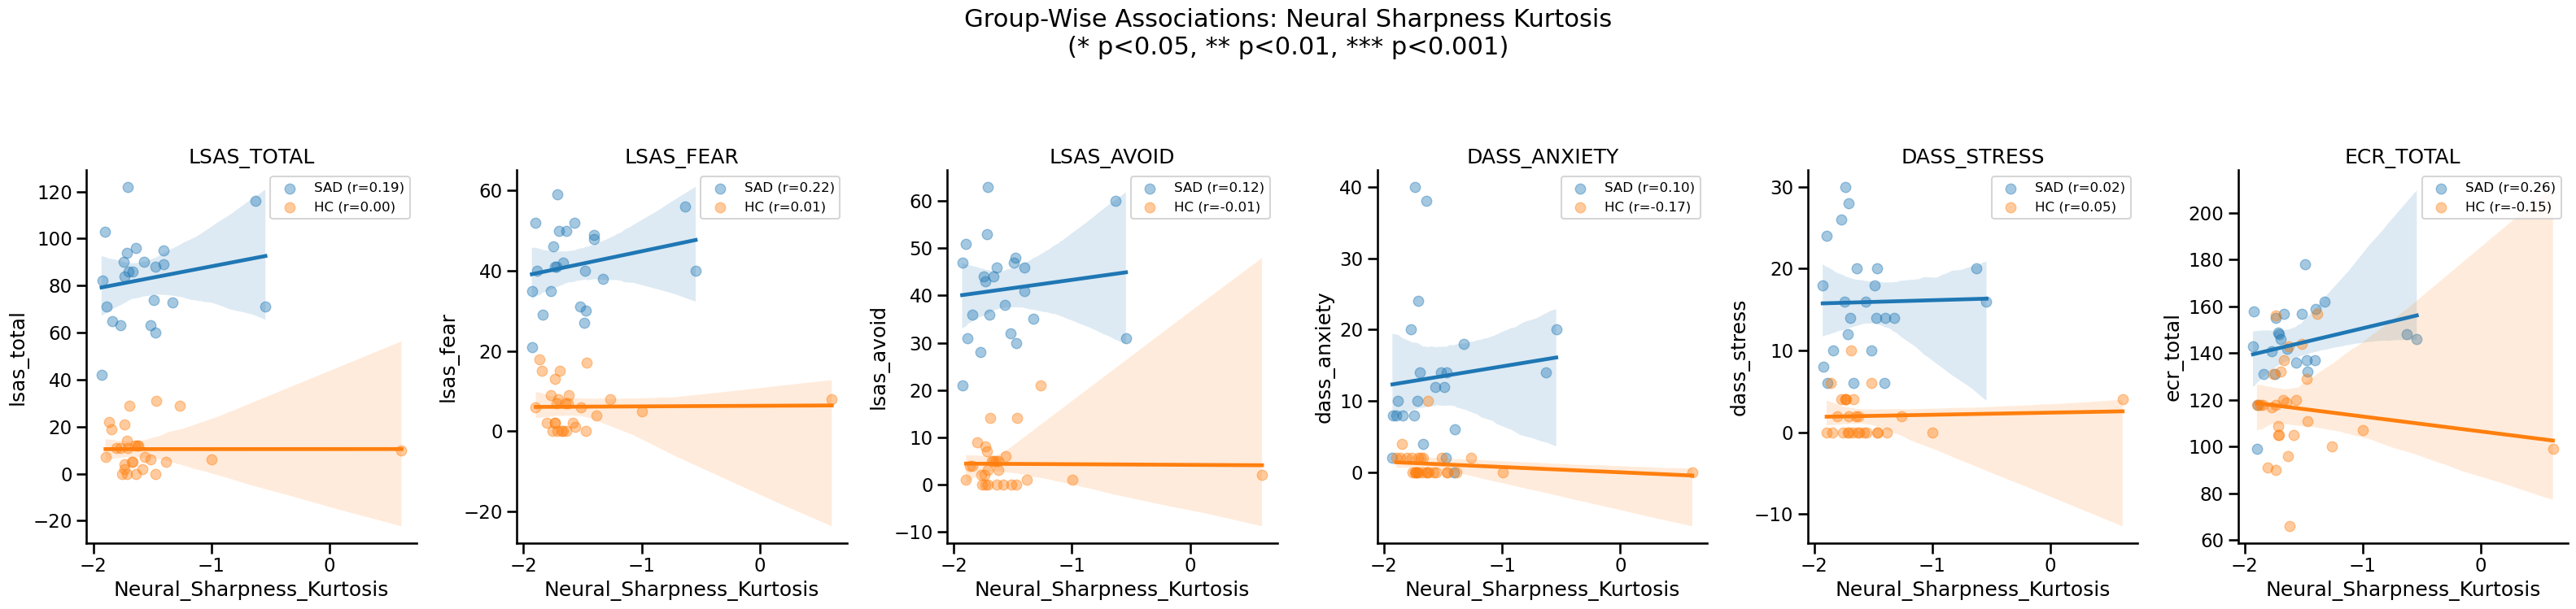

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. Config
groups = df_master_analysis['Group'].unique()
neural_metrics = ['Neural_Dist_Threat_Safety',
       'Neural_Dist_Safety_Backgr', 'Neural_Rigidity_Slope',
       'Neural_Safety_Mean', 'Neural_Uncertainty_Entropy',
       'Neural_Sharpness_Kurtosis']
clinical_indices = ['lsas_total', 'lsas_fear', 'lsas_avoid', 'dass_anxiety', 'dass_stress', 'ecr_total']

def get_sig_star(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "ns"

# 2. Execution & Statistics Printout
group_results = []
print(f"{'Group':<6} | {'Neural Metric':<28} | {'Clinical':<12} | {'r':<6} | {'p':<8} | {'Sig'}")
print("-" * 80)

for grp in groups:
    df_grp = df_master_analysis[df_master_analysis['Group'] == grp]
    for n_m in neural_metrics:
        for c_i in clinical_indices:
            valid = df_grp[[n_m, c_i]].dropna()
            if len(valid) > 5:
                r, p = pearsonr(valid[n_m], valid[c_i])
                sig = get_sig_star(p)
                
                # Print stats for the table
                print(f"{grp:<6} | {n_m:<28} | {c_i:<12} | {r:<6.2f} | {p:<8.4f} | {sig}")
                
                group_results.append({
                    'Group': grp, 'Neural': n_m, 'Clinical': c_i, 
                    'r': r, 'p': p, 'sig': sig
                })

df_res_grp = pd.DataFrame(group_results)

# 3. Visualization: Group-Wise Comparative Grids
sns.set_context("talk")

for n_m in neural_metrics:
    fig, axes = plt.subplots(1, len(clinical_indices), figsize=(32, 7))
    
    for j, c_i in enumerate(clinical_indices):
        # We use a combined legend to show significance per group
        for grp in groups:
            grp_data = df_master_analysis[df_master_analysis['Group_x'] == grp]
            stats = df_res_grp[(df_res_grp['Group'] == grp) & 
                               (df_res_grp['Neural'] == n_m) & 
                               (df_res_grp['Clinical'] == c_i)]
            
            label_str = grp
            if not stats.empty:
                sig = stats['sig'].values[0]
                r = stats['r'].values[0]
                label_str = f"{grp} (r={r:.2f}{'' if sig=='ns' else sig})"

            sns.regplot(data=grp_data, x=n_m, y=c_i, ax=axes[j], 
                        label=label_str, scatter_kws={'alpha':0.4})
            
        axes[j].set_title(f"{c_i.upper()}")
        axes[j].legend(fontsize=12, loc='best')
        sns.despine(ax=axes[j])
        
    plt.suptitle(f"Group-Wise Associations: {n_m.replace('_', ' ')}\n(* p<0.05, ** p<0.01, *** p<0.001)", 
                 fontsize=22, y=1.08)
    plt.tight_layout()
    plt.show()

Group  | Neural Metric                | Clinical     | r_adj  | p        | Sig
-------------------------------------------------------------------------------------
SAD    | Neural_Dist_Threat_Safety    | lsas_total   | 0.00   | 0.9880   | ns
SAD    | Neural_Dist_Threat_Safety    | lsas_fear    | -0.04  | 0.8469   | ns
SAD    | Neural_Dist_Threat_Safety    | lsas_avoid   | 0.05   | 0.8288   | ns
SAD    | Neural_Dist_Threat_Safety    | dass_anxiety | 0.35   | 0.1094   | ns
SAD    | Neural_Dist_Threat_Safety    | dass_stress  | 0.03   | 0.8783   | ns
SAD    | Neural_Dist_Threat_Safety    | ecr_total    | 0.08   | 0.7081   | ns
SAD    | Neural_Dist_Safety_Backgr    | lsas_total   | 0.07   | 0.7496   | ns
SAD    | Neural_Dist_Safety_Backgr    | lsas_fear    | 0.08   | 0.7371   | ns
SAD    | Neural_Dist_Safety_Backgr    | lsas_avoid   | 0.06   | 0.8069   | ns
SAD    | Neural_Dist_Safety_Backgr    | dass_anxiety | 0.23   | 0.3089   | ns
SAD    | Neural_Dist_Safety_Backgr    | dass_stress  | 

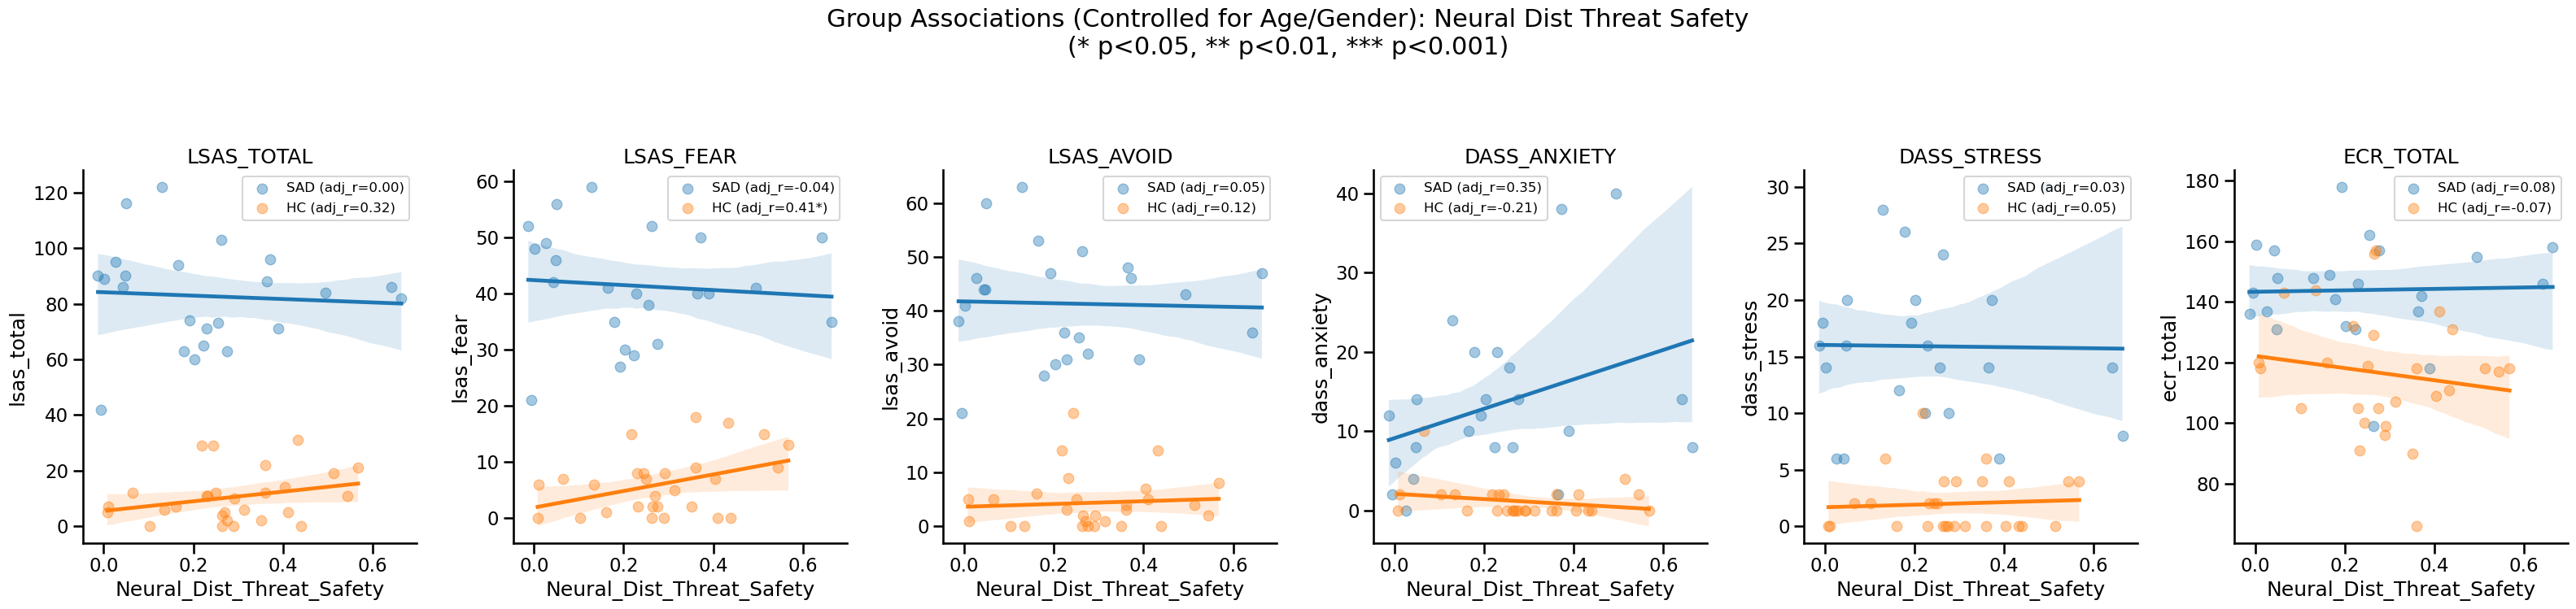

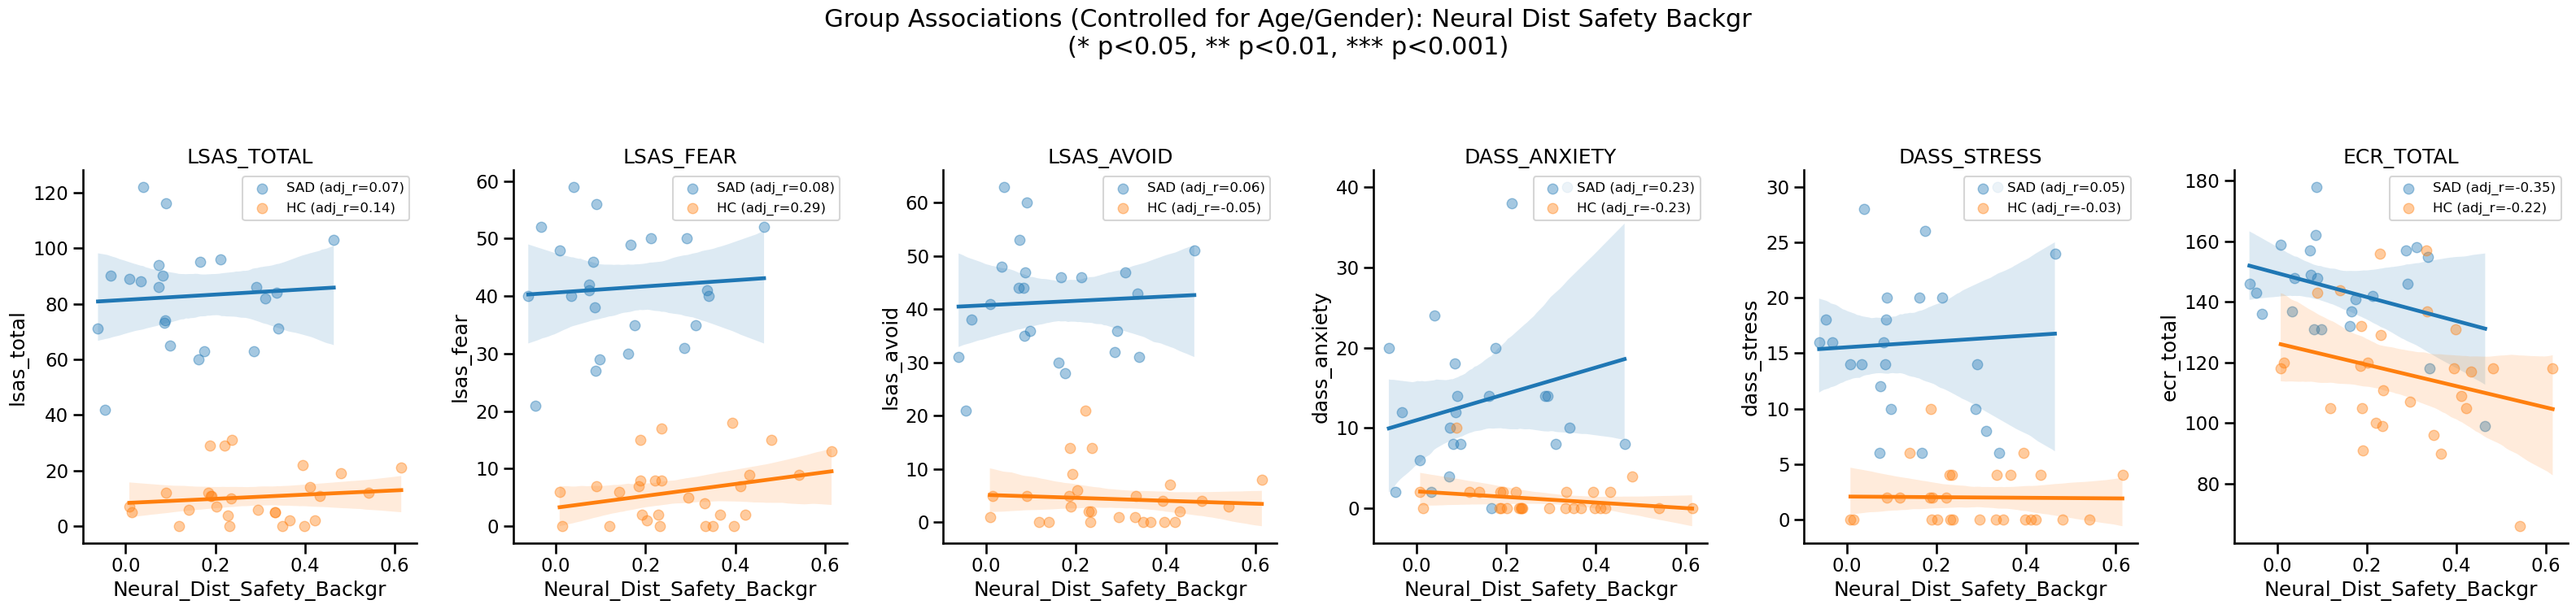

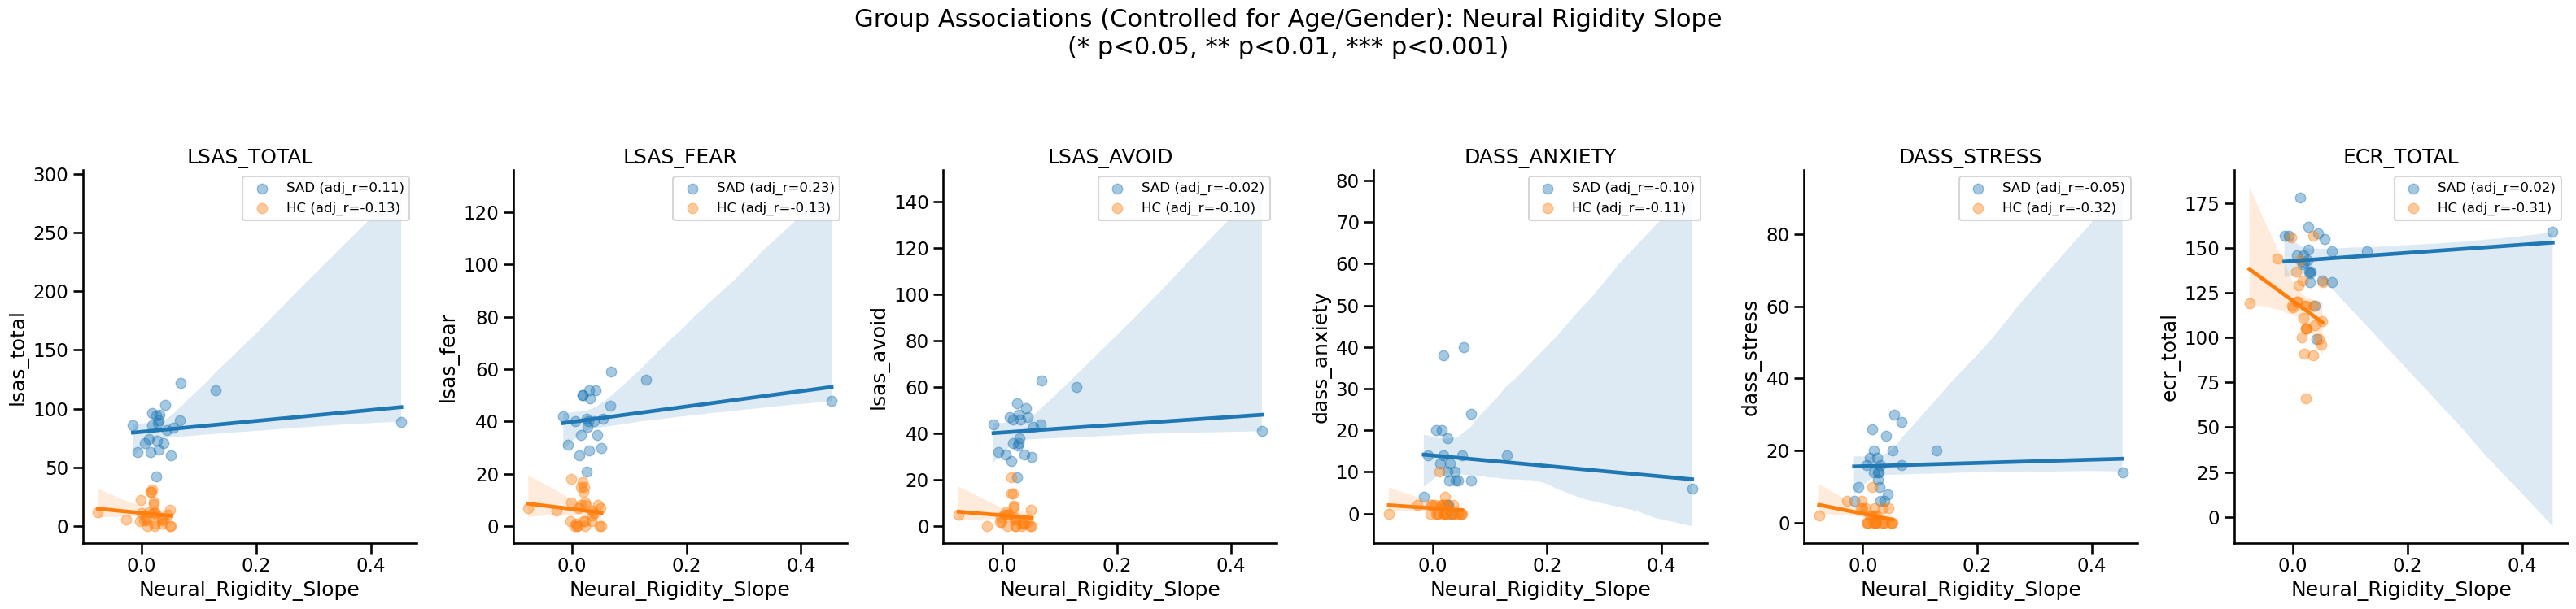

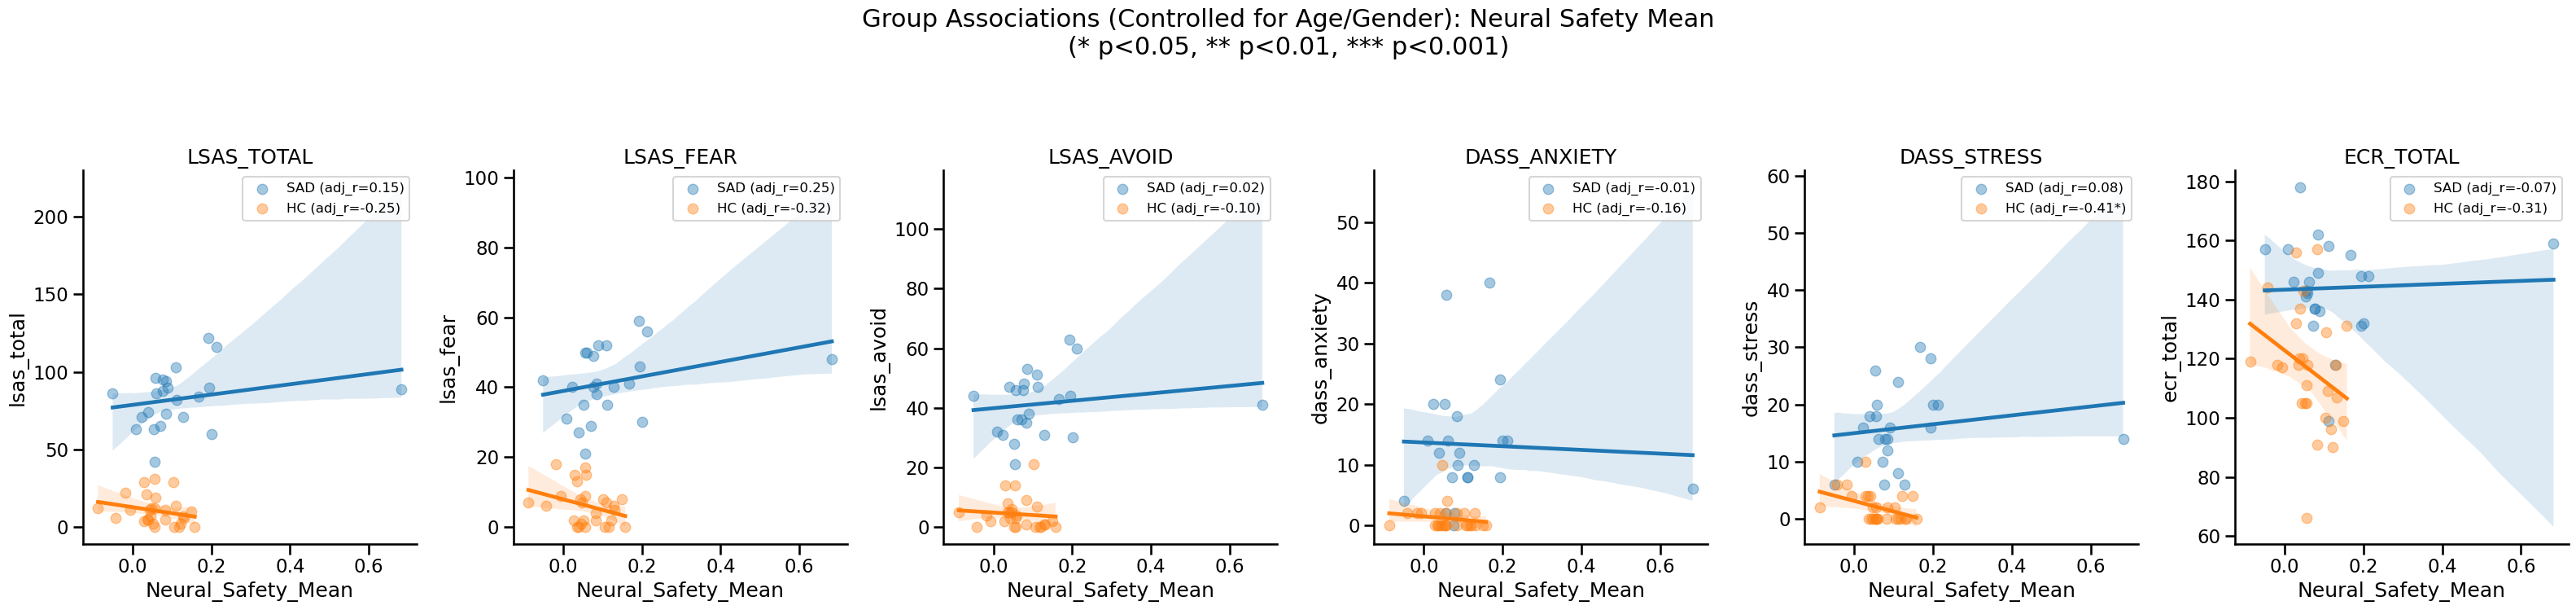

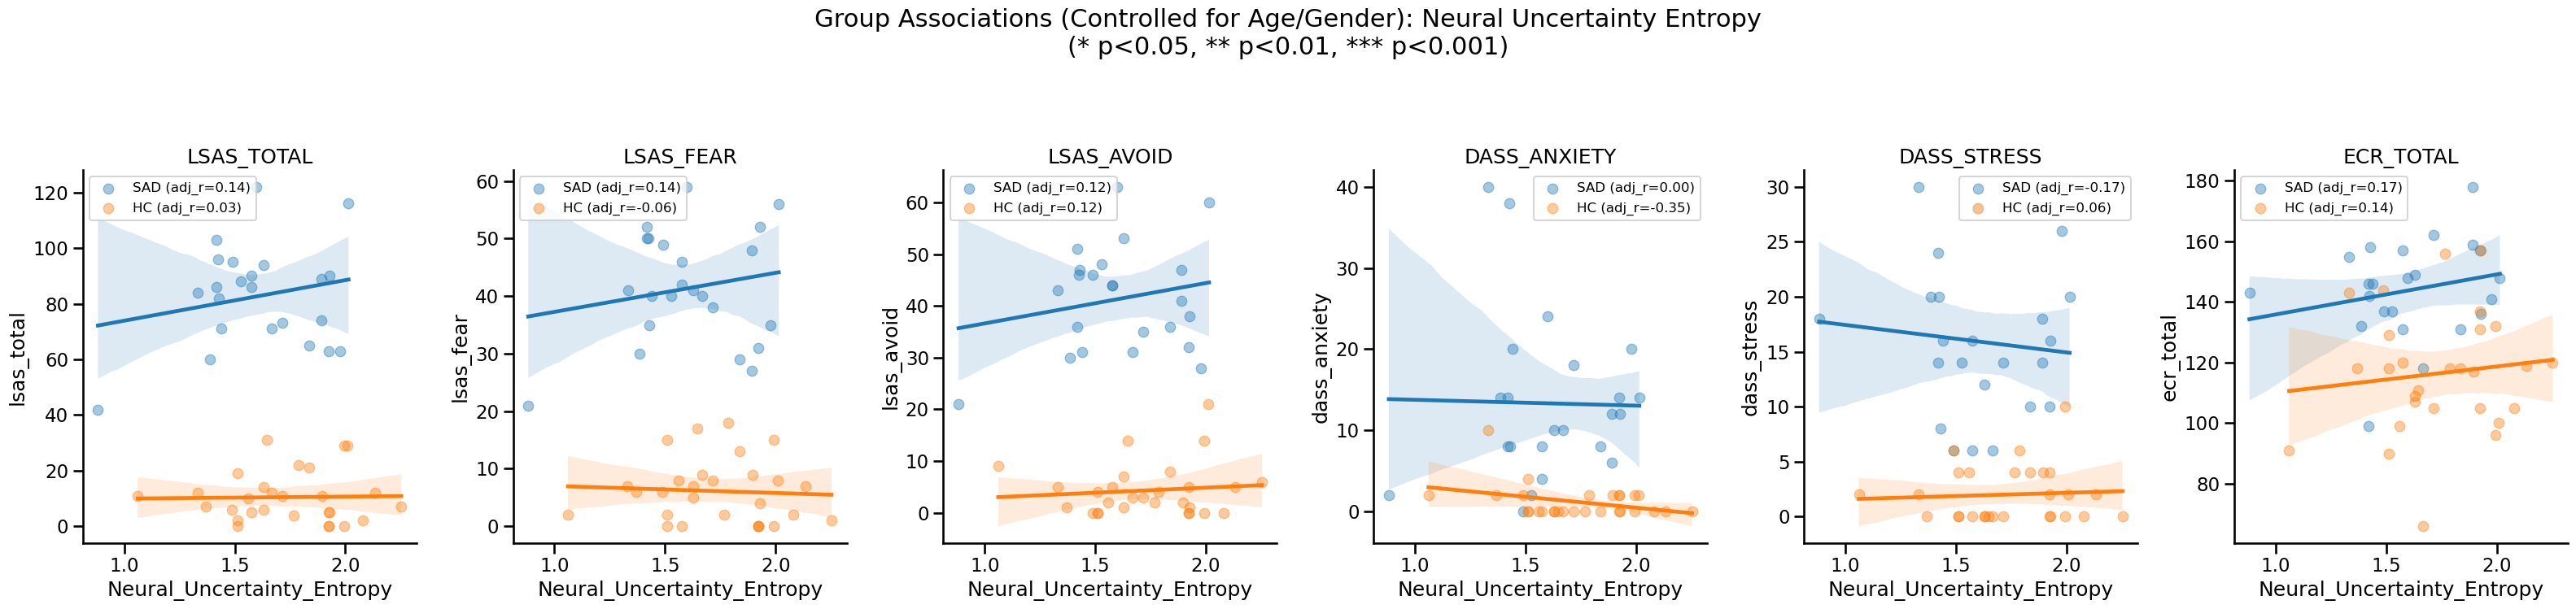

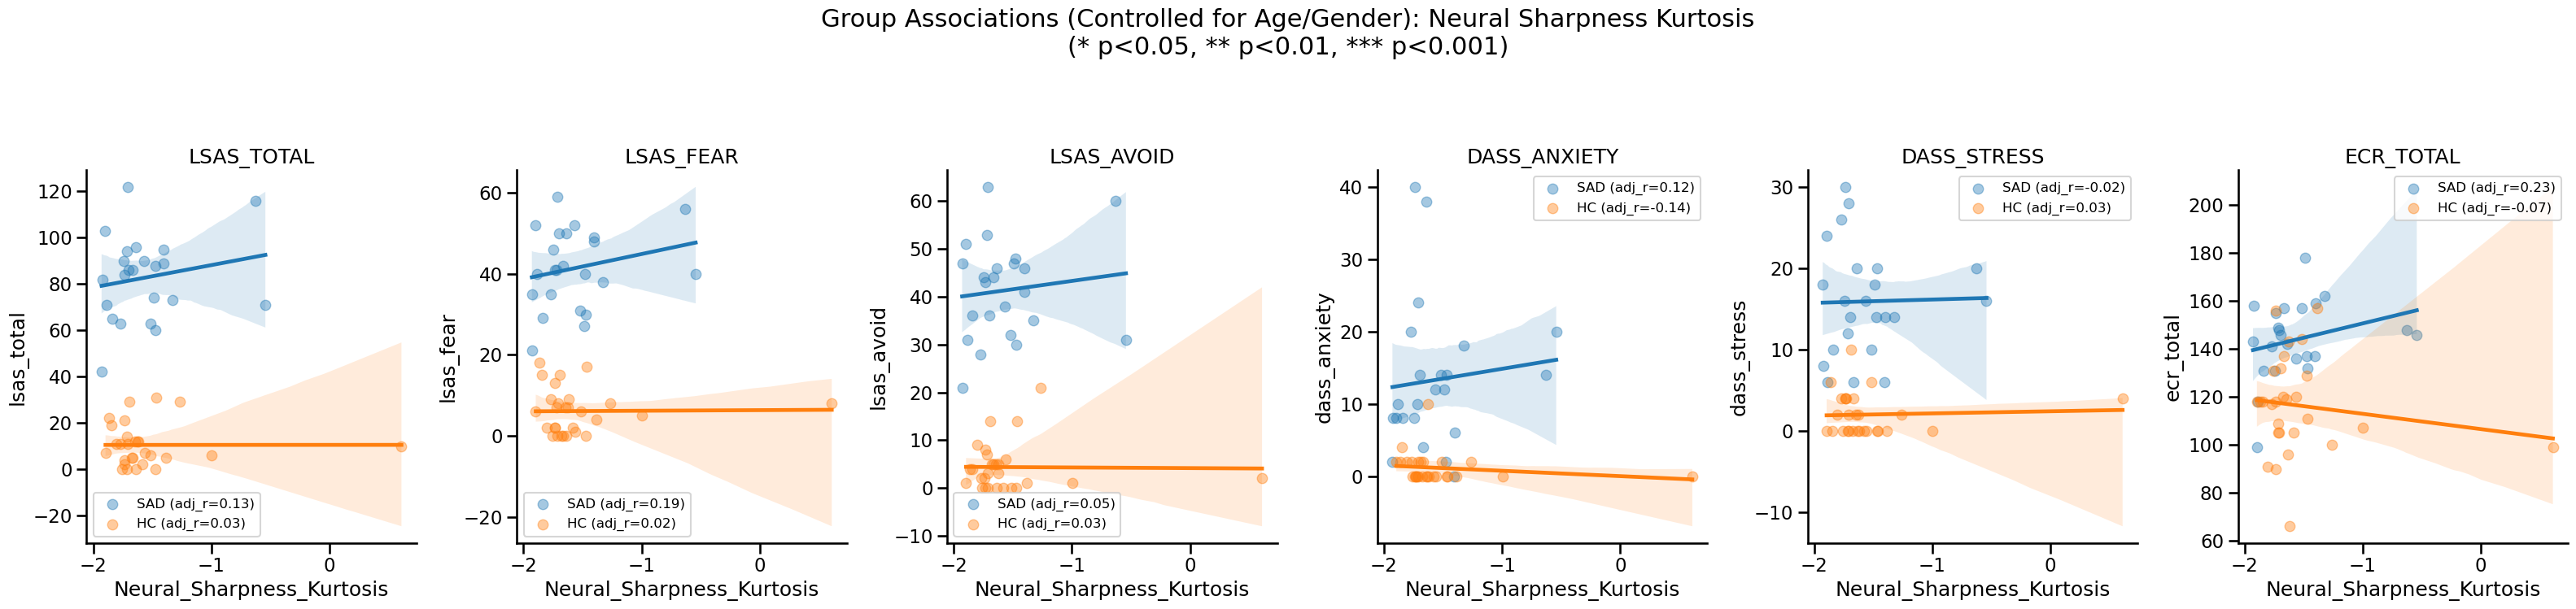

In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import pingouin as pg # Preferred for partial correlations

# 1. Config
# Using the merged df_master_analysis
groups = df_master_analysis['Group'].unique()
neural_metrics = ['Neural_Dist_Threat_Safety',
       'Neural_Dist_Safety_Backgr', 'Neural_Rigidity_Slope',
       'Neural_Safety_Mean', 'Neural_Uncertainty_Entropy',
       'Neural_Sharpness_Kurtosis']
clinical_indices = ['lsas_total', 'lsas_fear', 'lsas_avoid', 'dass_anxiety', 'dass_stress', 'ecr_total']
covariates = ['demo_age'] # Standard demographic controls

def get_sig_star(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "ns"

# 2. Execution & Statistics Printout
group_results = []
print(f"{'Group':<6} | {'Neural Metric':<28} | {'Clinical':<12} | {'r_adj':<6} | {'p':<8} | {'Sig'}")
print("-" * 85)

for grp in groups:
    # Filter group
    df_grp = df_master_analysis[df_master_analysis['Group'] == grp]
    
    for n_m in neural_metrics:
        for c_i in clinical_indices:
            # Ensure we have all columns and drop NaNs for this specific test
            cols_needed = [n_m, c_i] + covariates
            valid_df = df_grp[cols_needed].dropna().apply(pd.to_numeric)
            
            # Partial correlation requires N > len(covariates) + 2
            if len(valid_df) > (len(covariates) + 2):
                # Calculate Partial Correlation (controlling for Age and Gender)
                res = pg.partial_corr(data=valid_df, x=n_m, y=c_i, covar=covariates)
                r_adj = res['r'].values[0]
                p_val = res['p-val'].values[0]
                sig = get_sig_star(p_val)
                
                print(f"{grp:<6} | {n_m:<28} | {c_i:<12} | {r_adj:<6.2f} | {p_val:<8.4f} | {sig}")
                
                group_results.append({
                    'Group': grp, 'Neural': n_m, 'Clinical': c_i, 
                    'r': r_adj, 'p': p_val, 'sig': sig
                })

df_res_grp = pd.DataFrame(group_results)

# 3. Visualization: Group-Wise Comparative Grids
sns.set_context("talk")

for n_m in neural_metrics:
    fig, axes = plt.subplots(1, len(clinical_indices), figsize=(32, 7))
    
    for j, c_i in enumerate(clinical_indices):
        for grp in groups:
            grp_data = df_master_analysis[df_master_analysis['Group'] == grp]
            stats = df_res_grp[(df_res_grp['Group'] == grp) & 
                               (df_res_grp['Neural'] == n_m) & 
                               (df_res_grp['Clinical'] == c_i)]
            
            label_str = grp
            if not stats.empty:
                sig = stats['sig'].values[0]
                r = stats['r'].values[0]
                # Label shows the adjusted r-value (partial correlation)
                label_str = f"{grp} (adj_r={r:.2f}{'' if sig=='ns' else sig})"

            sns.regplot(data=grp_data, x=n_m, y=c_i, ax=axes[j], 
                        label=label_str, scatter_kws={'alpha':0.4})
            
        axes[j].set_title(f"{c_i.upper()}")
        axes[j].legend(fontsize=12, loc='best')
        sns.despine(ax=axes[j])
        
    plt.suptitle(f"Group Associations (Controlled for Age/Gender): {n_m.replace('_', ' ')}\n(* p<0.05, ** p<0.01, *** p<0.001)", 
                 fontsize=22, y=1.08)
    plt.tight_layout()
    plt.show()

In [181]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

# 1. Configuration
neural_metrics = [
    'Neural_Dist_Threat_Safety', 'Neural_Dist_Safety_Backgr', 
    'Neural_Rigidity_Slope', 'Neural_Safety_Mean', 
    'Neural_Uncertainty_Entropy', 'Neural_Sharpness_Kurtosis'
]
clinical_indices = ['lsas_total', 'lsas_fear', 'lsas_avoid', 'dass_anxiety', 'dass_stress', 'ecr_total']
covariates = ['demo_age']

all_cols = neural_metrics + clinical_indices + covariates
z_limit = 3.0 

# 2. Execution: Identify Outliers -> Drop -> Final Z-scoring
for col in all_cols:
    if col in df_master_analysis.columns:
        # Pass 1: Identify outliers using initial Z-scores
        initial_z = zscore(df_master_analysis[col], nan_policy='omit')
        outlier_mask = np.abs(initial_z) > z_limit
        
        num_removed = outlier_mask.sum()
        
        # Pass 2: Set outliers to NaN and calculate final Z-scores
        # We work on a copy to avoid SettingWithCopy warnings
        df_master_analysis.loc[outlier_mask, col] = np.nan
        
        # Calculate the final Z column based on the cleaned data
        z_col_name = f'{col}_z'
        df_master_analysis[z_col_name] = zscore(df_master_analysis[col], nan_policy='omit')
        
        if num_removed > 0:
            print(f"Column {col:<28}: Removed {num_removed} outliers (> {z_limit} SD)")
            
    else:
        print(f"Warning: {col} not found in dataframe.")

print("\nOutlier removal and final Z-scoring complete.")

Column Neural_Rigidity_Slope       : Removed 1 outliers (> 3.0 SD)
Column Neural_Safety_Mean          : Removed 1 outliers (> 3.0 SD)
Column Neural_Sharpness_Kurtosis   : Removed 2 outliers (> 3.0 SD)
Column dass_anxiety                : Removed 2 outliers (> 3.0 SD)
Column demo_age                    : Removed 1 outliers (> 3.0 SD)

Outlier removal and final Z-scoring complete.



NEURAL PREDICTOR: NEURAL_DIST_THREAT_SAFETY_Z

--- Clinical Outcome: LSAS_TOTAL_Z ---
[HC ] N=28  | Beta= 0.076 | t=  1.48 | p=0.1500
[SAD] N=23  | Beta=-0.027 | t= -0.30 | p=0.7702

--- Clinical Outcome: LSAS_FEAR_Z ---
[HC ] N=28  | Beta= 0.130 | t=  2.17 | p=0.0393 *SIGNIFICANT*
[SAD] N=23  | Beta=-0.039 | t= -0.40 | p=0.6937

--- Clinical Outcome: LSAS_AVOID_Z ---
[HC ] N=28  | Beta= 0.022 | t=  0.38 | p=0.7065
[SAD] N=23  | Beta=-0.014 | t= -0.15 | p=0.8853

--- Clinical Outcome: DASS_ANXIETY_Z ---
[HC ] N=28  | Beta=-0.087 | t= -1.24 | p=0.2250
[SAD] N=21  | Beta= 0.125 | t=  0.63 | p=0.5360

--- Clinical Outcome: DASS_STRESS_Z ---
[HC ] N=28  | Beta= 0.022 | t=  0.33 | p=0.7464
[SAD] N=23  | Beta=-0.010 | t= -0.06 | p=0.9503

--- Clinical Outcome: ECR_TOTAL_Z ---
[HC ] N=28  | Beta=-0.149 | t= -0.74 | p=0.4635
[SAD] N=23  | Beta= 0.018 | t=  0.13 | p=0.8981


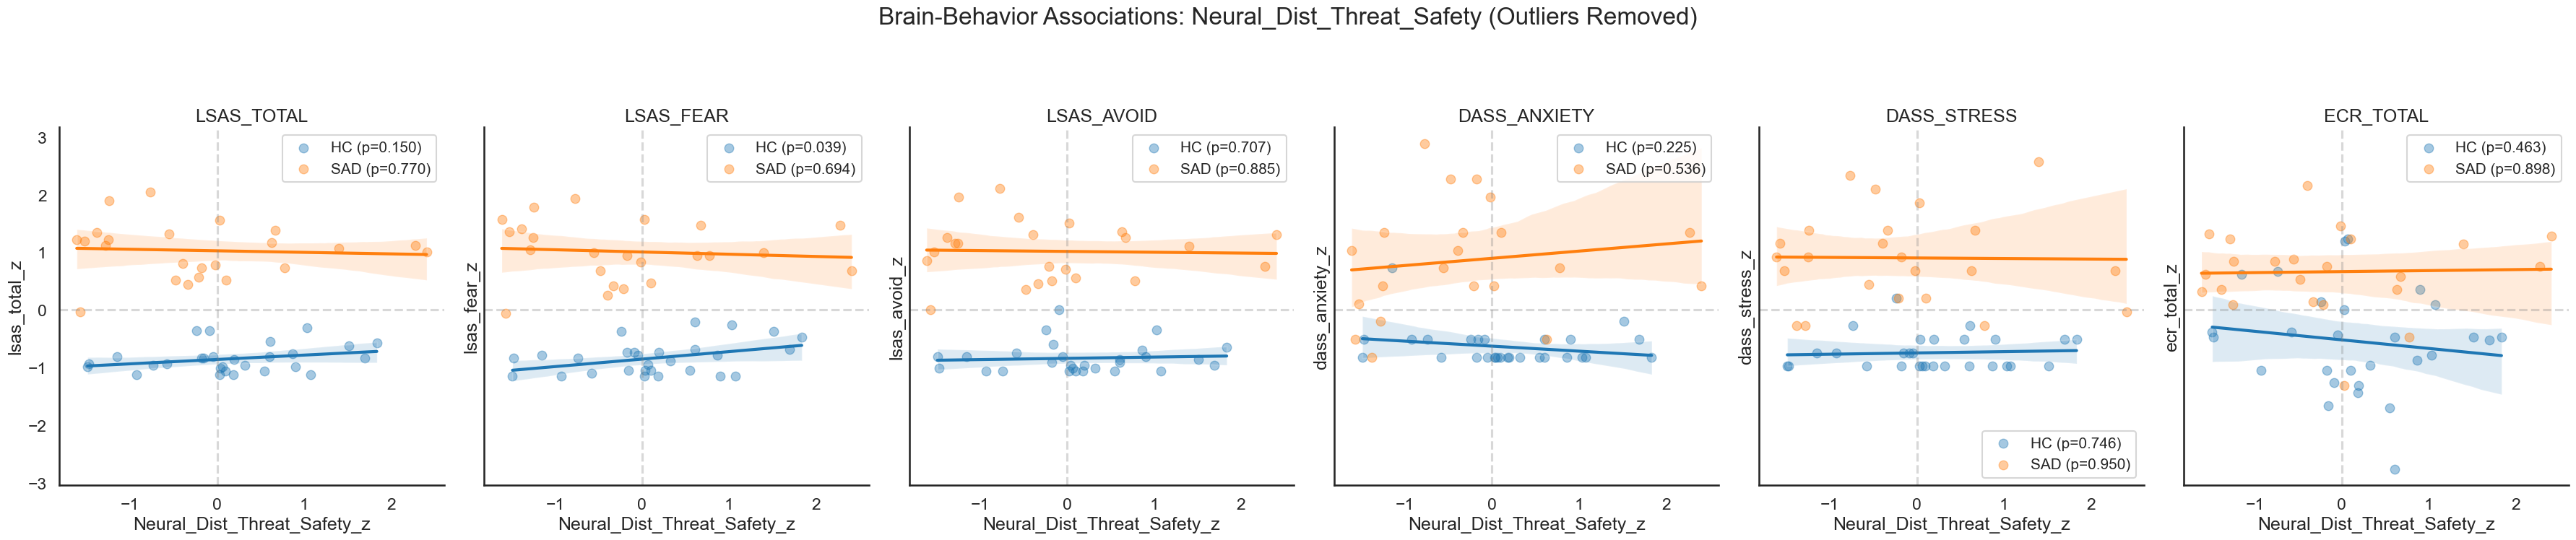


NEURAL PREDICTOR: NEURAL_DIST_SAFETY_BACKGR_Z

--- Clinical Outcome: LSAS_TOTAL_Z ---
[HC ] N=28  | Beta= 0.031 | t=  0.64 | p=0.5287
[SAD] N=23  | Beta= 0.039 | t=  0.33 | p=0.7434

--- Clinical Outcome: LSAS_FEAR_Z ---
[HC ] N=28  | Beta= 0.085 | t=  1.49 | p=0.1495
[SAD] N=23  | Beta= 0.044 | t=  0.35 | p=0.7292

--- Clinical Outcome: LSAS_AVOID_Z ---
[HC ] N=28  | Beta=-0.022 | t= -0.42 | p=0.6811
[SAD] N=23  | Beta= 0.032 | t=  0.26 | p=0.8009

--- Clinical Outcome: DASS_ANXIETY_Z ---
[HC ] N=28  | Beta=-0.085 | t= -1.32 | p=0.1978
[SAD] N=21  | Beta=-0.030 | t= -0.12 | p=0.9076

--- Clinical Outcome: DASS_STRESS_Z ---
[HC ] N=28  | Beta=-0.005 | t= -0.08 | p=0.9349
[SAD] N=23  | Beta= 0.049 | t=  0.25 | p=0.8063

--- Clinical Outcome: ECR_TOTAL_Z ---
[HC ] N=28  | Beta=-0.245 | t= -1.37 | p=0.1832
[SAD] N=23  | Beta=-0.274 | t= -1.66 | p=0.1108


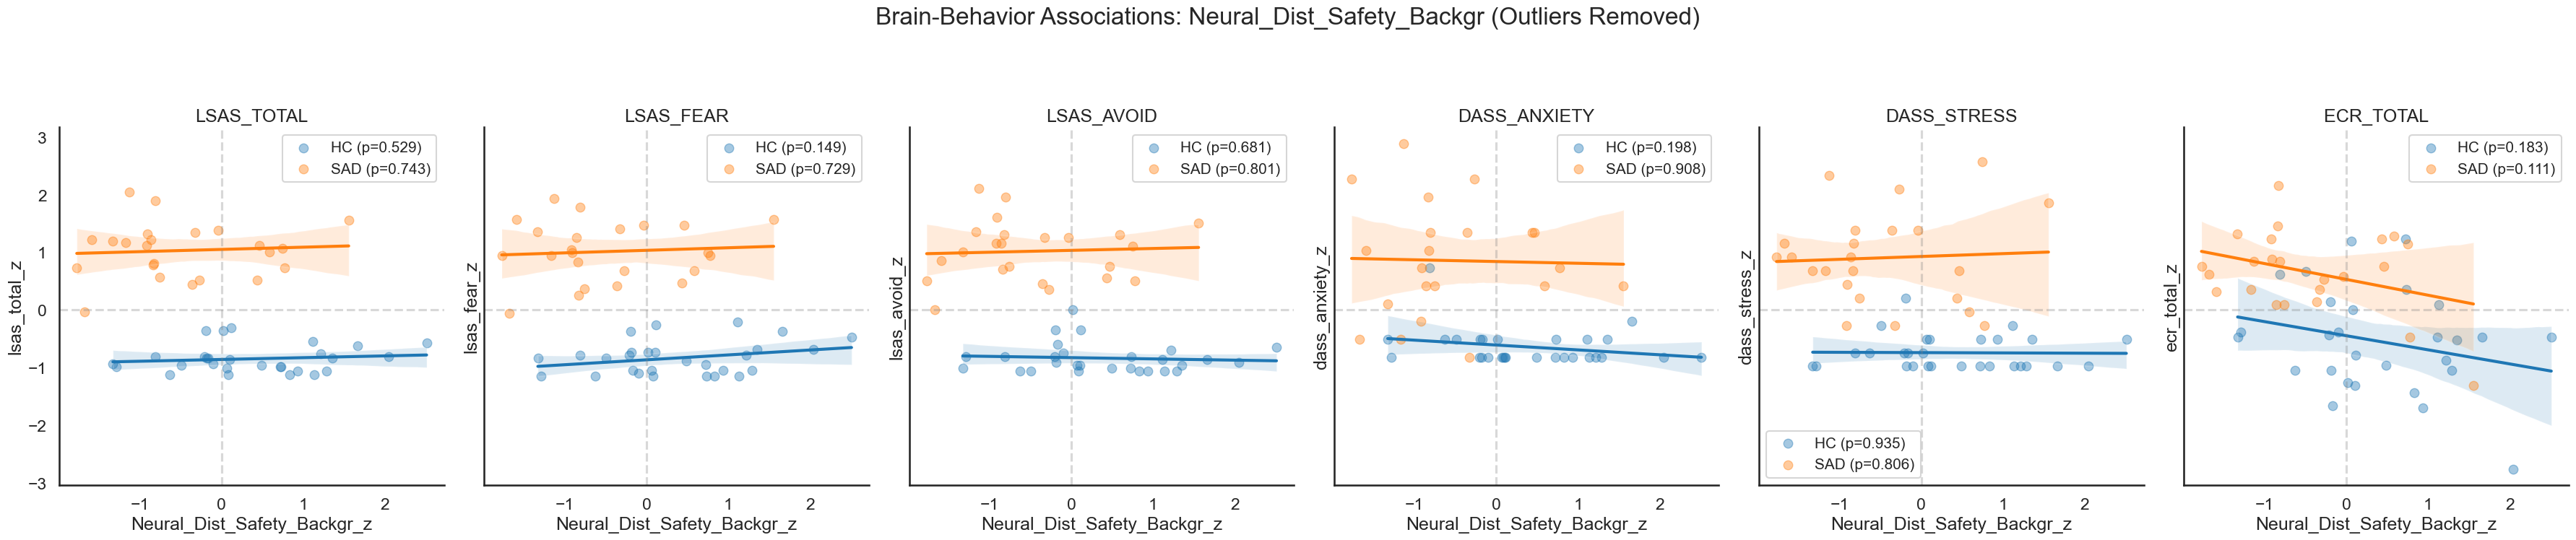


NEURAL PREDICTOR: NEURAL_RIGIDITY_SLOPE_Z

--- Clinical Outcome: LSAS_TOTAL_Z ---
[HC ] N=28  | Beta=-0.035 | t= -0.69 | p=0.4940
[SAD] N=22  | Beta= 0.238 | t=  2.69 | p=0.0141 *SIGNIFICANT*

--- Clinical Outcome: LSAS_FEAR_Z ---
[HC ] N=28  | Beta=-0.040 | t= -0.65 | p=0.5222
[SAD] N=22  | Beta= 0.217 | t=  2.19 | p=0.0408 *SIGNIFICANT*

--- Clinical Outcome: LSAS_AVOID_Z ---
[HC ] N=28  | Beta=-0.029 | t= -0.53 | p=0.5984
[SAD] N=22  | Beta= 0.251 | t=  2.58 | p=0.0177 *SIGNIFICANT*

--- Clinical Outcome: DASS_ANXIETY_Z ---
[HC ] N=28  | Beta=-0.040 | t= -0.59 | p=0.5622
[SAD] N=20  | Beta= 0.119 | t=  0.56 | p=0.5825

--- Clinical Outcome: DASS_STRESS_Z ---
[HC ] N=28  | Beta=-0.107 | t= -1.73 | p=0.0950
[SAD] N=22  | Beta= 0.298 | t=  1.84 | p=0.0805

--- Clinical Outcome: ECR_TOTAL_Z ---
[HC ] N=28  | Beta=-0.289 | t= -1.57 | p=0.1285
[SAD] N=22  | Beta=-0.139 | t= -0.94 | p=0.3581


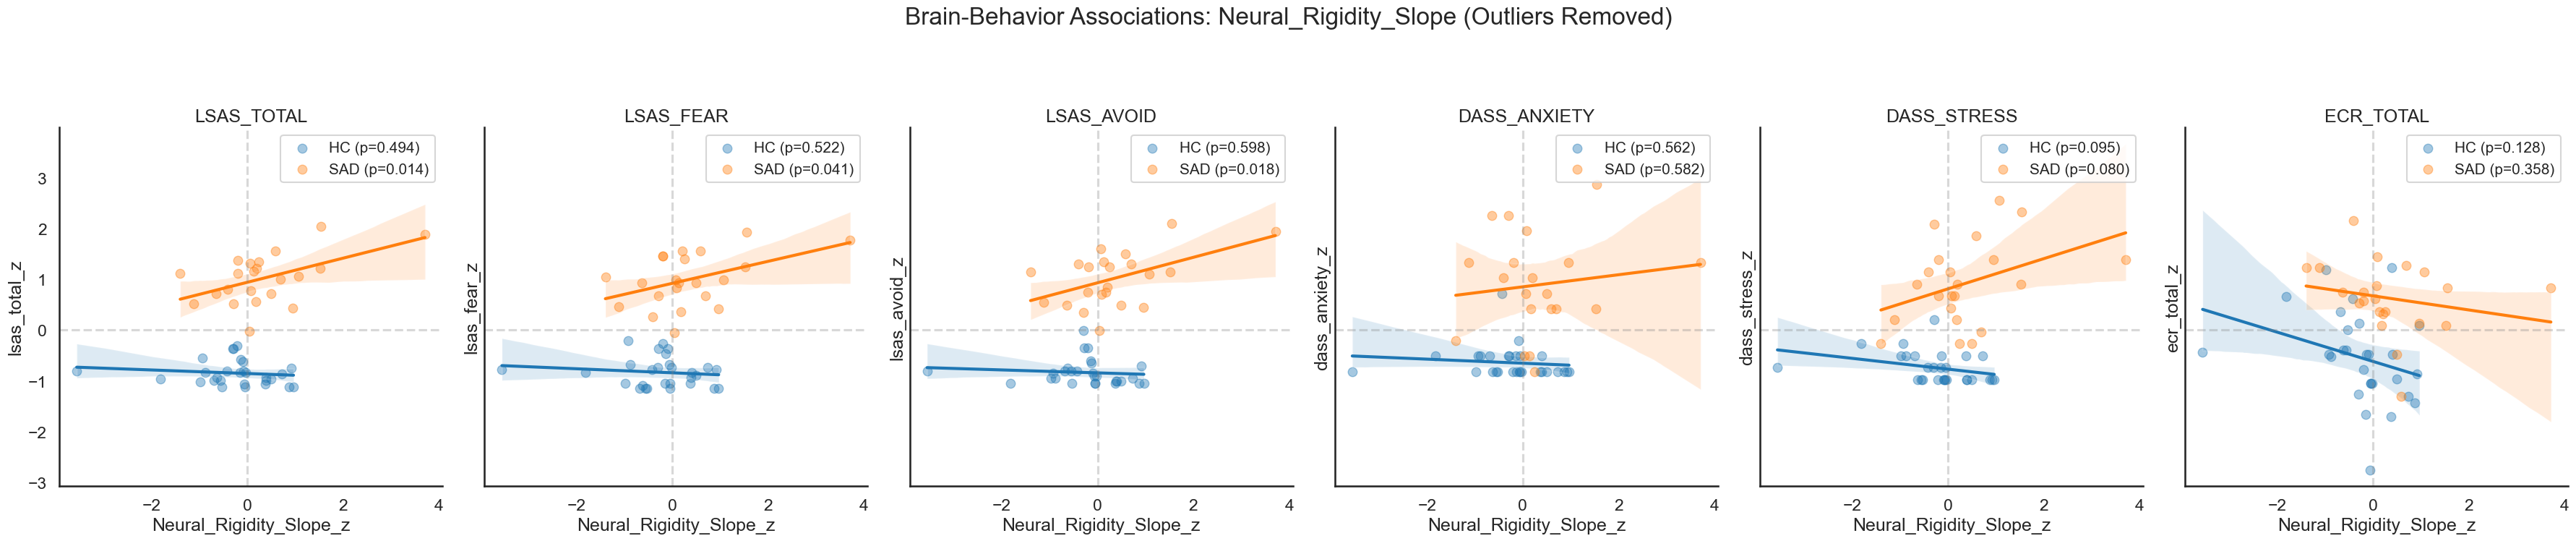


NEURAL PREDICTOR: NEURAL_SAFETY_MEAN_Z

--- Clinical Outcome: LSAS_TOTAL_Z ---
[HC ] N=28  | Beta=-0.063 | t= -1.29 | p=0.2086
[SAD] N=22  | Beta= 0.180 | t=  1.93 | p=0.0681

--- Clinical Outcome: LSAS_FEAR_Z ---
[HC ] N=28  | Beta=-0.099 | t= -1.70 | p=0.1014
[SAD] N=22  | Beta= 0.172 | t=  1.69 | p=0.1060

--- Clinical Outcome: LSAS_AVOID_Z ---
[HC ] N=28  | Beta=-0.027 | t= -0.49 | p=0.6294
[SAD] N=22  | Beta= 0.182 | t=  1.77 | p=0.0914

--- Clinical Outcome: DASS_ANXIETY_Z ---
[HC ] N=28  | Beta=-0.056 | t= -0.82 | p=0.4171
[SAD] N=20  | Beta= 0.200 | t=  0.95 | p=0.3538

--- Clinical Outcome: DASS_STRESS_Z ---
[HC ] N=28  | Beta=-0.137 | t= -2.33 | p=0.0280 *SIGNIFICANT*
[SAD] N=22  | Beta= 0.346 | t=  2.25 | p=0.0356 *SIGNIFICANT*

--- Clinical Outcome: ECR_TOTAL_Z ---
[HC ] N=28  | Beta=-0.283 | t= -1.55 | p=0.1344
[SAD] N=22  | Beta=-0.195 | t= -1.38 | p=0.1836


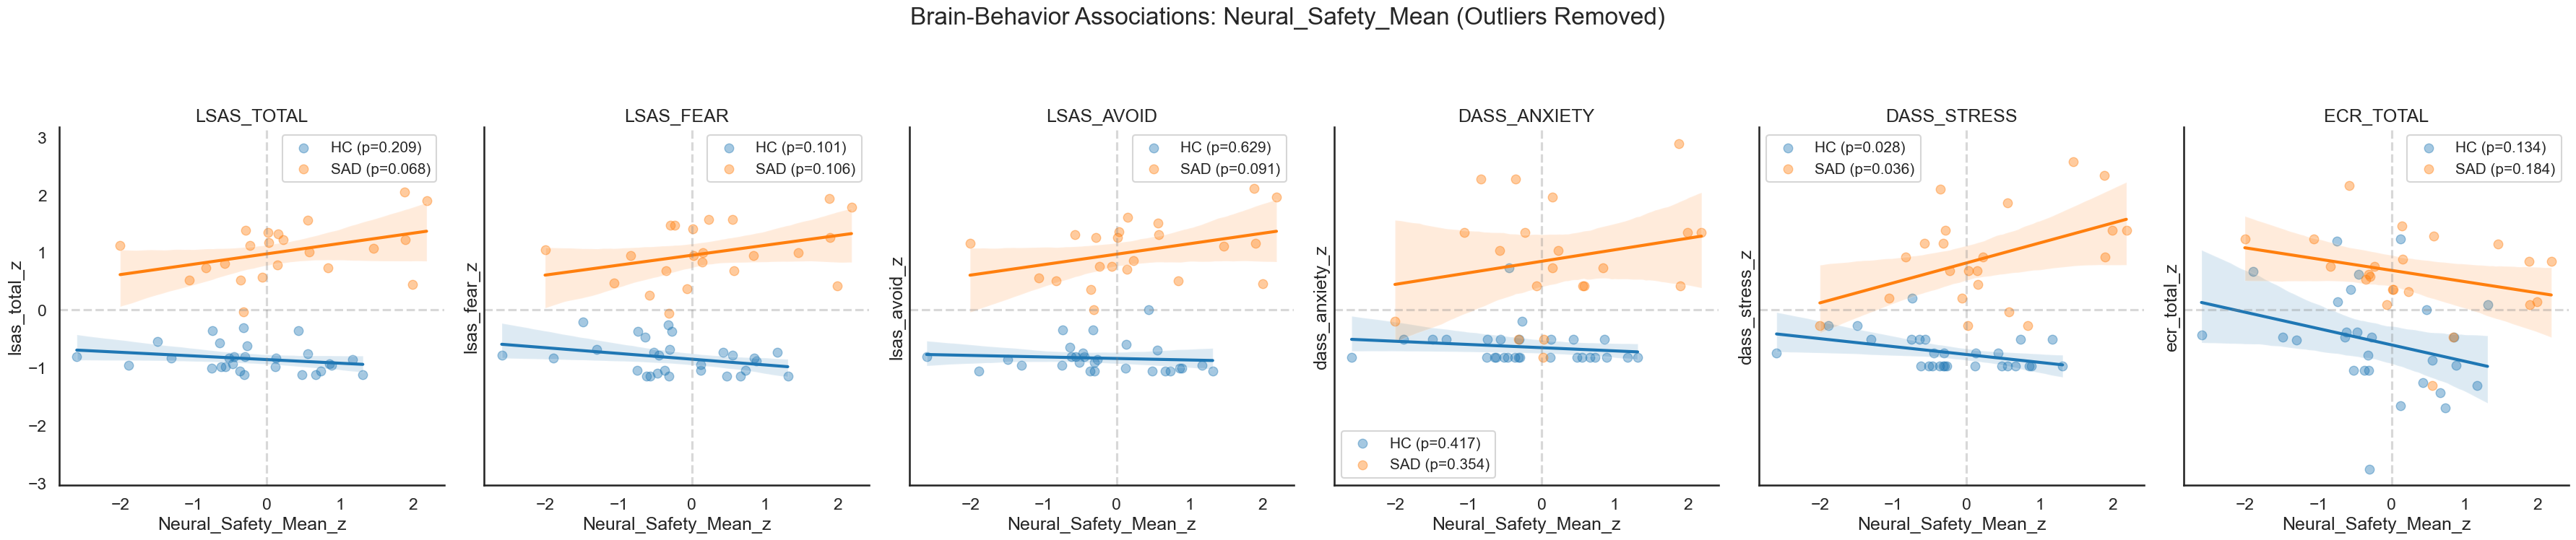


NEURAL PREDICTOR: NEURAL_UNCERTAINTY_ENTROPY_Z

--- Clinical Outcome: LSAS_TOTAL_Z ---
[HC ] N=28  | Beta= 0.005 | t=  0.11 | p=0.9128
[SAD] N=23  | Beta= 0.103 | t=  1.00 | p=0.3310

--- Clinical Outcome: LSAS_FEAR_Z ---
[HC ] N=28  | Beta=-0.017 | t= -0.31 | p=0.7610
[SAD] N=23  | Beta= 0.097 | t=  0.86 | p=0.4002

--- Clinical Outcome: LSAS_AVOID_Z ---
[HC ] N=28  | Beta= 0.027 | t=  0.53 | p=0.5985
[SAD] N=23  | Beta= 0.106 | t=  0.94 | p=0.3555

--- Clinical Outcome: DASS_ANXIETY_Z ---
[HC ] N=28  | Beta=-0.113 | t= -1.92 | p=0.0657
[SAD] N=21  | Beta= 0.343 | t=  1.60 | p=0.1256

--- Clinical Outcome: DASS_STRESS_Z ---
[HC ] N=28  | Beta= 0.019 | t=  0.32 | p=0.7520
[SAD] N=23  | Beta=-0.081 | t= -0.45 | p=0.6568

--- Clinical Outcome: ECR_TOTAL_Z ---
[HC ] N=28  | Beta= 0.103 | t=  0.59 | p=0.5601
[SAD] N=23  | Beta= 0.158 | t=  1.02 | p=0.3175


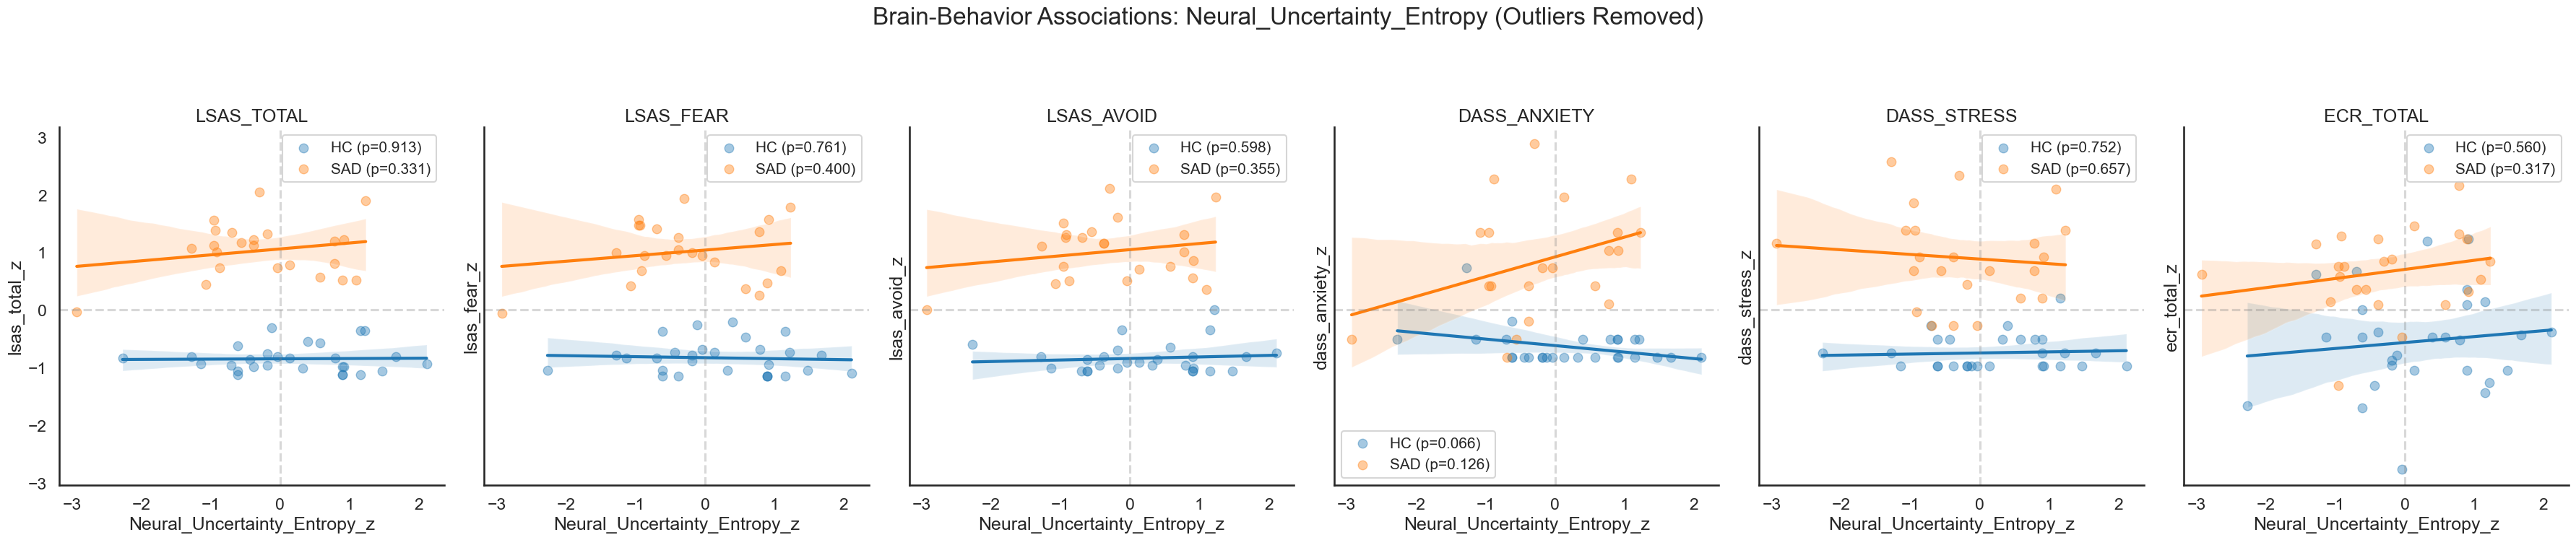


NEURAL PREDICTOR: NEURAL_SHARPNESS_KURTOSIS_Z

--- Clinical Outcome: LSAS_TOTAL_Z ---
[HC ] N=27  | Beta= 0.007 | t=  0.12 | p=0.9064
[SAD] N=22  | Beta= 0.141 | t=  1.70 | p=0.1053

--- Clinical Outcome: LSAS_FEAR_Z ---
[HC ] N=27  | Beta=-0.043 | t= -0.61 | p=0.5481
[SAD] N=22  | Beta= 0.134 | t=  1.46 | p=0.1598

--- Clinical Outcome: LSAS_AVOID_Z ---
[HC ] N=27  | Beta= 0.054 | t=  0.88 | p=0.3856
[SAD] N=22  | Beta= 0.143 | t=  1.60 | p=0.1249

--- Clinical Outcome: DASS_ANXIETY_Z ---
[HC ] N=27  | Beta=-0.065 | t= -0.85 | p=0.4048
[SAD] N=20  | Beta= 0.105 | t=  0.60 | p=0.5555

--- Clinical Outcome: DASS_STRESS_Z ---
[HC ] N=27  | Beta=-0.084 | t= -1.18 | p=0.2491
[SAD] N=22  | Beta= 0.017 | t=  0.11 | p=0.9107

--- Clinical Outcome: ECR_TOTAL_Z ---
[HC ] N=27  | Beta= 0.021 | t=  0.10 | p=0.9221
[SAD] N=22  | Beta= 0.188 | t=  1.48 | p=0.1534


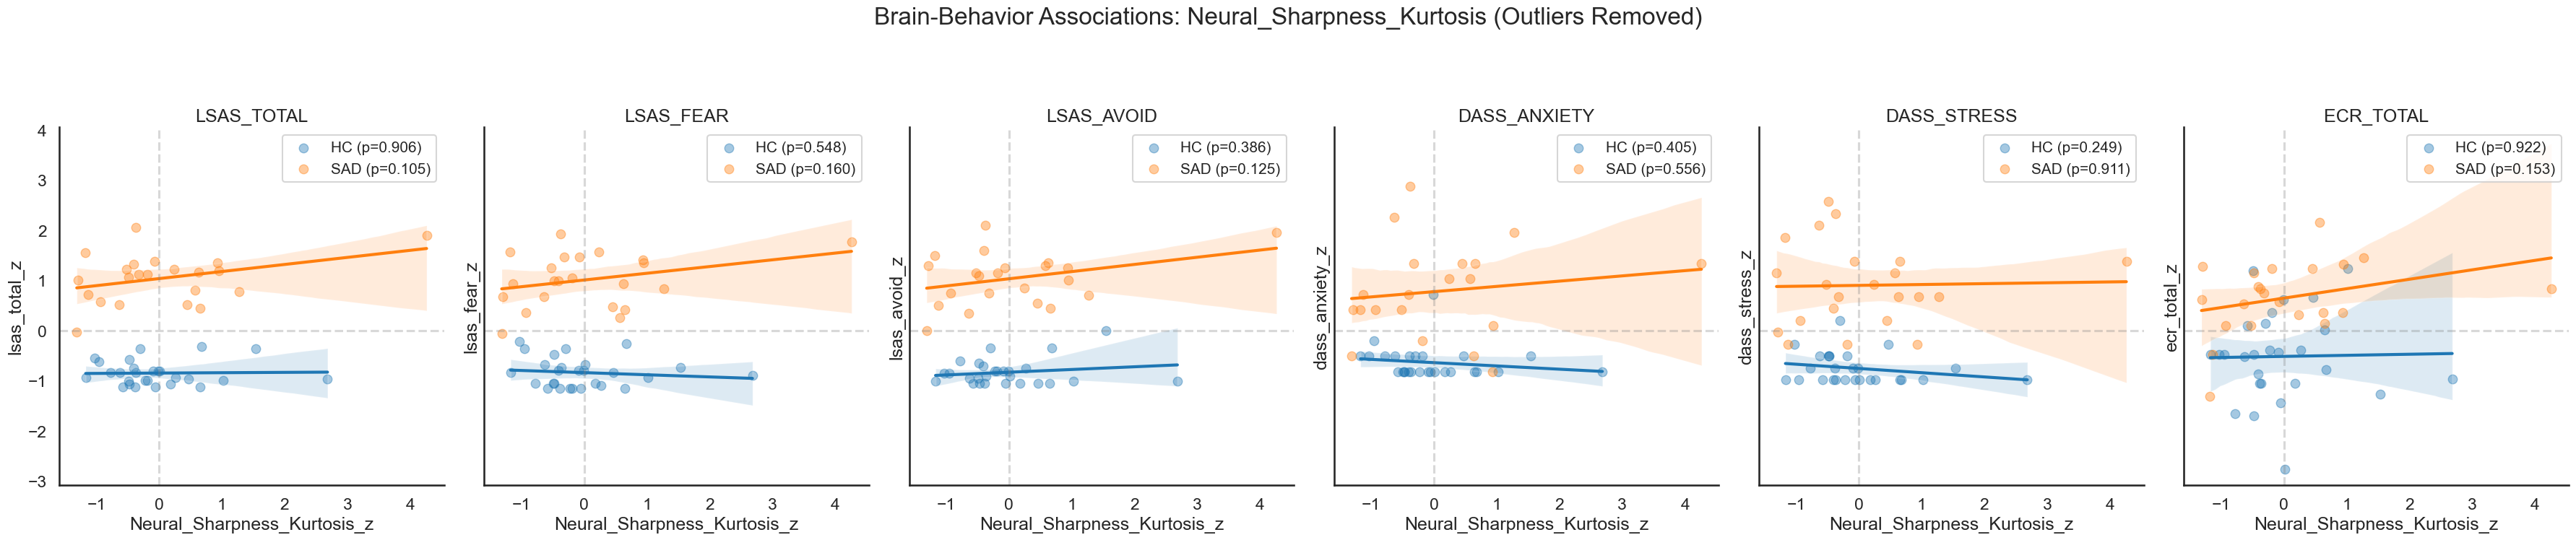

In [197]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Config
neural_z = [f'{c}_z' for c in neural_metrics]
clinical_z = [f'{c}_z' for c in clinical_indices]
# Ensure groups are sorted for consistent coloring (e.g., SAD vs HC)
groups = sorted(df_master_analysis['Group'].unique()) if 'Group' in df_master_analysis.columns else [None]

sns.set_context("talk")
sns.set_style("white")

# 2. Analysis & Plotting Loop
for n_m in neural_z:
    # Print header for the specific neural metric
    print(f"\n{'='*80}\nNEURAL PREDICTOR: {n_m.upper()}\n{'='*80}")
    
    # Create subplots: 1 column for each clinical index
    fig, axes = plt.subplots(1, len(clinical_z), figsize=(36, 7), sharey=True)
    if len(clinical_z) == 1: axes = [axes] # Ensure axes is iterable for single plots
    
    for i, c_i in enumerate(clinical_z):
        ax = axes[i]
        print(f"\n--- Clinical Outcome: {c_i.upper()} ---")
        
        for grp in groups:
            # Subset data for the group
            df_grp = df_master_analysis[df_master_analysis['Group'] == grp]
            
            # Drop NaNs (crucial after outlier removal) to ensure model runs
            analysis_df = df_grp[[n_m, c_i]].dropna()
            
            if len(analysis_df) > 5: # Minimum N check
                # A. STATISTICAL ANALYSIS
                X = sm.add_constant(analysis_df[n_m])
                y = analysis_df[c_i]
                model = sm.OLS(y, X).fit()
                
                # Print concise stats for each group
                p_val = model.pvalues[n_m]
                beta = model.params[n_m]
                sig_note = " *SIGNIFICANT*" if p_val < 0.05 else ""
                print(f"[{grp:<3}] N={len(analysis_df):<3} | Beta={beta:>6.3f} | t={model.tvalues[n_m]:>6.2f} | p={p_val:>6.4f}{sig_note}")
                
                # B. VISUALIZATION
                sns.regplot(
                    data=analysis_df, x=n_m, y=c_i, ax=ax, 
                    label=f"{grp} (p={p_val:.3f})", 
                    scatter_kws={'alpha': 0.4},
                    line_kws={'lw': 3}
                )
            else:
                print(f"[{grp:<3}] Insufficient data (N < 5)")

        # Formatting each subplot
        ax.set_title(f"{c_i.replace('_z', '').upper()}")
        ax.set_xlabel(f"{n_m}")
        ax.set_ylabel(f"{c_i}")
        ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
        ax.axvline(0, color='gray', linestyle='--', alpha=0.3)
        ax.legend(fontsize='small', loc='best')

    plt.suptitle(f"Brain-Behavior Associations: {n_m.replace('_z', '')} (Outliers Removed)", 
                 fontsize=24, y=1.08)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [187]:
res_sad

{'accuracy': 0.74,
 'haufe_pattern': array([15150.03161019,  -327.50391769, -1768.21017602, ...,
        -3806.64171189,  6535.43628686,  4870.35031262]),
 'model_sad': Pipeline(steps=[('scaler', StandardScaler()),
                 ('classification',
                  LogisticRegression(C=0.01, class_weight='balanced',
                                     max_iter=5000, n_jobs=1,
                                     random_state=42))])}